In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("EDA environment ready")

EDA environment ready


In [2]:
# Define the path to the raw housing dataset.
# The dataset is stored in the project's data folder.
DATA_PATH = "../data/housing.csv"

# Load the CSV dataset into a pandas DataFrame.
# We keep the raw dataset in a single DataFrame so that
# we can inspect and analyze it before making any changes.
df = pd.read_csv(DATA_PATH)

# Display the number of rows and columns in the dataset.
# This gives us an initial understanding of the dataset size.
print(f"Dataset shape: {df.shape}")

Dataset shape: (384977, 22)


# EDA Analysis Roadmap

| Section | Topic | What We Analyze | Purpose |
|---|---|---|---|
| Initial setup | Dataset loading and initial inspection | Loads the raw housing dataset and reports its dimensions. | Establishes the dataset used for the rental-price analysis. |
| 2. Dataset Structure and Variable Overview | Dataset structure and variables | Reviews columns, data types, and dataset information. | Identifies the available predictors and fields needing further review. |
| 3. Missing Value Analysis | Missing values | Measures missingness and examines geographic, parking, laundry, and description patterns. | Informs later handling of incomplete listing information. |
| 4. Duplicate Analysis | Duplicate and repeated listings | Checks exact duplicates, repeated IDs, and near-duplicate property patterns. | Assesses repetition that could affect analysis and model evaluation. |
| 5. Invalid Values and Data Quality | Validity checks | Examines price, square footage, bedroom, bathroom, coordinate, binary, and categorical values. | Identifies values that may not represent valid rental listings. |
| 6.1–6.5 Numerical Feature Distributions and Outlier Analysis | Numerical distributions and outliers | Explores price, square footage, bedrooms, bathrooms, and geographic-coordinate distributions. | Characterizes feature ranges, skewness, and unusual observations. |
| 6.6 Categorical Feature Distributions | Categorical distributions | Summarizes property type, state, region, laundry, and parking categories. | Shows category prevalence, rarity, and feature cardinality. |
| 7. Relationship Analysis | Features versus rental price | Compares price with property size, rooms, type, geography, and amenities. | Identifies variables with potential predictive value for rental price. |
| 8. Numerical Correlation Analysis | Numerical correlations | Calculates Pearson and Spearman relationships among numerical variables. | Evaluates linear and monotonic associations relevant to modeling. |
| 9. Geographic Price Patterns | Spatial price patterns | Visualizes rental prices across valid U.S. listing coordinates. | Examines whether location contributes useful price information. |
| 10. Data Leakage Analysis | Leakage risks | Reviews target, identifiers, URLs, descriptions, preprocessing, and repeated-listing risks. | Helps prevent unrealistic model performance from leaked information. |
| 11. EDA Summary and Preprocessing Decisions | EDA summary and planned decisions | Consolidates findings, feature roles, and the planned preprocessing strategy. | Connects EDA evidence to the next project stage. |

## 2. Dataset Structure and Variable Overview

Before performing detailed exploratory analysis, we inspect the dataset structure,
column names, data types, and basic information about each variable.

This helps us understand what information is available and identify variables
that may require further investigation during EDA and preprocessing.

In [3]:
# Display the names of all variables in the dataset.
# This helps us understand what information is available for rental price prediction.
print("Dataset columns:")
print(df.columns.tolist())

# Display the data type of each variable.
# Understanding data types helps us distinguish numerical, categorical,
# and text-based variables before performing further analysis.
print("\nData types:")
print(df.dtypes)


Dataset columns:
['id', 'url', 'region', 'region_url', 'price', 'type', 'sqfeet', 'beds', 'baths', 'cats_allowed', 'dogs_allowed', 'smoking_allowed', 'wheelchair_access', 'electric_vehicle_charge', 'comes_furnished', 'laundry_options', 'parking_options', 'image_url', 'description', 'lat', 'long', 'state']

Data types:
id                           int64
url                            str
region                         str
region_url                     str
price                        int64
type                           str
sqfeet                       int64
beds                         int64
baths                      float64
cats_allowed                 int64
dogs_allowed                 int64
smoking_allowed              int64
wheelchair_access            int64
electric_vehicle_charge      int64
comes_furnished              int64
laundry_options                str
parking_options                str
image_url                      str
description                    str
lat            

In [4]:
# Display detailed information about the dataset.
# This shows the number of non-null values, data types, and memory usage.
# It will help us identify missing values and understand the dataset's memory requirements.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 384977 entries, 0 to 384976
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       384977 non-null  int64  
 1   url                      384977 non-null  str    
 2   region                   384977 non-null  str    
 3   region_url               384977 non-null  str    
 4   price                    384977 non-null  int64  
 5   type                     384977 non-null  str    
 6   sqfeet                   384977 non-null  int64  
 7   beds                     384977 non-null  int64  
 8   baths                    384977 non-null  float64
 9   cats_allowed             384977 non-null  int64  
 10  dogs_allowed             384977 non-null  int64  
 11  smoking_allowed          384977 non-null  int64  
 12  wheelchair_access        384977 non-null  int64  
 13  electric_vehicle_charge  384977 non-null  int64  
 14  comes_furnished

## 3. Missing Value Analysis

Missing values can affect both exploratory analysis and model development.
We first identify the number and percentage of missing values in each column
before deciding how they should be handled.

The treatment of missing values will be based on the amount of missingness,
the meaning of the variable, and its potential importance to the prediction task.


In [5]:
# Calculate the number of missing values in each column.
missing_count = df.isnull().sum()

# Calculate the percentage of missing values in each column.
missing_percentage = (missing_count / len(df)) * 100

# Combine the missing-value counts and percentages into a summary table.
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Display only columns that contain missing values.
missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

# Sort columns from highest to lowest missing percentage.
missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

# Display the missing-value summary.
missing_summary

,Missing Count,Missing Percentage
parking_options,140687,36.544261
laundry_options,79026,20.527460
lat,1918,0.498212
long,1918,0.498212
description,2,0.000520


### Initial Finding

The missing-value analysis shows that missing data is concentrated mainly in
`parking_options` and `laundry_options`.

`parking_options` has approximately 36.54% missing values, while
`laundry_options` has approximately 20.53% missing values.

The geographic variables `lat` and `long` each have approximately 0.50% missing
values, while `description` has only 2 missing values.

These differences suggest that missing-value treatment should be considered
separately for different variables rather than applying one general strategy
to all columns.

Further investigation is required to understand the pattern and possible
meaning of the missing values before making preprocessing decisions.

### 3.1 Geographic Missingness Pattern

The `lat` and `long` variables contain the same number of missing values.

We investigate whether latitude and longitude are missing from the same
records or whether either variable can be missing independently.

This helps us understand whether the missing geographic information represents
a single missing-location problem.

In [7]:
# Check how many records are missing both latitude and longitude.
geo_both_missing = (
    df["lat"].isnull() &
    df["long"].isnull()
).sum()

# Check whether latitude is missing while longitude is available.
lat_only_missing = (
    df["lat"].isnull() &
    df["long"].notnull()
).sum()

# Check whether longitude is missing while latitude is available.
long_only_missing = (
    df["long"].isnull() &
    df["lat"].notnull()
).sum()

print(f"Records missing both latitude and longitude: {geo_both_missing:,}")
print(f"Records missing latitude only: {lat_only_missing:,}")
print(f"Records missing longitude only: {long_only_missing:,}")

Records missing both latitude and longitude: 1,918
Records missing latitude only: 0
Records missing longitude only: 0


### Finding — Geographic Missingness

The analysis shows that 1,918 records are missing both `lat` and `long`.
There are no records where only one of the two geographic coordinates is
missing.

Therefore, the missing geographic information occurs as a complete
latitude/longitude pair rather than as independent missing values.

### EDA Implication

The 1,918 records represent listings for which geographic coordinates are
not available.

This finding will be considered during preprocessing when deciding how to
handle missing geographic information. We should avoid independently
imputing latitude and longitude without considering that they represent a
single geographic location.

### 3.2 Parking and Laundry Missingness Pattern

`parking_options` and `laundry_options` contain the largest proportions of
missing values in the dataset.

We investigate whether these two variables are commonly missing together or
whether their missingness occurs independently.

Understanding this pattern will help us determine whether the missing values
may represent a common data-collection issue or separate missing-information
patterns.

In [9]:
# Count records where both parking and laundry information are missing.
both_missing = (
    df["parking_options"].isnull() &
    df["laundry_options"].isnull()
).sum()

# Count records where only parking information is missing.
parking_only_missing = (
    df["parking_options"].isnull() &
    df["laundry_options"].notnull()
).sum()

# Count records where only laundry information is missing.
laundry_only_missing = (
    df["laundry_options"].isnull() &
    df["parking_options"].notnull()
).sum()

print(f"Both parking and laundry missing: {both_missing:,}")
print(f"Parking missing only: {parking_only_missing:,}")
print(f"Laundry missing only: {laundry_only_missing:,}")

Both parking and laundry missing: 71,616
Parking missing only: 69,071
Laundry missing only: 7,410


### Finding — Parking and Laundry Missingness

The analysis shows that missing values in `parking_options` and
`laundry_options` frequently occur together.

There are 71,616 records where both variables are missing. There are
69,071 records where only `parking_options` is missing, while 7,410
records have only `laundry_options` missing.

This indicates that the missingness is not limited to a small number of
isolated records and may be related to how listing information was
provided or collected.

### EDA Implication

Missing values in these categorical variables should not automatically be
interpreted as the absence of parking or laundry facilities.

During preprocessing, we should investigate the possible meanings of the
missing values and select an appropriate categorical missing-value
strategy rather than simply deleting these records.

### 3.3 Examining Existing Parking and Laundry Categories

The previous analysis showed that `parking_options` and `laundry_options`
contain a substantial number of missing values.

Before deciding how these missing values should be handled during
preprocessing, we first examine the categories already present in each
variable.

This allows us to determine whether the dataset explicitly represents
conditions such as the absence of a facility, or whether missing values
simply indicate that the information was not provided.

No preprocessing decision is made at this stage. This is only an
investigation of the categorical values.

In [10]:
# Display the frequency of each parking category.
# dropna=False includes missing values so we can compare them with
# the explicitly recorded parking categories.
print("Parking options:")
print(df["parking_options"].value_counts(dropna=False))

print("\n" + "=" * 50 + "\n")

# Display the frequency of each laundry category.
# Including missing values helps us understand how much information
# is explicitly recorded versus unavailable.
print("Laundry options:")
print(df["laundry_options"].value_counts(dropna=False))

Parking options:
parking_options
NaN                   140687
off-street parking    128502
attached garage        40591
carport                38955
detached garage        16940
street parking         15951
no parking              3188
valet parking            163
Name: count, dtype: int64


Laundry options:
laundry_options
w/d in unit           131783
NaN                    79026
w/d hookups            75568
laundry on site        58873
laundry in bldg        36103
no laundry on site      3624
Name: count, dtype: int64


### Finding — Existing Parking and Laundry Categories

The categorical-value analysis shows that both variables contain explicit
categories representing the absence of a facility.

For `parking_options`, the dataset contains a `no parking` category with
3,188 records. Therefore, missing `parking_options` values should not be
automatically interpreted as meaning that the property has no parking.

For `laundry_options`, the dataset contains a `no laundry on site`
category with 3,624 records. Therefore, missing `laundry_options` values
should not be automatically interpreted as meaning that the property has
no laundry facility.

### EDA Implication

The missing values most likely represent information that was not recorded
or provided rather than a confirmed absence of the facility.

Therefore, during preprocessing, missing values should be treated separately
from the explicit `no parking` and `no laundry on site` categories.

### 3.4 Investigating Missing Description Values

The `description` column contains only a very small number of missing
values. We investigate these records to determine whether they contain any
other unusual characteristics.

This helps us decide whether the missing descriptions require any special
treatment during preprocessing.

In [11]:
# Select records where the property description is missing.
# We inspect the complete records to see whether the missing descriptions
# are associated with any other unusual data.
missing_description_rows = df[df["description"].isnull()]

# Display the number of affected records.
print(f"Records with missing descriptions: {len(missing_description_rows)}")

# Display the affected records for inspection.
missing_description_rows

Records with missing descriptions: 2


,id,url,region,region_url,price,type,sqfeet,beds,baths,cats_allowed,...,wheelchair_access,electric_vehicle_charge,comes_furnished,laundry_options,parking_options,image_url,description,lat,long,state
78901,7038994780,https://savannah.craigslist.org/apa/d/pooler-p...,savannah / hinesville,https://savannah.craigslist.org,905,apartment,1132,2,2.0,1,...,0,0,0,w/d hookups,detached garage,https://images.craigslist.org/00m0m_9wTPUMJWyt...,NaN,32.1149,-81.2520,ga
211266,7040721424,https://hudsonvalley.craigslist.org/apa/d/poug...,hudson valley,https://hudsonvalley.craigslist.org,1600,apartment,950,2,1.0,1,...,0,0,0,NaN,NaN,https://images.craigslist.org/00j0j_cdesyqAgYg...,NaN,41.7035,-73.9117,ny


### Finding — Missing Description Values

Only 2 records in the dataset have missing values in the `description`
column.

The inspected records contain other listing information such as price,
property type, square footage, bedrooms, bathrooms, location, and amenities.

### EDA Implication

The number of missing descriptions is extremely small compared with the
total dataset size. Therefore, these records are unlikely to have a
meaningful effect on the analysis.

If the `description` column is not used as a predictive feature, these
missing values will not require special treatment. If the column is used
later, the missing descriptions can be handled separately during
preprocessing.

## 4. Duplicate Analysis

Duplicate records can affect exploratory analysis and machine learning
evaluation because repeated observations may give certain listings more
influence than they should have.

The dataset may contain both exact duplicate rows and repeated listings
with some differences between records.

Therefore, duplicate analysis is performed before making preprocessing or
train/test splitting decisions.

In this section, we first investigate:

- Exact duplicate rows, where all columns are identical.
- Duplicate listing IDs, which may indicate repeated records for the same
  listing identifier.

No records will be removed at this stage. The purpose is to understand the
extent and nature of duplication before deciding how it should be handled.

In [12]:
# Count rows where every column has exactly the same value as another row.
# This identifies complete duplicate records in the dataset.
exact_duplicates = df.duplicated().sum()

# Count how many unique listing IDs appear more than once.
# The ID is investigated separately because repeated IDs may indicate
# repeated records for the same listing.
duplicate_ids = df["id"].duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicates:,}")
print(f"Rows with duplicate IDs: {duplicate_ids:,}")

Exact duplicate rows: 0
Rows with duplicate IDs: 0


### Finding — Duplicate Records

The duplicate analysis found 0 exact duplicate rows and 0 rows with
duplicate listing IDs.

Therefore, every record in the dataset is unique at the complete-row level,
and each listing has a unique `id`.

### EDA Implication

There is no evidence of exact duplicate records or repeated listing IDs
that would require removal based on these checks.

However, unique IDs do not guarantee that two records represent completely
different properties. Similar or repeated listings may still exist with
different IDs. Therefore, potential near-duplicate listings will be
considered when investigating feature redundancy and data leakage.

### 4.1 Potential Near-Duplicate Listings

Exact duplicate analysis showed that all listing IDs are unique. However,
different listings may still share the same observable property
characteristics.

For example, multiple listings could have the same price, property type,
square footage, number of bedrooms, bathrooms, and location while having
different listing IDs.

We therefore investigate repeated combinations of important property
attributes to determine whether potential near-duplicate patterns exist.

These records will not be removed automatically because identical property
characteristics do not necessarily mean that the listings represent the
same physical property.

In [13]:
# Define a set of important property characteristics for the near-duplicate check.
# These variables describe the property rather than identifying the listing itself.
near_duplicate_columns = [
    "price",
    "type",
    "sqfeet",
    "beds",
    "baths",
    "state",
    "lat",
    "long"
]

# Count how many rows belong to a repeated combination of these characteristics.
# This does not mean the rows are true duplicates; it only identifies
# repeated observable property patterns.
near_duplicate_mask = df.duplicated(
    subset=near_duplicate_columns,
    keep=False
)

# Count all records that belong to a repeated combination.
near_duplicate_count = near_duplicate_mask.sum()

# Count the number of unique repeated combinations.
near_duplicate_groups = df.loc[
    near_duplicate_mask,
    near_duplicate_columns
].drop_duplicates().shape[0]

print(f"Records in repeated property-pattern groups: {near_duplicate_count:,}")
print(f"Unique repeated property-pattern groups: {near_duplicate_groups:,}")

Records in repeated property-pattern groups: 248,053
Unique repeated property-pattern groups: 43,543


### Finding — Potential Near-Duplicate Patterns

The near-duplicate analysis identified 248,053 records belonging to
repeated combinations of the selected property characteristics, across
43,543 unique repeated groups.

This is substantially larger than the number of exact duplicates found
previously. Therefore, many listings share the same observable property
characteristics even though they have different listing IDs.

However, these repeated patterns cannot automatically be classified as
duplicate listings. Multiple properties, particularly properties within
the same residential complex, may legitimately share characteristics such
as price, property type, square footage, and geographic coordinates.

### EDA Implication

The presence of repeated property patterns should be investigated further
before deciding whether any records should be removed.

The size of the repeated groups will be examined to distinguish isolated
repetitions from large groups of highly similar listings. No records will
be removed based on this analysis alone.

### 4.2 Distribution of Repeated Property-Pattern Group Sizes

The previous analysis identified many repeated combinations of property
characteristics.

To understand whether these repetitions are mainly small groups or large
groups, we calculate the number of listings contained in each repeated
property-pattern group.

This helps us determine whether the repeated patterns may represent
legitimate groups of similar properties or require further investigation.

In [14]:
# Count how many listings belong to each combination of the selected
# property characteristics.
group_sizes = (
    df.groupby(near_duplicate_columns, dropna=False)
      .size()
      .reset_index(name="group_size")
)

# Keep only groups that contain more than one listing.
# These are the repeated property-pattern groups identified earlier.
repeated_groups = group_sizes[group_sizes["group_size"] > 1]

# Display summary statistics for the sizes of repeated groups.
print("Repeated property-pattern group size statistics:")
print(repeated_groups["group_size"].describe())

# Display the largest repeated groups.
print("\nLargest repeated property-pattern groups:")
print(
    repeated_groups
    .sort_values("group_size", ascending=False)
    .head(10)
)

Repeated property-pattern group size statistics:
count    43543.000000
mean         5.696737
std          9.803007
min          2.000000
25%          2.000000
50%          3.000000
75%          5.000000
max        588.000000
Name: group_size, dtype: float64

Largest repeated property-pattern groups:
       price       type  sqfeet  beds  baths state      lat      long  \
12177    615  apartment     364     0    1.0    tx  35.1653 -101.8840   
24521    730  apartment     750     1    1.0    tx  30.1175  -94.1903   
12949    625  apartment     644     1    1.0    nc  36.0920  -80.3224   
10601    600  apartment     480     0    1.0    ks  39.2133  -94.5743   
32707    795  apartment    1248     3    2.0    nc  36.0036  -80.0036   
33050    795  townhouse    1200     3    1.5    ks  39.0299  -96.8396   
5320     521  apartment     595     1    1.0    ga  31.5789  -84.2118   
23722    725  apartment     770     2    1.0    nc  36.0920  -80.3224   
34118    800  apartment     725     2    1

### Finding — Repeated Property-Pattern Group Sizes

The repeated property-pattern groups contain an average of approximately
5.70 listings per group, with a median group size of 3 listings.

The 25th percentile is 2 listings and the 75th percentile is 5 listings,
indicating that most repeated groups contain relatively small numbers of
listings. However, some groups are substantially larger, with the largest
observed group containing 588 listings.

Several of the largest groups contain listings with identical price,
property characteristics, and geographic coordinates.

### EDA Implication

The repeated patterns may represent multiple legitimate listings with
similar characteristics, such as units within the same residential
development. However, large repeated groups may also indicate syndicated,
reposted, or otherwise highly similar listings.

Therefore, these records should not be removed solely because their
observable property characteristics are identical. Further investigation
of the listing identifiers and other listing-level information is required
before deciding how repeated listings should be handled.

### 4.3 Inspecting a Large Repeated Property-Pattern Group

Some repeated property-pattern groups contain a large number of listings.

We inspect one of the largest groups in more detail by comparing
listing-level information such as the listing ID, URL, region, and
description.

The purpose is to determine whether the repeated property characteristics
correspond to clearly different listings or highly similar/repeated
listings.

This inspection is exploratory only. No records will be removed based on
a single group.

In [15]:
# Select the property-pattern group with the largest number of listings.
# This allows us to inspect a concrete example of the strongest repetition
# found in the dataset.
largest_group = (
    repeated_groups
    .sort_values("group_size", ascending=False)
    .iloc[0]
)

# Extract the values defining the largest repeated group.
largest_group_values = largest_group[near_duplicate_columns]

# Find all original records belonging to this repeated group.
largest_group_records = df.merge(
    largest_group_values.to_frame().T,
    on=near_duplicate_columns,
    how="inner"
)

# Display selected listing-level fields so we can compare the records.
largest_group_records[
    [
        "id",
        "url",
        "region",
        "region_url",
        "price",
        "type",
        "sqfeet",
        "beds",
        "baths",
        "state",
        "lat",
        "long"
    ]
].head(20)

,id,url,region,region_url,price,type,sqfeet,beds,baths,state,lat,long
0,7050837549,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884
1,7050837517,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884
2,7050837492,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884
3,7050837453,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884
4,7050837440,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884
5,7050774275,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884
6,7050774257,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884
7,7050774229,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884
8,7050774209,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884
9,7050774184,https://amarillo.craigslist.org/apa/d/amarillo...,amarillo,https://amarillo.craigslist.org,615,apartment,364,0,1.0,tx,35.1653,-101.884


### 4.4 Comparing Descriptions Within a Large Repeated Group

The inspected repeated group contains many listings with identical
observable property characteristics but different listing IDs.

To better understand whether these records may represent genuinely
different listings or repeated/similar advertisements, we examine their
descriptions.

Descriptions can contain listing-specific information that is not captured
by structured property features.

This analysis is exploratory and will not be used alone to determine
whether records should be removed.

In [16]:
# Count how many unique descriptions exist within the largest repeated group.
# If many different descriptions exist, the listings may contain
# listing-specific information even though their structured features match.
unique_descriptions = largest_group_records["description"].nunique(
    dropna=False
)

total_records = len(largest_group_records)

print(f"Listings in the largest group: {total_records:,}")
print(f"Unique descriptions in the group: {unique_descriptions:,}")

Listings in the largest group: 588
Unique descriptions in the group: 3


In [17]:
# Display a small sample of descriptions from the largest repeated group.
# We use only a few examples so that the notebook output remains readable.
largest_group_records[
    ["id", "description"]
].head(10)

,id,description
0,7050837549,***Special Move in Today!! $199 With Deposit**...
1,7050837517,***Special Move in Today!! $199 With Deposit**...
2,7050837492,***Special Move in Today!! $199 With Deposit**...
3,7050837453,***Special Move in Today!! $199 With Deposit**...
4,7050837440,***Special Move in Today!! $199 With Deposit**...
5,7050774275,***Special Move in Today!! $199 With Deposit**...
6,7050774257,***Special Move in Today!! $199 With Deposit**...
7,7050774229,***Special Move in Today!! $199 With Deposit**...
8,7050774209,***Special Move in Today!! $199 With Deposit**...
9,7050774184,***Special Move in Today!! $199 With Deposit**...


### Finding — Highly Repetitive Listing Group

The largest repeated property-pattern group contains 588 listings.
Although the listings have different IDs, they share the same selected
property characteristics and geographic coordinates.

Further inspection shows that these 588 listings contain only 3 unique
descriptions. The inspected descriptions also contain highly similar
promotional listing text, such as move-in offers.

This provides stronger evidence that some repeated property-pattern groups
may contain repeated, syndicated, or highly similar advertisements rather
than entirely independent observations.

However, the analysis does not prove that all records represent the same
physical property. Therefore, these records will not be automatically
removed based only on this analysis.

### EDA Implication

Highly repetitive listings may affect model evaluation if very similar
records are distributed across both training and testing datasets.

This finding will be considered when designing the train/test splitting and
preprocessing strategy.

The promotional price information found in the description will also be
considered during the later leakage investigation because free-text
descriptions may contain price-related information.

## 5. Invalid Values and Data Quality

The dataset was collected from housing listings, so user-entered or
scraped information may contain invalid or unusual values.

The proposal identifies `price`, `sqfeet`, `beds`, and `baths` as variables
that require systematic investigation for extreme or erroneous values.

We begin by checking the target variable `price` for zero or negative
values.

At this stage, records are only identified for investigation. No records
will be removed until the characteristics and possible causes of the
values are understood.

### 5.1 Price Validity Check

Rental prices should represent a positive monetary amount. We therefore
check whether the dataset contains zero or negative values in the target
variable.

In [18]:
# Count listings where the rental price is zero or negative.
# These values would not represent a valid positive monthly rental price
# and therefore require further investigation.
invalid_price_count = (df["price"] <= 0).sum()

print(f"Listings with zero or negative price: {invalid_price_count:,}")

Listings with zero or negative price: 1,307


### Finding — Invalid Rental Prices

The initial validity check identified 1,307 listings with a zero or
negative rental price.

Since the project predicts monthly rental price and the target should
represent a positive rental amount, these records require further
investigation.

At this stage, the records are identified as potentially invalid rather
than immediately removed. Their actual price values will be examined to
confirm the nature of the issue before making a preprocessing decision.

### 5.1.1 Inspecting Zero and Negative Price Values

We examine the distinct zero and negative price values and their
frequencies.

This helps determine whether the invalid values are concentrated around
zero or whether a wider range of unusual values is present.

In [19]:
# Select all records where the rental price is zero or negative.
# These are the records identified as potentially invalid in the previous check.
invalid_price_rows = df[df["price"] <= 0]

# Count the frequency of each invalid price value.
# Sorting by price makes it easier to see the range of problematic values.
invalid_price_values = (
    invalid_price_rows["price"]
    .value_counts()
    .sort_index()
)

print("Zero and negative price values:")
print(invalid_price_values)

print("\nNumber of unique invalid price values:",
      invalid_price_values.shape[0])

Zero and negative price values:
price
0    1307
Name: count, dtype: int64

Number of unique invalid price values: 1


### Finding — Zero Rental Prices

The investigation shows that all 1,307 potentially invalid price records
have a rental price of exactly 0.

No negative rental prices were found.

Because the project target represents the monthly rental price, a value of
0 does not represent a valid positive rental amount for the intended
prediction task.

### EDA Implication

The 1,307 records with `price = 0` should be treated as invalid target
records during preprocessing and should not be used as valid examples for
training a rental-price regression model.

The records are retained in the raw dataset for traceability and will be
handled during the preprocessing stage.

### 5.2 Checking Square Footage Validity

`sqfeet` represents the advertised property size in square feet.

A rental property should have a positive floor area, so zero or negative
square-footage values would indicate potentially invalid records.

We therefore check for non-positive values before deciding how they should
be handled during preprocessing.

In [20]:
# Count listings where square footage is zero or negative.
# These values would represent potentially invalid property sizes.
invalid_sqfeet_count = (df["sqfeet"] <= 0).sum()

print(f"Listings with zero or negative square footage: {invalid_sqfeet_count:,}")

Listings with zero or negative square footage: 48


### Finding — Invalid Square Footage Values

The validity check identified 48 listings with zero or negative square
footage.

Because `sqfeet` represents the advertised property size, a non-positive
value is potentially invalid for the rental-price prediction task.

The number of affected records is very small relative to the full dataset.
However, the actual values will be inspected before making a preprocessing
decision.

### 5.2.1 Inspecting Invalid Square Footage Values

We examine the distinct zero and negative square-footage values and their
frequencies.

This determines whether the issue is limited to a single invalid value or
contains multiple unusual values.

In [21]:
# Select records where square footage is zero or negative.
# These are the potentially invalid property-size records identified above.
invalid_sqfeet_rows = df[df["sqfeet"] <= 0]

# Count the frequency of each invalid square-footage value.
# Sorting by value makes the range of problematic values easier to inspect.
invalid_sqfeet_values = (
    invalid_sqfeet_rows["sqfeet"]
    .value_counts()
    .sort_index()
)

print("Zero and negative square-footage values:")
print(invalid_sqfeet_values)

print("\nNumber of unique invalid square-footage values:",
      invalid_sqfeet_values.shape[0])

Zero and negative square-footage values:
sqfeet
0    48
Name: count, dtype: int64

Number of unique invalid square-footage values: 1


### Finding — Zero Square-Footage Values

The investigation shows that all 48 potentially invalid square-footage
records have `sqfeet = 0`.

No negative square-footage values were found.

Because `sqfeet` represents the property floor area, a value of zero does
not provide a meaningful property size for the rental-price prediction
task.

### EDA Implication

The 48 records with `sqfeet = 0` should be treated as invalid property-size
records during preprocessing.

The records will remain in the raw dataset for traceability and will be
handled during the preprocessing stage rather than being modified during
EDA.

### 5.3 Checking Bedroom Validity

The `beds` variable represents the number of bedrooms in a listing.

Negative bedroom counts would be invalid. However, a value of zero is not
automatically invalid because some residential listings may represent
studio units.

Therefore, we first check for negative bedroom values without treating
zero as an error.

In [22]:
# Count listings with a negative number of bedrooms.
# Zero bedrooms are not treated as invalid at this stage because they
# may represent studio or similar residential units.
negative_beds_count = (df["beds"] < 0).sum()

print(f"Listings with negative bedroom count: {negative_beds_count:,}")

Listings with negative bedroom count: 0


### Finding — Negative Bedroom Values

The analysis found 0 listings with a negative bedroom count.

Therefore, no records contain an obviously invalid negative value for
`beds`.

However, negative-value validation alone is not sufficient because
extremely large bedroom counts may also indicate data-entry or scraping
issues. The upper range of the variable will therefore be investigated
next.

### 5.4 Checking Bathroom Validity

The `baths` variable represents the number of bathrooms in a listing.

Negative bathroom counts would be invalid. However, fractional values such
as 1.5 bathrooms can be valid and should not be treated as errors.

Therefore, we first check for negative bathroom values without applying
any assumption about fractional bathroom counts.

In [23]:
# Count listings with a negative number of bathrooms.
# Fractional values such as 1.5 are allowed because they can represent
# legitimate bathroom configurations.
negative_baths_count = (df["baths"] < 0).sum()

print(f"Listings with negative bathroom count: {negative_baths_count:,}")

Listings with negative bathroom count: 0


### Finding — Negative Bathroom Values

The analysis found 0 listings with a negative bathroom count.

Fractional bathroom values were not considered invalid because values such
as 1.5 can represent legitimate bathroom configurations.

Therefore, no obviously invalid negative bathroom values were identified.
The distribution and extreme values of `baths` will be investigated later
as part of the numerical distribution and outlier analysis.

### 5.5 Geographic Coordinate Validity

The dataset contains latitude (`lat`) and longitude (`long`) variables that
may be used as geographic predictors.

Earlier missing-value analysis showed that some listings have both
coordinates missing. We now check the available coordinate values for
potentially invalid geographic ranges.

Latitude should fall within the standard geographic range of -90 to 90
degrees, while longitude should fall within -180 to 180 degrees.

This check identifies values outside the valid coordinate ranges. It does
not determine whether a coordinate is the correct location for a specific
property.

In [24]:
# Count latitude values outside the valid geographic range.
# Valid latitude values must be between -90 and 90 degrees.
invalid_lat_count = (
    (df["lat"] < -90) |
    (df["lat"] > 90)
).sum()

# Count longitude values outside the valid geographic range.
# Valid longitude values must be between -180 and 180 degrees.
invalid_long_count = (
    (df["long"] < -180) |
    (df["long"] > 180)
).sum()

print(f"Invalid latitude values: {invalid_lat_count:,}")
print(f"Invalid longitude values: {invalid_long_count:,}")


Invalid latitude values: 4
Invalid longitude values: 0


### Finding — Geographic Coordinate Validity

The geographic validity check identified 4 latitude values outside the
standard valid range of -90 to 90 degrees.

No invalid longitude values were identified.

These 4 latitude values require further inspection before deciding how they
should be handled during preprocessing.

### 5.5.1 Inspecting Invalid Latitude Values

The previous check identified 4 latitude values outside the valid
geographic range.

We inspect the actual values and their associated listing information to
determine whether these records contain obvious data-quality issues.

In [25]:
# Select records where latitude falls outside the valid geographic range.
# These are the four records identified in the previous validity check.
invalid_lat_rows = df[
    (df["lat"] < -90) |
    (df["lat"] > 90)
]

# Display the geographic values and basic listing information
# so that the unusual coordinates can be investigated.
invalid_lat_rows[
    [
        "id",
        "region",
        "state",
        "lat",
        "long",
        "price",
        "type"
    ]
]

,id,region,state,lat,long,price,type
124529,7048313533,baton rouge,la,102.036,-147.579,765,apartment
124877,7045099166,baton rouge,la,102.036,-147.579,845,apartment
125273,7042543342,baton rouge,la,102.036,-147.579,980,apartment
125280,7042466063,baton rouge,la,102.036,-147.579,845,apartment


### Finding — Invalid Latitude Values

The investigation identified 4 listings with an invalid latitude value of
102.036.

All four records share the same longitude value of -147.579 and are located
in the Baton Rouge, Louisiana region according to the dataset.

Because a latitude of 102.036 falls outside the valid geographic range of
-90 to 90 degrees, these coordinate values cannot be used directly as valid
latitude information.

The correct geographic coordinates cannot be determined from the available
EDA evidence alone.

### EDA Implication

The four records should be flagged as having invalid geographic
coordinates and handled during preprocessing.

The records should not be assigned an estimated replacement coordinate
without reliable supporting information.

### 5.6 Binary Feature Validity

The dataset contains six binary property and policy features:
`cats_allowed`, `dogs_allowed`, `smoking_allowed`, `wheelchair_access`,
`electric_vehicle_charge`, and `comes_furnished`.

These features are expected to contain only `0` or `1`. We therefore check
for missing values and unexpected values before making any preprocessing
decisions.

In [27]:
# Define the binary features identified in the project proposal.
binary_columns = [
    "cats_allowed",
    "dogs_allowed",
    "smoking_allowed",
    "wheelchair_access",
    "electric_vehicle_charge",
    "comes_furnished"
]

# Check each binary feature for missing and unexpected values.
for column in binary_columns:
    
    print(f"\n{'=' * 50}")
    print(f"{column}")
    print(f"{'=' * 50}")
    
    # Count missing values so we can identify incomplete records.
    missing_count = df[column].isna().sum()
    print(f"Missing values: {missing_count}")
    
    # Display all values, including missing values, and their frequencies.
    print("\nValue frequencies:")
    print(df[column].value_counts(dropna=False).sort_index())
    
    # Identify non-missing values that are outside the expected 0/1 range.
    invalid_values = df.loc[
        df[column].notna() & ~df[column].isin([0, 1]),
        column
    ].unique()
    
    print(f"\nInvalid values: {invalid_values}")


cats_allowed
Missing values: 0

Value frequencies:
cats_allowed
0    105141
1    279836
Name: count, dtype: int64

Invalid values: []

dogs_allowed
Missing values: 0

Value frequencies:
dogs_allowed
0    112445
1    272532
Name: count, dtype: int64

Invalid values: []

smoking_allowed
Missing values: 0

Value frequencies:
smoking_allowed
0    103262
1    281715
Name: count, dtype: int64

Invalid values: []

wheelchair_access
Missing values: 0

Value frequencies:
wheelchair_access
0    353366
1     31611
Name: count, dtype: int64

Invalid values: []

electric_vehicle_charge
Missing values: 0

Value frequencies:
electric_vehicle_charge
0    380022
1      4955
Name: count, dtype: int64

Invalid values: []

comes_furnished
Missing values: 0

Value frequencies:
comes_furnished
0    366449
1     18528
Name: count, dtype: int64

Invalid values: []


### Finding — Binary Feature Validity

All six binary property and policy features were validated for missing
values and unexpected values.

No missing values were identified in any of the six binary features.
Furthermore, all observed values were restricted to the expected binary
representation of `0` and `1`, with no invalid values detected.

The frequency of the binary values varies across features. For example,
`electric_vehicle_charge` contains substantially fewer `1` values than
the other binary features. This represents an imbalanced distribution
rather than a data-quality issue.

Therefore, no data-quality correction is required for these binary
features at this stage.

### 5.7 Categorical Feature Validity

The dataset contains several categorical features representing property
characteristics, geographic information, and property facilities.

The categorical features examined are:
`type`, `region`, `state`, `laundry_options`, and `parking_options`.

These features are checked for missing values, number of unique categories,
and category frequencies. This helps identify missing information,
unexpected categories, and potential inconsistencies before preprocessing.

In [29]:
# Define the categorical features identified as relevant in the project proposal.
categorical_columns = [
    "type",
    "region",
    "state",
    "laundry_options",
    "parking_options"
]

# Examine each categorical feature for missing values,
# category count, and frequency distribution.
for column in categorical_columns:
    
    print(f"\n{'=' * 60}")
    print(f"{column}")
    print(f"{'=' * 60}")
    
    # Count missing values so incomplete categorical information
    # can be identified separately from valid categories.
    print(f"Missing values: {df[column].isna().sum():,}")
    
    # Count distinct non-missing categories to understand
    # the cardinality of the feature.
    print(f"Unique categories: {df[column].nunique():,}")
    
    # Display category frequencies, including missing values.
    print("\nCategory frequencies:")
    print(df[column].value_counts(dropna=False).head(30))
    


type
Missing values: 0
Unique categories: 12

Category frequencies:
type
apartment          318032
house               33266
townhouse           15885
condo                6238
duplex               5047
manufactured         4242
cottage/cabin         861
loft                  693
flat                  531
in-law                172
land                    8
assisted living         2
Name: count, dtype: int64

region
Missing values: 0
Unique categories: 404

Category frequencies:
region
jacksonville               4246
columbus                   3738
rochester                  3677
jackson                    3667
fayetteville               3652
fredericksburg             2747
omaha / council bluffs     2727
salt lake city             2719
denver                     2671
seattle-tacoma             2626
savannah / hinesville      2621
boulder                    2614
portland                   2596
ventura county             2579
stockton                   2571
fort collins / north CO    25

### Finding — Categorical Feature Validity

The categorical features were examined for missing values, number of
unique categories, and category frequencies.

The `type` feature contains 12 categories and has no missing values.
The most common property type is `apartment`, followed by `house` and
`townhouse`.

The `region` feature contains 404 unique categories and has no missing
values. This indicates that the feature has substantially higher
cardinality than the other categorical features. The region names also
represent different geographic areas, so their distribution should be
considered during preprocessing and feature engineering.

The `state` feature contains 51 unique categories and has no missing
values. The number of categories is consistent with a state-level
geographic feature, while the frequency of listings varies considerably
between states.

The `laundry_options` feature contains 5 non-missing categories, with
79,026 missing values. Importantly, `NaN` is different from the explicit
category `no laundry on site`, so missing values should not automatically
be interpreted as the absence of laundry facilities.

Similarly, `parking_options` contains 7 non-missing categories, with
140,687 missing values. The explicit category `no parking` is distinct
from a missing value, so these two cases should be handled separately
during preprocessing.

Overall, no missing values were found in `type`, `region`, or `state`.
Missing values were present in `laundry_options` and `parking_options`,
while all categorical features showed multiple valid categories that
will require appropriate encoding during preprocessing.

## 6. Numerical Feature Distributions and Outlier Analysis

This section examines the distributions of the numerical features in the
dataset and identifies unusual or extreme observations.

The analysis focuses on the target variable `price`, property-related
numerical features such as `sqfeet`, `beds`, and `baths`, and the geographic
coordinates `lat` and `long`.

The purpose is to understand the range, central tendency, spread, skewness,
and potential outliers in these variables. The findings will help determine
whether any observations require further investigation or appropriate
preprocessing before model development.

### 6.1 Target Variable — Price Distribution

The target variable `price` represents the monthly rental price of each
listing. Its distribution is examined to understand its central tendency,
spread, skewness, and the presence of unusually high or low values.

Understanding the target distribution is important because extreme rental
prices can strongly influence regression models and evaluation metrics.

#### 6.1.1 Price Descriptive Statistics

In [30]:
print("Price statistics:")
print(df["price"].describe())

print("\nSelected percentiles:")
print(df["price"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))

Price statistics:
count    3.849770e+05
mean     8.825722e+03
std      4.462200e+06
min      0.000000e+00
25%      8.050000e+02
50%      1.036000e+03
75%      1.395000e+03
max      2.768307e+09
Name: price, dtype: float64

Selected percentiles:
0.01     344.0
0.05     566.0
0.25     805.0
0.50    1036.0
0.75    1395.0
0.95    2260.0
0.99    3395.0
Name: price, dtype: float64


#### 6.1.2 Highest Rental Price Investigation

In [31]:
# Display the 20 listings with the highest rental prices.
# This helps us investigate whether the extreme values are plausible
# rental prices or potential data-entry/data-quality errors.

top_20_prices = (
    df[["price", "type", "sqfeet", "beds", "baths", "region", "state"]]
    .sort_values("price", ascending=False)
    .head(20)
)

print("Top 20 highest rental prices:")
print(top_20_prices)

Top 20 highest rental prices:
             price       type  sqfeet  beds  baths                 region  \
74809   2768307249  apartment    1118     2    1.5               columbus   
372726    21701907  apartment     860     2    2.0          inland empire   
211107    18502000  apartment     900     2    1.0          hudson valley   
211106    18502000  apartment     900     2    1.0          hudson valley   
37586     12000000  apartment    9000     7    8.5           florida keys   
186914    11621360  apartment     663     1    1.0  raleigh / durham / CH   
15023     10321189  apartment     729     3    2.0         visalia-tulare   
56039      9001300  apartment     750     1    0.0     sarasota-bradenton   
153668     8675301      house    1200     1    1.0              kalamazoo   
192932     7955555  apartment    1248     3    2.0          winston-salem   
46936      7655765  apartment     600     1    1.0       north central FL   
37492      1800000  townhouse    2909     3   

#### 6.1.3 Price Threshold Analysis

In [32]:
# Count listings whose rental price exceeds several increasingly
# extreme thresholds.
# This helps us determine whether unusually high prices are isolated
# observations or a larger pattern in the dataset.

print("Number of listings above selected thresholds:")

# Define price thresholds for investigating extreme observations.
price_thresholds = [5000, 10000, 50000, 100000, 1000000]

# Count and display listings above each threshold.
for threshold in price_thresholds:
    count = (df["price"] > threshold).sum()
    print(f"Price > ${threshold:,}: {count:,}")

Number of listings above selected thresholds:
Price > $5,000: 951
Price > $10,000: 269
Price > $50,000: 143
Price > $100,000: 94
Price > $1,000,000: 14


#### 6.1.4 Full Rental Price Distribution

The full distribution of rental prices is visualized using a histogram to
examine the overall shape of the target variable and identify skewness and
extreme observations.

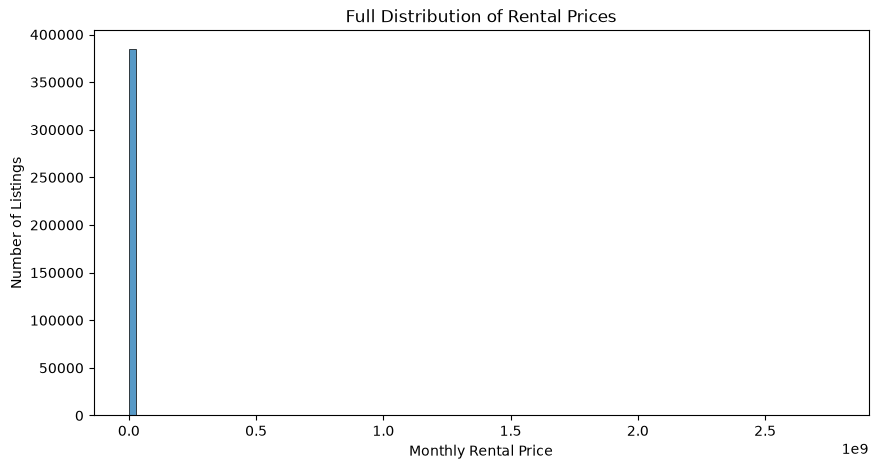

In [33]:
# Visualize the full distribution of rental prices.
# This helps us examine the overall shape of the target variable
# and identify potential skewness and extreme observations.

plt.figure(figsize=(10, 5))

sns.histplot(
    df["price"],
    bins=100
)

plt.title("Full Distribution of Rental Prices")
plt.xlabel("Monthly Rental Price")
plt.ylabel("Number of Listings")

plt.show()

#### 6.1.5 Rental Price Distribution — Up to 99th Percentile

The rental price distribution is visualized up to the 99th percentile to
provide a clearer view of the main concentration of rental prices without
the extreme upper tail dominating the visualization.

This visualization is used only to examine the distribution more clearly
and does not remove observations from the original dataset.

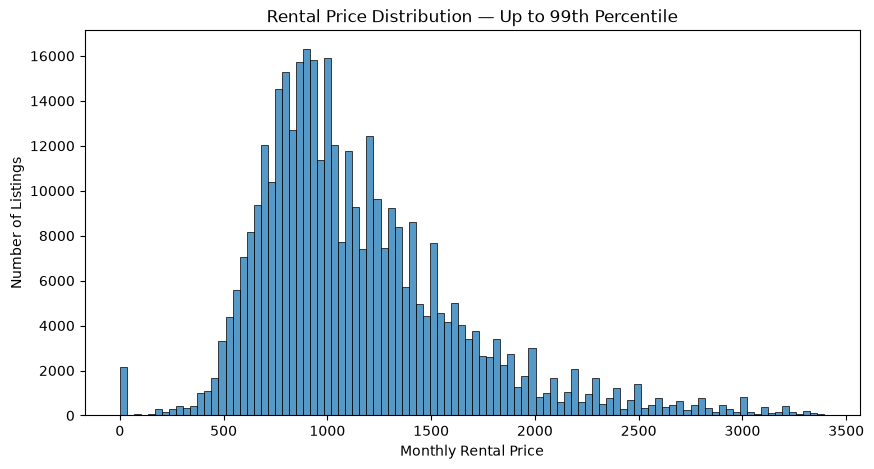

In [34]:
# Calculate the 99th percentile of rental price.
# This value is used only to limit the visualization and does not
# modify or remove observations from the original dataset.

price_99 = df["price"].quantile(0.99)

# Select rental prices up to the 99th percentile for visualization.
price_main_distribution = df.loc[
    df["price"] <= price_99,
    "price"
]

# Plot the main rental price distribution.
plt.figure(figsize=(10, 5))

sns.histplot(
    price_main_distribution,
    bins=100
)

plt.title("Rental Price Distribution — Up to 99th Percentile")
plt.xlabel("Monthly Rental Price")
plt.ylabel("Number of Listings")

plt.show()

#### 6.1.6 Rental Price Boxplot

A boxplot is used to examine the spread of rental prices and identify
potential extreme observations. It provides a visual summary of the
median, interquartile range, and values that lie far from the main
distribution.

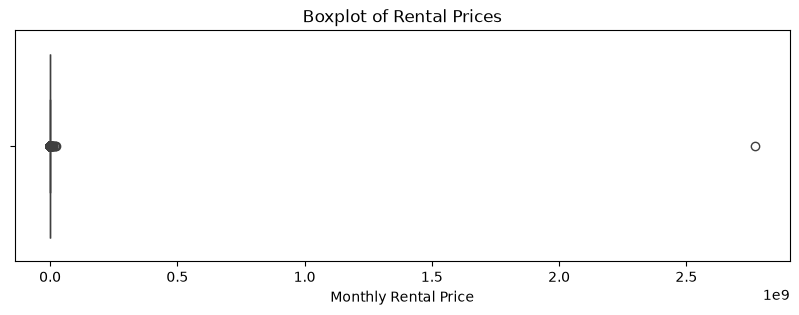

In [35]:
# Create a boxplot to examine the spread of rental prices.
# The boxplot helps identify the median, interquartile range,
# and potential extreme observations.

plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df["price"]
)

plt.title("Boxplot of Rental Prices")
plt.xlabel("Monthly Rental Price")

plt.show()

#### 6.1.7 Log-Transformed Rental Price Distribution

Because the rental price distribution is highly right-skewed, a
logarithmic transformation is examined to determine whether it provides a
more balanced visualization of the target distribution.

The transformation uses `log1p(price)`, which calculates `log(1 + price)`
and allows zero-valued prices to be included.

This transformation is used for exploratory analysis only at this stage.
The original `price` variable is not modified.

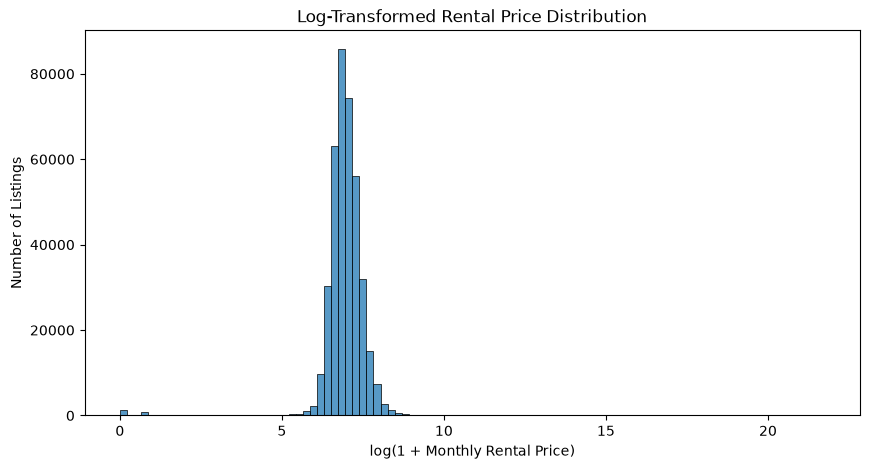

In [36]:
# Apply a log1p transformation to the rental price.
# log1p(price) calculates log(1 + price), which safely handles
# the zero-valued price observations in the dataset.

log_price = np.log1p(df["price"])

# Visualize the log-transformed rental price distribution.
# This helps us determine whether the extreme right skew is reduced
# and whether the main structure of the distribution becomes clearer.

plt.figure(figsize=(10, 5))

sns.histplot(
    log_price,
    bins=100
)

plt.title("Log-Transformed Rental Price Distribution")
plt.xlabel("log(1 + Monthly Rental Price)")
plt.ylabel("Number of Listings")

plt.show()

#### Finding — Price Distribution

The rental price variable shows a highly right-skewed distribution. The
median rental price is $1,036, while the mean is approximately $8,825.72,
indicating that a small number of extremely high values substantially
increase the mean.

The 99th percentile of the rental price is $3,395, while the maximum
recorded value is $2,768,307,249. The full distribution histogram and
boxplot show that these extreme values stretch the scale and compress the
majority of observations into a small region of the visualization.

The distribution up to the 99th percentile provides a clearer view of the
main concentration of rental prices, which is largely concentrated around
the lower price range and gradually decreases as price increases.

The threshold analysis also identified a small number of extremely high
price observations. These observations require further investigation
during preprocessing rather than being automatically removed solely
because they are statistical outliers.

The strong right skew suggests that target transformations, such as a
logarithmic transformation, may be considered during model development
and evaluated experimentally.

### 6.2 Square Footage (`sqfeet`) Distribution

The `sqfeet` variable represents the approximate square footage of each
rental property. Its distribution is examined to understand the typical
property size, spread, skewness, and potential extreme values.

This analysis is important because property size is expected to be an
important predictor of rental price, while unrealistic square-footage
values may indicate data-quality problems.

#### 6.2.1 Square Footage — Descriptive Statistics

Descriptive statistics and selected percentiles are examined to understand
the central tendency, spread, and range of property sizes in the dataset.

In [37]:
# Display descriptive statistics for the square-footage variable.
# This helps us understand the typical property size, its spread,
# minimum and maximum values, and potential extreme observations.

print("Square footage statistics:")
print(df["sqfeet"].describe())

# Display selected percentiles to understand the distribution
# across different points of the dataset.

print("\nSelected percentiles:")
print(
    df["sqfeet"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

Square footage statistics:
count    3.849770e+05
mean     1.059900e+03
std      1.915076e+04
min      0.000000e+00
25%      7.500000e+02
50%      9.490000e+02
75%      1.150000e+03
max      8.388607e+06
Name: sqfeet, dtype: float64

Selected percentiles:
0.01     340.0
0.05     536.0
0.25     750.0
0.50     949.0
0.75    1150.0
0.95    1642.0
0.99    2405.0
Name: sqfeet, dtype: float64


#### 6.2.2 Full Square Footage Distribution

The full distribution of square footage is visualized using a histogram to
examine the overall shape of property sizes and identify potential extreme
observations.

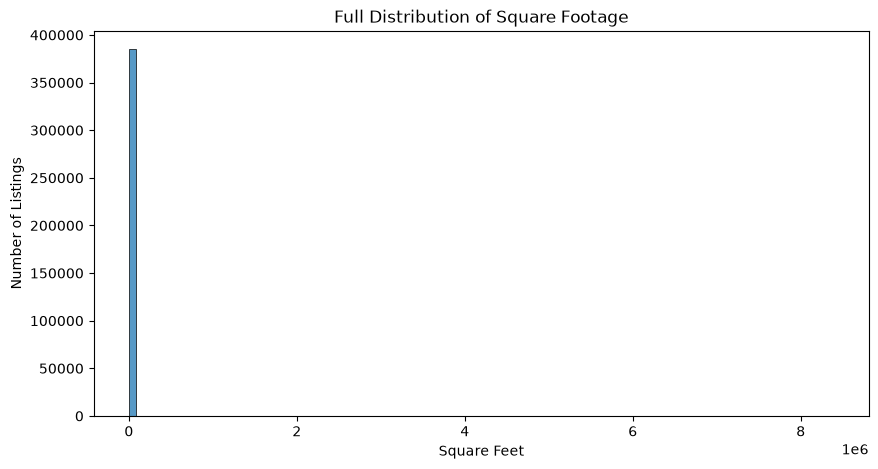

In [38]:
# Visualize the full distribution of square footage.
# This helps us examine the overall shape of property sizes
# and identify potential skewness and extreme observations.

plt.figure(figsize=(10, 5))

sns.histplot(
    df["sqfeet"],
    bins=100
)

plt.title("Full Distribution of Square Footage")
plt.xlabel("Square Feet")
plt.ylabel("Number of Listings")

plt.show()

#### 6.2.3 Square Footage Distribution — Up to 99th Percentile

The square-footage distribution is visualized up to the 99th percentile to
provide a clearer view of the typical property sizes without the extreme
upper tail dominating the visualization.

This visualization is used only for exploratory analysis and does not
remove observations from the original dataset.

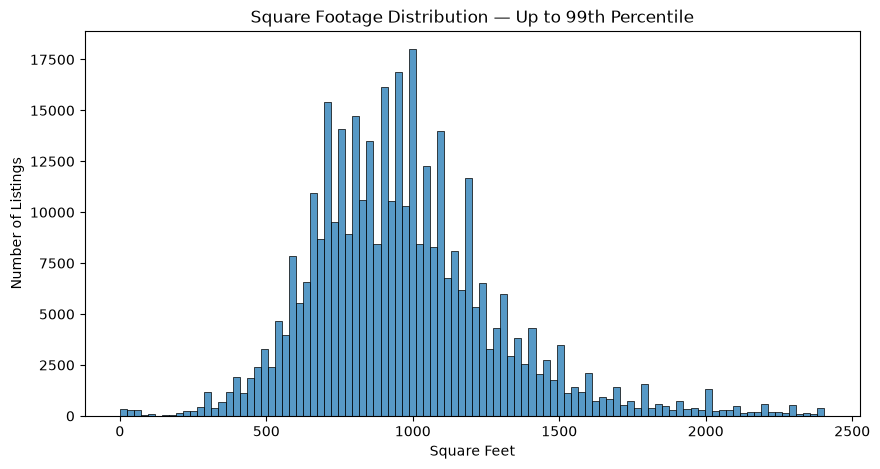

In [39]:
# Calculate the 99th percentile of square footage.
# This value is used only to create a clearer visualization and does not
# modify or remove observations from the original dataset.

sqfeet_99 = df["sqfeet"].quantile(0.99)

# Select square-footage values up to the 99th percentile.
sqfeet_main_distribution = df.loc[
    df["sqfeet"] <= sqfeet_99,
    "sqfeet"
]

# Visualize the main square-footage distribution.
plt.figure(figsize=(10, 5))

sns.histplot(
    sqfeet_main_distribution,
    bins=100
)

plt.title("Square Footage Distribution — Up to 99th Percentile")
plt.xlabel("Square Feet")
plt.ylabel("Number of Listings")

plt.show()

#### 6.2.4 Square Footage Boxplot

A boxplot is used to examine the spread of square footage and identify
potential extreme observations relative to the main distribution.

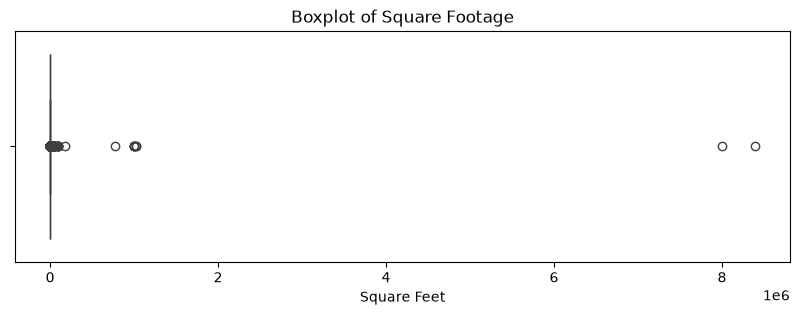

In [40]:
# Create a boxplot to examine the spread of square footage.
# The boxplot helps identify the median, interquartile range,
# and potential extreme observations.

plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df["sqfeet"]
)

plt.title("Boxplot of Square Footage")
plt.xlabel("Square Feet")

plt.show()

#### 6.2.5 Log-Transformed Square Footage Distribution

Because the square-footage distribution contains extreme upper-tail
observations, a logarithmic transformation is examined to provide a clearer
view of the distribution across different property sizes.

The transformation uses `log1p(sqfeet)` so that zero-valued observations can
also be included.

This transformation is used for exploratory analysis only. The original
`sqfeet` variable is not modified.

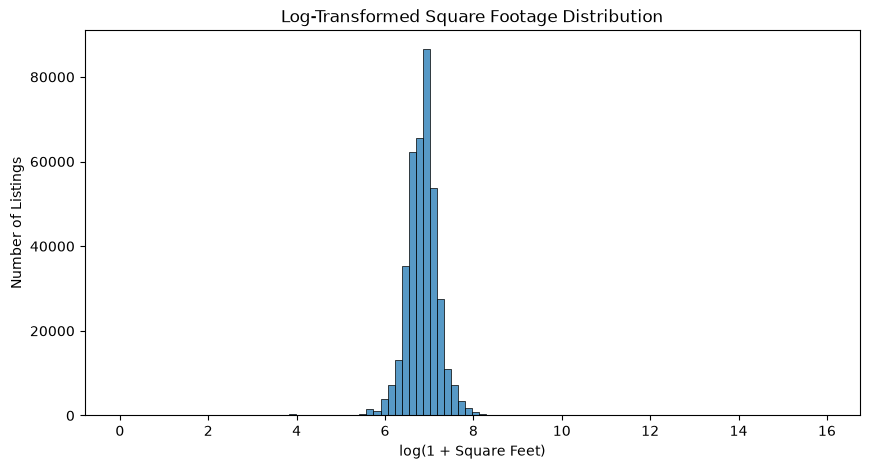

In [41]:
# Apply a log1p transformation to square footage.
# log1p(sqfeet) calculates log(1 + sqfeet), which safely handles
# the zero-valued square-footage observations in the dataset.

log_sqfeet = np.log1p(df["sqfeet"])

# Visualize the log-transformed square-footage distribution.
# This helps us determine whether the extreme right skew is reduced
# and whether the main distribution becomes easier to interpret.

plt.figure(figsize=(10, 5))

sns.histplot(
    log_sqfeet,
    bins=100
)

plt.title("Log-Transformed Square Footage Distribution")
plt.xlabel("log(1 + Square Feet)")
plt.ylabel("Number of Listings")

plt.show()

#### Finding — Square Footage Distribution

The `sqfeet` variable shows a strongly right-skewed distribution with a
large difference between its typical values and its maximum value. The
median square footage is 949 sq ft, while the 99th percentile is 2,405
sq ft and the maximum is 8,388,607 sq ft.

The full distribution and boxplot show that the extreme upper-tail values
strongly stretch the scale and compress the majority of property sizes
into a small region of the visualization.

When the distribution is examined up to the 99th percentile, the main
concentration of properties becomes clearer, with most listings located
approximately within the 600–1,300 sq ft range and the highest
concentration around the 900–1,100 sq ft range.

The log-transformed visualization substantially reduces the visual impact
of the extreme upper-tail observations, indicating that a logarithmic
transformation may be useful for this feature during model development.

The dataset also contains 48 records with `sqfeet = 0`, which were
previously identified as invalid property-size values. These records will
require appropriate treatment during preprocessing.

### 6.3 Bedrooms (`beds`) Distribution

The `beds` variable represents the number of bedrooms reported for each
rental listing. Its distribution is examined to understand the typical
number of bedrooms, the range of values, and the presence of unusual
observations.

#### 6.3.1 Bedrooms — Descriptive Statistics

Descriptive statistics and frequency information are examined to
understand the distribution of bedroom counts and identify uncommon
or potentially unusual values.

In [42]:
# Display descriptive statistics for the number of bedrooms.
# This helps us understand the typical bedroom count, the range
# of values, and potential unusual observations.

print("Bedroom statistics:")
print(df["beds"].describe())

# Display the frequency of each bedroom count.
# This helps us understand which bedroom categories are most common
# and whether there are rare values that require investigation.

print("\nBedroom frequency:")
print(df["beds"].value_counts(dropna=False).sort_index())

Bedroom statistics:
count    384977.000000
mean          1.905345
std           3.494572
min           0.000000
25%           1.000000
50%           2.000000
75%           2.000000
max        1100.000000
Name: beds, dtype: float64

Bedroom frequency:
beds
0        10978
1       117226
2       175513
3        67037
4        11575
5         2324
6          240
7           49
8           31
1000         2
1100         2
Name: count, dtype: int64


#### 6.3.2 Investigation of Unusual Bedroom Values

The frequency analysis identified four listings with unusually large
reported bedroom counts of 1,000 or 1,100 bedrooms. These observations are
examined together with other property attributes to determine whether they
represent plausible listings or potential data-quality errors.

In [43]:
# Select listings with unusually large bedroom counts.
# This allows us to inspect the associated property characteristics
# before deciding how these observations should be treated.

unusual_beds = df.loc[
    df["beds"] >= 9,
    ["beds", "price", "sqfeet", "baths", "type", "region", "state"]
]

# Display the unusual bedroom observations.
print("Listings with 9 or more bedrooms:")
print(unusual_beds)

Listings with 9 or more bedrooms:
        beds  price  sqfeet  baths       type        region state
37695   1000   1500     100   35.0       land  florida keys    fl
89776   1100   2449    1000   75.0  apartment       chicago    il
90779   1100   2449    1000   75.0  apartment       chicago    il
235159  1000    550     250   25.0  apartment    youngstown    oh


#### 6.3.3 Bedroom Distribution

The frequency distribution of bedroom counts is visualized to examine the
most common bedroom categories and the overall distribution of residential
property sizes by number of bedrooms.

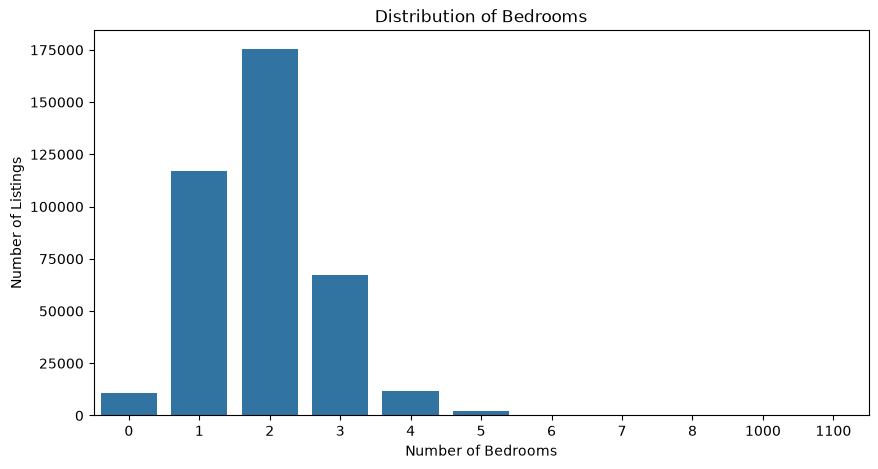

In [44]:
# Count the frequency of each bedroom category.
# This helps us visualize the distribution of bedroom counts
# and identify the most common property configurations.

bed_counts = df["beds"].value_counts().sort_index()

# Plot the bedroom frequency distribution.
plt.figure(figsize=(10, 5))

sns.barplot(
    x=bed_counts.index,
    y=bed_counts.values
)

plt.title("Distribution of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Listings")

plt.show()

#### 6.3.4 Bedroom Distribution — Excluding Extreme Values

The bedroom distribution is visualized after excluding the extremely large
bedroom counts identified during the data-quality investigation.

This visualization is used only to provide a clearer view of the normal
bedroom distribution. The original dataset is not modified.

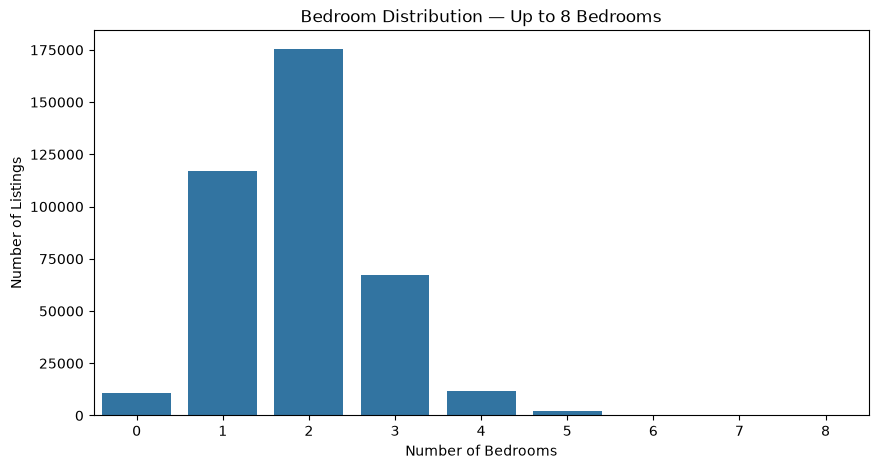

In [45]:
# Select bedroom values that are within the normal residential range
# identified during the exploratory analysis.
# This is used only for visualization and does not modify the dataset.

beds_main_distribution = df.loc[
    df["beds"] <= 8,
    "beds"
]

# Count the frequency of each bedroom category.
bed_counts_main = beds_main_distribution.value_counts().sort_index()

# Visualize the normal bedroom distribution.
plt.figure(figsize=(10, 5))

sns.barplot(
    x=bed_counts_main.index,
    y=bed_counts_main.values
)

plt.title("Bedroom Distribution — Up to 8 Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Listings")

plt.show()

#### 6.3.5 Bedroom Boxplot

A boxplot is used to examine the spread of bedroom counts and identify
potential extreme observations in the variable.

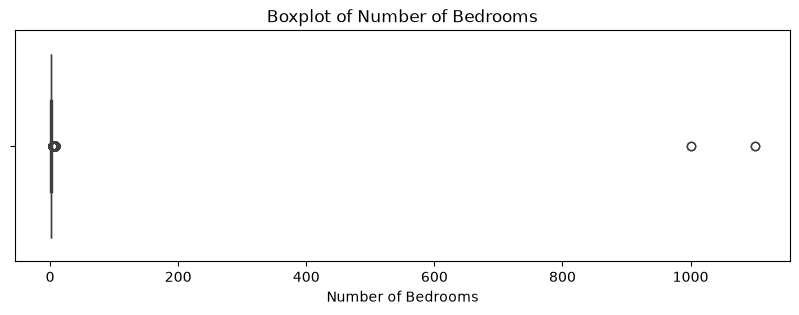

In [46]:
# Create a boxplot to examine the distribution of bedroom counts.
# The boxplot helps identify the median, interquartile range,
# and potential extreme bedroom-count observations.

plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df["beds"]
)

plt.title("Boxplot of Number of Bedrooms")
plt.xlabel("Number of Bedrooms")

plt.show()

#### Finding — Bedroom Distribution

The `beds` variable is primarily concentrated between 0 and 4 bedrooms.
Two-bedroom properties are the most common, with 175,513 listings, followed
by one-bedroom properties with 117,226 listings and three-bedroom
properties with 67,037 listings.

The analysis also identified four highly unusual observations with bedroom
counts of 1,000 or 1,100. Further investigation showed that these records
contain implausible combinations of bedroom counts, square footage, and
bathroom counts. For example, one listing reports 1,100 bedrooms,
2,449 square feet, and 75 bathrooms. These observations are therefore
considered likely data-quality errors and will require appropriate
treatment during preprocessing.

The frequency distribution and boxplot confirm that the 1,000- and
1,100-bedroom observations are extreme compared with the normal bedroom
distribution. After excluding these extreme values for visualization only,
the main distribution is clearly concentrated between 0 and 4 bedrooms,
with higher bedroom counts becoming increasingly rare.

Listings with 0 bedrooms are not automatically considered invalid because
they may represent studio properties.

Since `beds` is a discrete count variable rather than a continuous
measurement, logarithmic transformation is not considered necessary for
this feature.

### 6.4 Bathrooms (`baths`) Distribution

The `baths` variable represents the number of bathrooms reported for each
rental listing. Its distribution is examined to understand the typical
number of bathrooms, the range of values, and the presence of unusual or
extreme observations.

#### 6.4.1 Bathroom Count — Descriptive Statistics

Descriptive statistics and frequency information are examined to
understand the central tendency, spread, and distribution of bathroom
counts, including the presence of fractional bathroom values.

In [47]:
# Display descriptive statistics for the number of bathrooms.
# This helps us understand the typical bathroom count, the range
# of values, and potential unusual observations.

print("Bathroom statistics:")
print(df["baths"].describe())

# Display the frequency of each bathroom count.
# This helps us identify the most common bathroom configurations
# and investigate rare or unusual values.

print("\nBathroom frequency:")
print(df["baths"].value_counts(dropna=False).sort_index())

Bathroom statistics:
count    384977.000000
mean          1.480718
std           0.618061
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          75.000000
Name: baths, dtype: float64

Bathroom frequency:
baths
0.0       3107
1.0     198184
1.5      27363
2.0     134649
2.5      13162
3.0       5549
3.5       1007
4.0       1495
4.5        231
5.0        131
5.5         57
6.0         26
6.5          4
7.0          4
7.5          2
8.0          1
8.5          1
25.0         1
35.0         1
75.0         2
Name: count, dtype: int64


#### 6.4.2 Investigation of Unusual Bathroom Values

The frequency analysis identified several unusually large bathroom counts,
including values of 25, 35, and 75 bathrooms. These observations are
examined together with other property attributes to determine whether they
represent plausible listings or potential data-quality errors.

In [48]:
# Select listings with unusually large bathroom counts.
# This allows us to inspect their associated property characteristics
# before deciding how these observations should be treated.

unusual_baths = df.loc[
    df["baths"] >= 9,
    ["baths", "price", "sqfeet", "beds", "type", "region", "state"]
]

# Display the unusual bathroom observations.
print("Listings with 9 or more bathrooms:")
print(unusual_baths)

Listings with 9 or more bathrooms:
        baths  price  sqfeet  beds       type        region state
37695    35.0   1500     100  1000       land  florida keys    fl
89776    75.0   2449    1000  1100  apartment       chicago    il
90779    75.0   2449    1000  1100  apartment       chicago    il
235159   25.0    550     250  1000  apartment    youngstown    oh


#### 6.4.3 Bathroom Distribution

The frequency distribution of bathroom counts is visualized to examine the
most common bathroom configurations and the overall distribution of
bathroom counts.

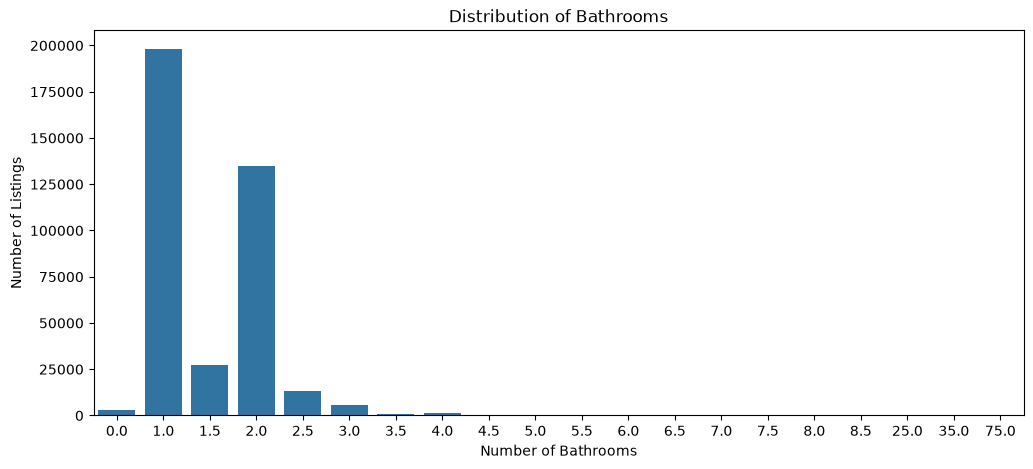

In [49]:
# Count the frequency of each bathroom category.
# This helps us visualize the most common bathroom configurations
# and identify rare or unusual bathroom counts.

bath_counts = df["baths"].value_counts().sort_index()

# Plot the bathroom frequency distribution.
plt.figure(figsize=(12, 5))

sns.barplot(
    x=bath_counts.index,
    y=bath_counts.values
)

plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Listings")

plt.show()

#### 6.4.4 Bathroom Boxplot

A boxplot is used to examine the spread of bathroom counts and identify
potential extreme observations relative to the main distribution.

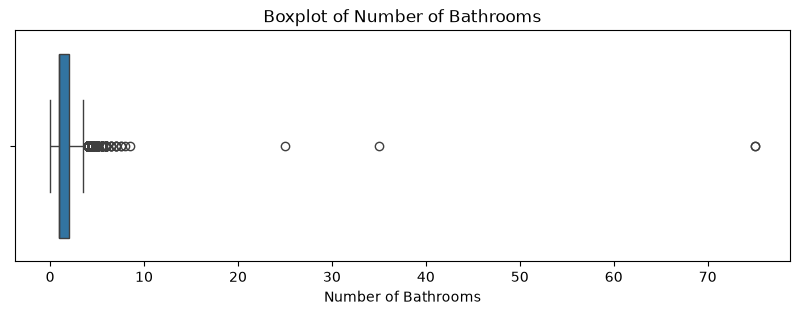

In [50]:
# Create a boxplot to examine the spread of bathroom counts.
# The boxplot helps identify the median, interquartile range,
# and potential extreme bathroom-count observations.

plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df["baths"]
)

plt.title("Boxplot of Number of Bathrooms")
plt.xlabel("Number of Bathrooms")

plt.show()

#### Finding — Bathroom Distribution

The `baths` variable is strongly concentrated around 1 to 2 bathrooms.
One bathroom is the most common value, with 198,184 listings, followed by
two bathrooms with 134,649 listings. Fractional bathroom values such as
1.5, 2.5, and 3.5 are also present and represent valid bathroom
configurations rather than data-quality errors.

The frequency distribution and boxplot identify several extremely large
bathroom counts, including 25, 35, and 75 bathrooms. Further investigation
showed that these values occur in the same four records previously
identified as unusual bedroom observations. These records also contain
implausible combinations of bedrooms and square footage, such as 1,100
bedrooms and 75 bathrooms in a 2,449 sq ft apartment.

Therefore, these four observations are considered likely data-quality
errors and will require appropriate treatment during preprocessing.

Overall, the main bathroom distribution is concentrated around 1 to 2
bathrooms, while larger bathroom counts become increasingly rare. The
presence of fractional bathroom values indicates that `baths` should be
treated as a numerical feature rather than restricting it to whole-number
counts.

### 6.5 Geographic Features (`lat` and `long`)

The `lat` and `long` variables represent the geographic coordinates of
each rental listing. Their distributions are examined to understand the
geographic coverage of the dataset and identify missing or invalid
coordinate values.

Geographic information may provide useful information for rental price
prediction because rental prices can vary across different locations.

#### 6.5.1 Geographic Coordinates — Descriptive Statistics

Descriptive statistics are examined for latitude and longitude to
understand their ranges and identify unusual coordinate values.

In [51]:
# Display descriptive statistics for latitude and longitude.
# This helps us understand the geographic range covered by the dataset
# and identify potentially unusual coordinate values.

print("Latitude statistics:")
print(df["lat"].describe())

print("\nLongitude statistics:")
print(df["long"].describe())

# Display selected percentiles to understand the distribution
# of the geographic coordinates.

print("\nSelected latitude percentiles:")
print(
    df["lat"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

print("\nSelected longitude percentiles:")
print(
    df["long"].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
)

Latitude statistics:
count    383059.000000
mean         37.233487
std           5.546171
min         -43.533300
25%          33.454700
50%          37.647800
75%          41.138300
max         102.036000
Name: lat, dtype: float64

Longitude statistics:
count    383059.000000
mean        -92.700631
std          16.531980
min        -163.894000
25%        -100.775000
50%         -87.745100
75%         -81.179600
max         172.633000
Name: long, dtype: float64

Selected latitude percentiles:
0.01    26.1718
0.05    28.1384
0.25    33.4547
0.50    37.6478
0.75    41.1383
0.95    45.5457
0.99    48.2038
Name: lat, dtype: float64

Selected longitude percentiles:
0.01   -147.37194
0.05   -121.74110
0.25   -100.77500
0.50    -87.74510
0.75    -81.17960
0.95    -74.34507
0.99    -71.30340
Name: long, dtype: float64


#### 6.5.2 Investigation of Unusual Geographic Coordinates

The descriptive statistics identified unusually low and high latitude and
longitude values. These observations are investigated together with their
region, state, and other attributes to determine whether they represent
valid U.S. locations or potential geographic data-quality issues.

In [52]:
# Select listings with extreme latitude or longitude values.
# These observations are inspected together with their geographic
# and property information to identify potentially invalid coordinates.

unusual_coordinates = df.loc[
    (df["lat"] < 20) |
    (df["lat"] > 55) |
    (df["long"] > -60) |
    (df["long"] < -170),
    ["lat", "long", "region", "state", "price", "type", "sqfeet"]
]

# Display the unusual coordinate observations.
print("Listings with potentially unusual geographic coordinates:")
print(unusual_coordinates)

Listings with potentially unusual geographic coordinates:
             lat      long                 region state  price       type  \
27874   19.09740  -96.6497               hartford    ct   1300  townhouse   
53417    4.12942 -126.4740              pensacola    fl    750     duplex   
69538   16.13160  -16.1316                atlanta    ga   1057  apartment   
69851   16.13160  -16.1316                atlanta    ga   1167  apartment   
77863   13.68700  -99.4896  savannah / hinesville    ga   1200      house   
...          ...       ...                    ...   ...    ...        ...   
365036  36.22000   94.1248           fayetteville    ar    840  apartment   
365043  36.22000   94.1248           fayetteville    ar    840  apartment   
365044  36.22000   94.1248           fayetteville    ar    785  apartment   
365063  36.22000   94.1248           fayetteville    ar    840  apartment   
367121 -43.53330  172.6330            bakersfield    ca   3500      house   

        sqfeet  


#### 6.5.3 Geographic Coordinate Validity

Latitude and longitude values are checked against their valid geographic
ranges. Latitude must fall between -90 and 90 degrees, while longitude must
fall between -180 and 180 degrees.

This check distinguishes mathematically invalid coordinate values from
coordinates that may be unusual for the geographic coverage of the dataset.

In [53]:
# Identify latitude values outside the mathematically valid range.
# Valid latitude values must be between -90 and 90 degrees.

invalid_lat = df.loc[
    (df["lat"] < -90) | (df["lat"] > 90),
    ["lat", "long", "region", "state"]
]

# Identify longitude values outside the mathematically valid range.
# Valid longitude values must be between -180 and 180 degrees.

invalid_long = df.loc[
    (df["long"] < -180) | (df["long"] > 180),
    ["lat", "long", "region", "state"]
]

# Display the number of mathematically invalid coordinates.
print("Invalid latitude count:", len(invalid_lat))
print("Invalid longitude count:", len(invalid_long))

# Display the affected records for further investigation.
print("\nInvalid latitude records:")
print(invalid_lat)

print("\nInvalid longitude records:")
print(invalid_long)

Invalid latitude count: 4
Invalid longitude count: 0

Invalid latitude records:
            lat     long       region state
124529  102.036 -147.579  baton rouge    la
124877  102.036 -147.579  baton rouge    la
125273  102.036 -147.579  baton rouge    la
125280  102.036 -147.579  baton rouge    la

Invalid longitude records:
Empty DataFrame
Columns: [lat, long, region, state]
Index: []


#### 6.5.4 Geographic Coordinate Distribution

The geographic coordinates are visualized using a scatter plot of longitude
against latitude. This helps examine the spatial distribution of rental
listings and identify unusual geographic patterns or isolated coordinate
values.

Listings with missing coordinates are excluded from this visualization.

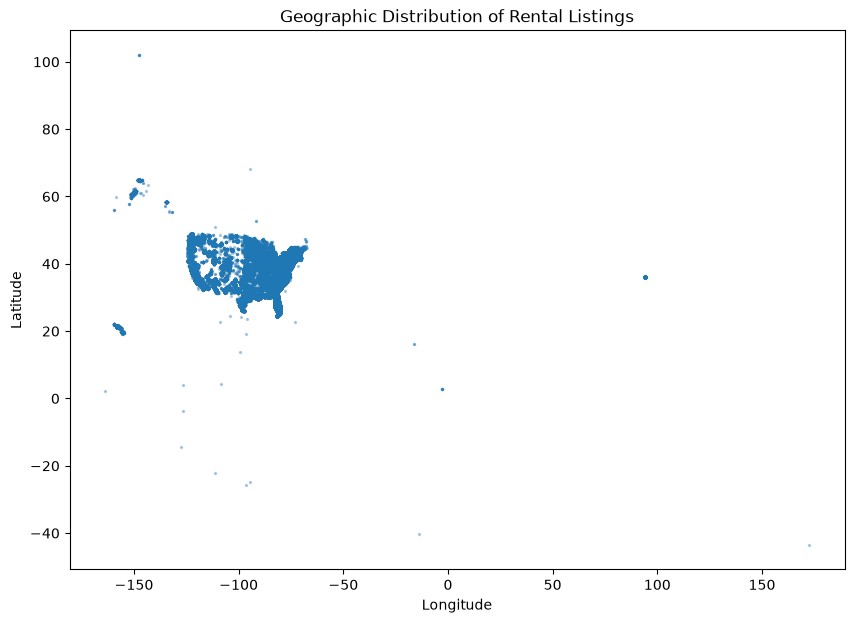

In [54]:
# Select listings with both latitude and longitude available.
# Missing coordinate pairs cannot be plotted geographically.

geo_data = df.dropna(
    subset=["lat", "long"]
)

# Create a scatter plot of the geographic coordinates.
# Longitude is plotted on the x-axis and latitude on the y-axis.

plt.figure(figsize=(10, 7))

plt.scatter(
    geo_data["long"],
    geo_data["lat"],
    s=2,
    alpha=0.3
)

plt.title("Geographic Distribution of Rental Listings")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

#### 6.5.5 Geographic Distribution Using Valid Coordinates

The geographic distribution is visualized again after excluding
mathematically invalid latitude and longitude values. This provides a
clearer representation of the spatial distribution of listings while
retaining the original dataset unchanged.

The visualization is used to distinguish invalid coordinates from other
geographically unusual observations that may require further investigation.

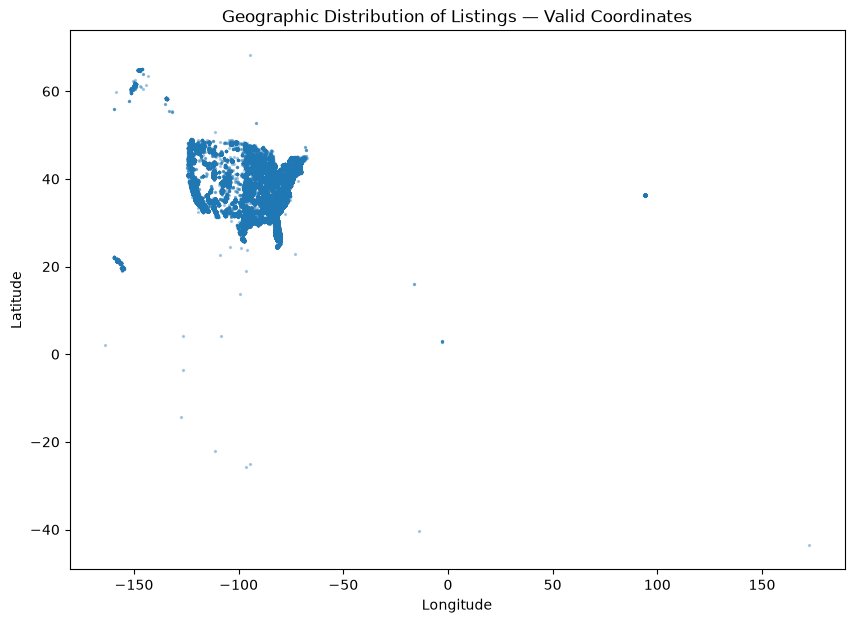

In [55]:
# Select listings with non-missing and mathematically valid coordinates.
# This excludes invalid latitude and longitude values only for visualization.

valid_geo_data = df.loc[
    df["lat"].notna()
    & df["long"].notna()
    & df["lat"].between(-90, 90)
    & df["long"].between(-180, 180)
]

# Create a scatter plot of the valid geographic coordinates.
# Longitude is plotted on the x-axis and latitude on the y-axis.

plt.figure(figsize=(10, 7))

plt.scatter(
    valid_geo_data["long"],
    valid_geo_data["lat"],
    s=2,
    alpha=0.3
)

plt.title("Geographic Distribution of Listings — Valid Coordinates")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

#### 6.5.6 Investigation of Positive Longitude Values

Because the dataset represents U.S. residential listings, positive longitude
values are examined separately as potentially inconsistent geographic
coordinates.

This check is used to identify possible coordinate-entry errors rather than
automatically classifying all geographically unusual observations as
invalid.

In [57]:
# Identify listings with positive longitude values.
# U.S. locations are generally represented by negative longitude values,
# so positive values require additional investigation.

positive_longitude = df.loc[
    df["long"] > 0,
    ["lat", "long", "region", "state", "price", "type"]
]

# Display the number of listings with positive longitude values.

print("Listings with positive longitude:", len(positive_longitude))

# Display the affected records for inspection.

print("\nPositive longitude observations:")
print(positive_longitude)

Listings with positive longitude: 241

Positive longitude observations:
            lat      long        region state  price       type
363365  36.2200   94.1248  fayetteville    ar    720  apartment
363402  36.2200   94.1248  fayetteville    ar    770  apartment
363416  36.2200   94.1248  fayetteville    ar    815  apartment
364131  36.2200   94.1248  fayetteville    ar    855  apartment
364135  36.2200   94.1248  fayetteville    ar    800  apartment
...         ...       ...           ...   ...    ...        ...
365036  36.2200   94.1248  fayetteville    ar    840  apartment
365043  36.2200   94.1248  fayetteville    ar    840  apartment
365044  36.2200   94.1248  fayetteville    ar    785  apartment
365063  36.2200   94.1248  fayetteville    ar    840  apartment
367121 -43.5333  172.6330   bakersfield    ca   3500      house

[241 rows x 6 columns]


#### 6.5.7 Positive Longitude Pattern Analysis

The positive longitude observations are further summarized to identify
repeated coordinate patterns and determine whether the unusual values are
isolated observations or repeated geographic data-quality patterns.

In [58]:
# Group positive-longitude observations by their latitude, longitude,
# region, and state values.
# This helps identify repeated coordinate patterns in the affected records.

positive_longitude_patterns = (
    positive_longitude
    .groupby(
        ["lat", "long", "region", "state"],
        dropna=False
    )
    .size()
    .reset_index(name="listing_count")
    .sort_values("listing_count", ascending=False)
)

# Display the most frequent positive-longitude patterns.

print("Positive longitude coordinate patterns:")
print(positive_longitude_patterns)

Positive longitude coordinate patterns:
       lat      long        region state  listing_count
3  36.2200   94.1248  fayetteville    ar            238
0 -43.5333  172.6330   bakersfield    ca              1
1  36.2010   94.1055  fayetteville    ar              1
2  36.2053   94.1561  fayetteville    ar              1


#### 6.5.8 Verification of Repeated Positive Longitude Coordinates

The dominant positive-longitude coordinate pattern is compared with
nearby negative-longitude coordinates to determine whether the affected
observations may represent a longitude sign error.

This check provides additional evidence before deciding how these
coordinates should be handled during preprocessing.

In [59]:
# Define the dominant positive-longitude coordinate pattern identified
# in the previous analysis.

target_lat = 36.2200
target_long = 94.1248

# Search for listings with the same latitude and the corresponding
# negative longitude value.
# This helps determine whether the positive longitude may be a sign error.

matching_negative_longitude = df.loc[
    (df["lat"] == target_lat) &
    (df["long"] == -target_long),
    ["lat", "long", "region", "state", "price", "type", "sqfeet"]
]

# Display the number of matching records and a sample of them.

print("Matching records with the negative longitude:")
print(f"Number of records: {len(matching_negative_longitude):,}")

print("\nSample records:")
print(matching_negative_longitude.head(20))

Matching records with the negative longitude:
Number of records: 0

Sample records:
Empty DataFrame
Columns: [lat, long, region, state, price, type, sqfeet]
Index: []


#### Finding — Geographic Features

The geographic analysis shows that the dataset contains 1,918 listings
with missing latitude and longitude values. Among the available
coordinates, four records contain mathematically invalid latitude values
of 102.036, which falls outside the valid latitude range of -90 to 90
degrees. No longitude values were found outside the mathematically valid
range.

The geographic scatter plot shows that the majority of listings form a
broad spatial distribution consistent with the United States, while a
small number of observations appear geographically unusual.

A further investigation identified 241 listings with positive longitude
values. Most of these observations (238 listings) share the same
coordinates, 36.2200 latitude and 94.1248 longitude, and are associated
with Fayetteville, Arkansas. However, an exact matching set using the
corresponding negative longitude was not found in the dataset. Therefore,
these observations are documented as potentially inconsistent geographic
data rather than being automatically corrected.

The geographic analysis indicates that missing and invalid coordinate
values will require appropriate treatment during preprocessing. Geographic
features may still provide useful information for rental price prediction,
but coordinate quality must be considered before they are used for
modeling.

### 6.6 Categorical Feature Distributions

The categorical features are examined to understand their frequency
distributions and identify dominant, rare, or highly imbalanced categories.

The analysis focuses on property type, state, region, laundry options, and
parking options. Understanding these distributions helps determine
appropriate encoding and preprocessing strategies for the machine learning
models.

#### 6.6.1 Property Type Distribution

The distribution of property types is visualized to identify the most
common property categories and the presence of rare property types.

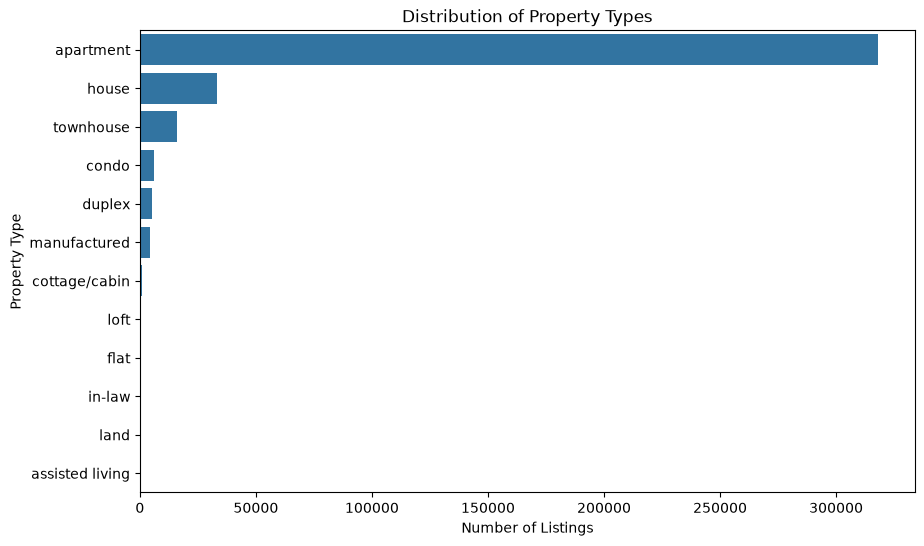

In [60]:
# Count the frequency of each property type.
# This allows us to compare the prevalence of different property types
# in the rental listings.

type_counts = (
    df["type"]
    .value_counts()
    .sort_values(ascending=False)
)

# Visualize the property type distribution.
plt.figure(figsize=(10, 6))

sns.barplot(
    x=type_counts.values,
    y=type_counts.index
)

plt.title("Distribution of Property Types")
plt.xlabel("Number of Listings")
plt.ylabel("Property Type")

plt.show()

#### Interpretation

The property type distribution is highly imbalanced. Apartments are by far
the most common property type, followed by houses and townhouses. The
remaining property types occur much less frequently, with categories such
as `land` and `assisted living` appearing only a small number of times.

This indicates that the `type` feature contains several rare categories.
However, rare categories are not automatically considered invalid and will
not be removed solely because of their low frequency. Their treatment will
be considered during preprocessing and categorical encoding.

#### 6.6.2 State Distribution

The `state` feature represents the U.S. state associated with each rental
listing. Its distribution is examined to understand how rental listings
are geographically represented across the dataset.

The analysis focuses on the number and percentage of listings contributed
by each state. This helps identify dominant states, rare categories, and
potential geographic imbalance that may need to be considered during
preprocessing and model evaluation.

##### 6.6.2.1 State Frequency and Percentage

The frequency and percentage of listings for each state are calculated
to determine how evenly the dataset is distributed across states.

In [61]:
# Count the number of rental listings belonging to each state.
# This helps us understand the geographic representation of the dataset.

state_counts = df["state"].value_counts()

# Calculate the percentage of the total dataset represented by each state.
# This allows us to compare states relative to the full dataset size.

state_percentage = (
    state_counts / len(df) * 100
).round(2)

# Combine the count and percentage into a single table
# for easier interpretation.

state_distribution = pd.DataFrame({
    "listing_count": state_counts,
    "percentage": state_percentage
})

state_distribution

,listing_count,percentage
state,,
ca,33085,8.59
fl,31929,8.29
tx,31137,8.09
nc,18628,4.84
mi,14529,3.77
ga,13841,3.60
oh,12884,3.35
tn,11541,3.00
co,11308,2.94


##### 6.6.2.2 Rare State Categories

The least represented states are examined to identify categories with very
small numbers of rental listings. These rare categories may provide limited
observations for model training and should therefore be considered during
categorical preprocessing and model evaluation.

In [62]:
# Display the states with the lowest number of rental listings.
# This helps identify rare categories with limited representation.

rare_states = state_distribution.sort_values(
    "listing_count",
    ascending=True
).head(10)

rare_states

,listing_count,percentage
state,,
wy,187,0.05
me,420,0.11
vt,527,0.14
wv,819,0.21
mt,1339,0.35
nh,1761,0.46
sd,1782,0.46
hi,1840,0.48
ri,1889,0.49


##### Interpretation

The dataset contains several states with relatively low representation.
Wyoming has the fewest listings with 187 records (0.05%), followed by
Maine with 420 listings (0.11%) and Vermont with 527 listings (0.14%).

These states are considered rare categories because they contain
substantially fewer observations than the most represented states.
However, low frequency does not indicate invalid data, so these categories
will not be removed solely because of their low representation.

The unequal distribution indicates that the `state` feature is
geographically imbalanced and this should be considered during categorical
encoding and model evaluation.

##### 6.6.2.3 Dominant State Categories

The most frequently represented states are examined to identify states
that contribute a large proportion of the rental listings.

In [63]:
# Display the states with the highest number of rental listings.
# This helps identify dominant categories in the dataset.

dominant_states = state_distribution.sort_values(
    "listing_count",
    ascending=False
).head(10)

dominant_states

,listing_count,percentage
state,,
ca,33085,8.59
fl,31929,8.29
tx,31137,8.09
nc,18628,4.84
mi,14529,3.77
ga,13841,3.60
oh,12884,3.35
tn,11541,3.00
co,11308,2.94


##### Interpretation

The state distribution is uneven, with several states contributing a
substantial proportion of the total rental listings.

California has the largest representation with 33,085 listings (8.59%),
followed by Florida with 31,929 listings (8.29%) and Texas with 31,137
listings (8.09%). North Carolina is the next most represented state with
18,628 listings (4.84%).

Compared with the rare-state analysis, this shows that the dataset is not
uniformly distributed across the 51 state categories. Some states have
substantially more observations than others.

This geographic imbalance should be considered when encoding the `state`
feature and when evaluating model performance across different geographic
areas.

##### 6.6.2.4 State Distribution Visualization

The frequency of rental listings across all states is visualized to
provide an overall view of the geographic distribution of the dataset.

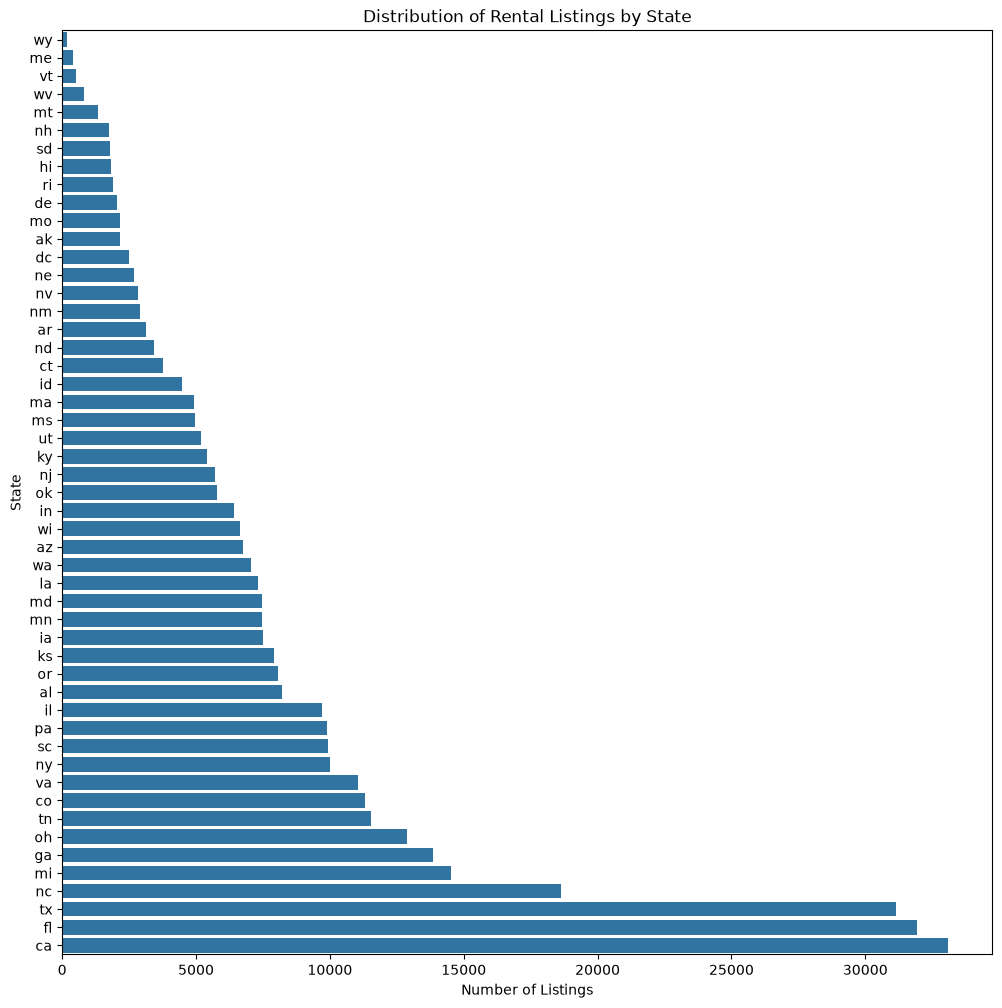

In [64]:
# Sort states by listing count so that the bar chart
# clearly shows the relative representation of each state.

state_plot_data = state_distribution.sort_values(
    "listing_count",
    ascending=True
)

# Create a horizontal bar chart because there are 51 state categories.
# Horizontal bars make the state labels easier to read.

plt.figure(figsize=(12, 12))

sns.barplot(
    x=state_plot_data["listing_count"],
    y=state_plot_data.index
)

plt.title("Distribution of Rental Listings by State")
plt.xlabel("Number of Listings")
plt.ylabel("State")

plt.show()

##### Interpretation

The visualization confirms that rental listings are unevenly distributed
across states. California, Florida, and Texas have substantially more
listings than most other states, while states such as Wyoming, Maine,
Vermont, and West Virginia have relatively few listings.

This indicates that the `state` feature has noticeable geographic
imbalance, with some categories being much more strongly represented than
others.

The low-frequency states are not considered invalid observations simply
because they contain fewer listings. Instead, their limited representation
will be considered when selecting an appropriate categorical encoding
strategy and when evaluating model performance.

#### Finding — State Distribution

The `state` feature contains 51 categories and no missing values. The
distribution of listings across states is highly uneven.

California has the largest number of listings with 33,085 (8.59%),
followed by Florida with 31,929 (8.29%) and Texas with 31,137 (8.09%).
In contrast, Wyoming has only 187 listings (0.05%).

Therefore, the `state` feature provides useful geographic information but
contains substantial differences in category frequency. This imbalance
should be considered during categorical encoding and model evaluation.
Rare states should not be removed solely because of their low frequency.

#### 6.6.3 Region Distribution

The `region` feature represents the geographic market or area associated
with each rental listing. Since this feature contains a large number of
unique categories, its distribution is examined to understand its
cardinality, dominant categories, and rare categories.

This analysis is important for determining an appropriate encoding strategy
during preprocessing because high-cardinality categorical features can
substantially increase the number of model input features when encoded.

##### 6.6.3.1 Region Frequency and Cardinality

The number of unique values and the frequency of each `region` category
are examined to understand the cardinality and distribution of this
geographic feature.

Because `region` contains many categories, this analysis helps determine
whether the feature has a high-cardinality structure and whether some
regions are represented by only a small number of listings.

In [65]:
# Count the number of unique region categories.
# This measures the cardinality of the region feature.

region_unique_count = df["region"].nunique()

print("Number of unique regions:", region_unique_count)

# Count the number of listings belonging to each region.
# This allows us to examine how frequently each region occurs.

region_counts = df["region"].value_counts()

print("\nTotal region categories:", len(region_counts))
print("Total listings:", region_counts.sum())

Number of unique regions: 404

Total region categories: 404
Total listings: 384977


##### 6.6.3.2 Rare Region Categories

The least represented regions are examined to identify categories with
very small numbers of rental listings.

This helps determine whether the `region` feature contains many rare
categories, which may affect the choice of categorical encoding during
preprocessing.

In [66]:
# Display the regions with the fewest rental listings.
# This helps identify rare categories within the high-cardinality
# region feature.

rare_regions = (
    region_counts
    .sort_values(ascending=True)
    .head(15)
)

rare_regions

region
kansas city              3
fort smith, AR           5
southwest TX             9
st louis                 9
southwest MS            12
susanville              15
twin tiers NY/PA        18
pierre / central SD     18
owensboro               18
west virginia (old)     19
kirksville              22
mason city              25
del rio / eagle pass    25
southern WV             26
lewiston / clarkston    27
Name: count, dtype: int64

##### Interpretation

The `region` feature contains several very rare categories. The least
represented region has only 3 listings, while several other regions have
fewer than 20 listings.

This indicates that the 404 region categories are not evenly distributed.
Some regions have substantial numbers of listings, while others have very
limited representation.

These rare categories are not automatically considered invalid because
they represent valid region labels in the dataset. However, their low
frequency is important when selecting an encoding strategy because
high-cardinality features with many rare categories can increase the
complexity of the model representation.

##### 6.6.3.3 Dominant Region Categories

The most frequently represented regions are examined to identify dominant
categories within the high-cardinality `region` feature.

In [68]:
# Display the regions with the highest number of rental listings.
# This helps identify the dominant categories within the region feature.

dominant_regions = (
    region_counts
    .sort_values(ascending=False)
    .head(15)
)

dominant_regions

region
jacksonville              4246
columbus                  3738
rochester                 3677
jackson                   3667
fayetteville              3652
fredericksburg            2747
omaha / council bluffs    2727
salt lake city            2719
denver                    2671
seattle-tacoma            2626
savannah / hinesville     2621
boulder                   2614
portland                  2596
ventura county            2579
stockton                  2571
Name: count, dtype: int64

##### Interpretation

The region distribution is highly uneven. The most frequently represented
region is `jacksonville` with 4,246 listings, followed by `columbus`,
`rochester`, `jackson`, and `fayetteville`, each with more than 3,600
listings.

In contrast, the rare-region analysis identified categories with only a
few observations, including `kansas city` with 3 listings.

The large difference between the most and least represented categories
confirms that `region` is a high-cardinality and highly imbalanced
categorical feature. This characteristic will need to be considered when
selecting an encoding strategy during preprocessing.

##### 6.6.3.4 Top Region Distribution

The 20 most frequently represented regions are visualized to provide a
clear view of the dominant categories without overcrowding the plot with
all 404 region categories.

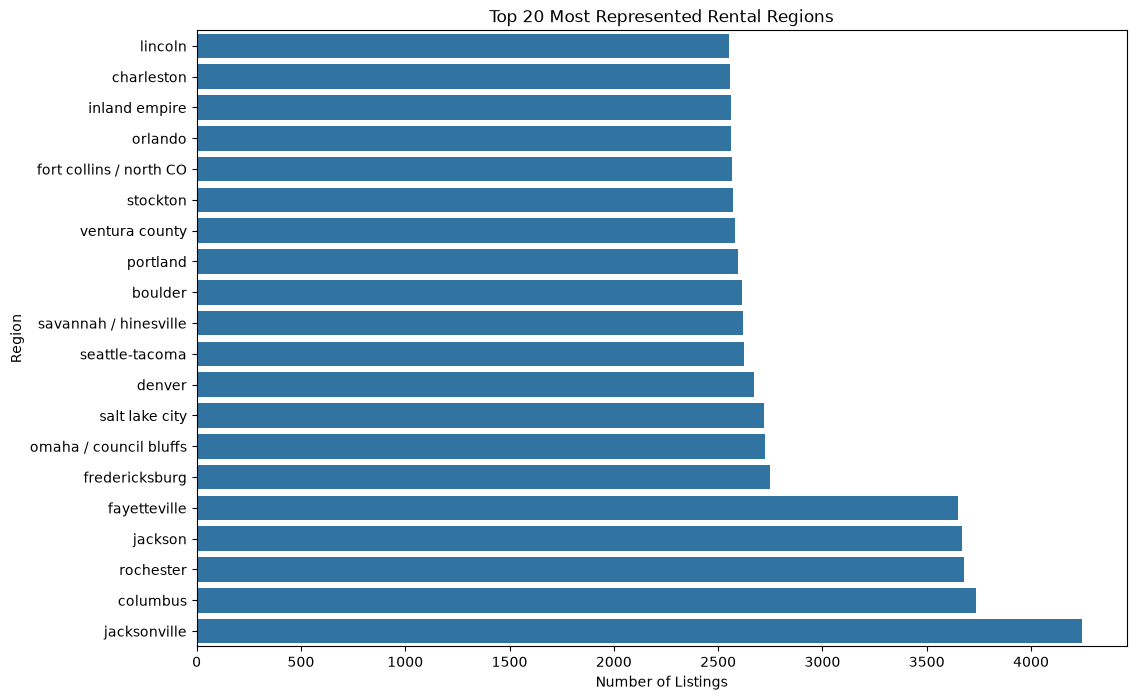

In [69]:
# Select the 20 most frequently represented regions.
# This is used only for visualization because plotting all 404 categories
# would make the chart difficult to interpret.

top_regions = (
    region_counts
    .sort_values(ascending=False)
    .head(20)
    .sort_values(ascending=True)
)

# Create a horizontal bar chart to make the region names easier to read.

plt.figure(figsize=(12, 8))

sns.barplot(
    x=top_regions.values,
    y=top_regions.index
)

plt.title("Top 20 Most Represented Rental Regions")
plt.xlabel("Number of Listings")
plt.ylabel("Region")

plt.show()

##### Interpretation

The visualization of the top 20 regions shows that `jacksonville` has the
largest number of listings, followed by `columbus`, `rochester`, `jackson`,
and `fayetteville`.

The top regions contain substantially more observations than the rare
regions identified earlier. Since only the 20 most frequent regions are
visualized out of 404 total categories, the plot provides a view of the
dominant categories without representing the full distribution.

The combination of dominant and rare categories confirms that `region` is
a high-cardinality and highly uneven categorical feature. This will be an
important consideration when selecting the encoding and preprocessing
strategy.

#### Finding — Region Distribution

The `region` feature contains 404 unique categories and no missing values,
making it a high-cardinality categorical feature.

The distribution is highly uneven. The most represented region,
`jacksonville`, contains 4,246 listings, while the least represented
region identified in the analysis, `kansas city`, contains only 3 listings.

The analysis therefore identified both dominant and very rare region
categories. These categories are not considered invalid solely because of
their frequency, but the high cardinality and uneven distribution will
need to be considered when selecting an appropriate categorical encoding
strategy during preprocessing.

The top-20 visualization was used for readability and does not imply that
the remaining region categories will be removed.

#### 6.6.4 Laundry Options Distribution

The `laundry_options` feature describes the laundry facilities associated
with each rental listing.

Its frequency distribution is examined to understand the available
categories and their representation in the dataset. Missing values are
also considered separately because a missing value does not necessarily
indicate that the property has no laundry facilities.

##### 6.6.4.1 Laundry Options Frequency and Percentage

The frequency and percentage of each laundry option are calculated to
understand how the listings are distributed across the available
categories, including missing values.

In [70]:
# Count each laundry option, including missing values.
# dropna=False is important because missing laundry information
# is part of the data-quality analysis.

laundry_counts = df["laundry_options"].value_counts(
    dropna=False
)

# Calculate the percentage represented by each category.
# This makes the frequency of each option easier to compare.

laundry_percentage = (
    laundry_counts / len(df) * 100
).round(2)

# Combine the count and percentage into one table
# for easier interpretation.

laundry_distribution = pd.DataFrame({
    "listing_count": laundry_counts,
    "percentage": laundry_percentage
})

laundry_distribution

,listing_count,percentage
laundry_options,,
w/d in unit,131783,34.23
NaN,79026,20.53
w/d hookups,75568,19.63
laundry on site,58873,15.29
laundry in bldg,36103,9.38
no laundry on site,3624,0.94


##### Interpretation

The `laundry_options` feature contains five observed laundry categories
along with missing values.

The most common category is `w/d in unit`, representing 131,783 listings
(34.23%). This is followed by `w/d hookups` with 75,568 listings
(19.63%) and `laundry on site` with 58,873 listings (15.29%).

A substantial proportion of listings, 79,026 (20.53%), have missing
`laundry_options` information. This missing category is distinct from
`no laundry on site`, which is explicitly reported for 3,624 listings
(0.94%).

Therefore, missing laundry information should not automatically be
interpreted as the absence of laundry facilities. The missing values will
require appropriate treatment during preprocessing.

##### 6.6.4.2 Laundry Options Visualization

The frequency of each laundry option is visualized, including missing
values, to clearly compare the representation of the available categories
and the extent of missing information.

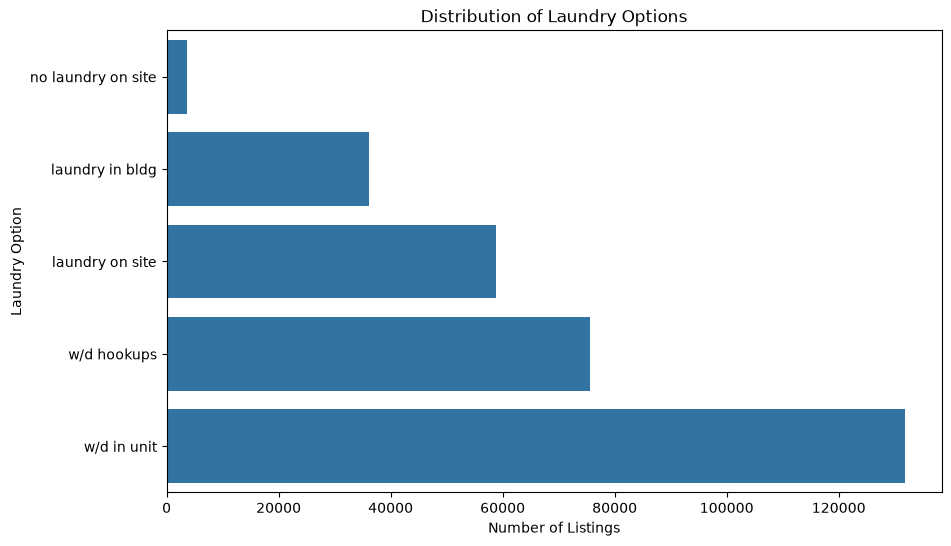

In [71]:
# Create a copy of the laundry distribution table for visualization.
# Missing values are given an explicit label so that they remain visible
# in the chart.

laundry_plot_data = laundry_distribution.copy()

laundry_plot_data.index = laundry_plot_data.index.astype(str)

laundry_plot_data = laundry_plot_data.sort_values(
    "listing_count",
    ascending=True
)

# Create a horizontal bar chart because the category names are descriptive
# and need enough space to remain readable.

plt.figure(figsize=(10, 6))

sns.barplot(
    x=laundry_plot_data["listing_count"],
    y=laundry_plot_data.index
)

plt.title("Distribution of Laundry Options")
plt.xlabel("Number of Listings")
plt.ylabel("Laundry Option")

plt.show()

#### Interpretation

The distribution shows that `w/d in unit` is the most common laundry
option, followed by `w/d hookups` and `laundry on site`.

The explicit category `no laundry on site` is relatively uncommon,
representing only a small proportion of listings.

However, the missing values are not displayed in this visualization.
There are 79,026 missing values (20.53%) in the original dataset.
These missing values represent unavailable or unrecorded information and
should not be interpreted as properties having no laundry facilities.

#### Finding — Laundry Options Distribution

The `laundry_options` feature contains five observed categories and
79,026 missing values (20.53%). The most common category is
`w/d in unit` with 131,783 listings (34.23%), followed by
`w/d hookups` with 75,568 listings (19.63%).

The explicit category `no laundry on site` represents only 3,624
listings (0.94%). Therefore, missing values cannot be treated as
equivalent to `no laundry on site`.

The feature contains substantial missing categorical information, which
will require appropriate treatment during preprocessing.

#### 6.6.5 Parking Options Distribution

The `parking_options` feature describes the type of parking facility
associated with each rental listing.

Its frequency distribution is examined to understand the available
parking categories and their representation in the dataset. Missing
values are also considered separately because a missing value does not
necessarily indicate that the property has no parking.

In [72]:
# Count each parking option, including missing values.
# Keeping missing values visible helps distinguish unavailable
# information from the explicit "no parking" category.
parking_counts = df["parking_options"].value_counts(dropna=False)

# Calculate the percentage of listings represented by each category.
parking_percentage = (parking_counts / len(df) * 100).round(2)

# Combine counts and percentages into one table for easier interpretation.
parking_distribution = pd.DataFrame({
    "listing_count": parking_counts,
    "percentage": parking_percentage
})

parking_distribution

,listing_count,percentage
parking_options,,
NaN,140687,36.54
off-street parking,128502,33.38
attached garage,40591,10.54
carport,38955,10.12
detached garage,16940,4.40
street parking,15951,4.14
no parking,3188,0.83
valet parking,163,0.04


#### 6.6.5.1 Parking Options Distribution

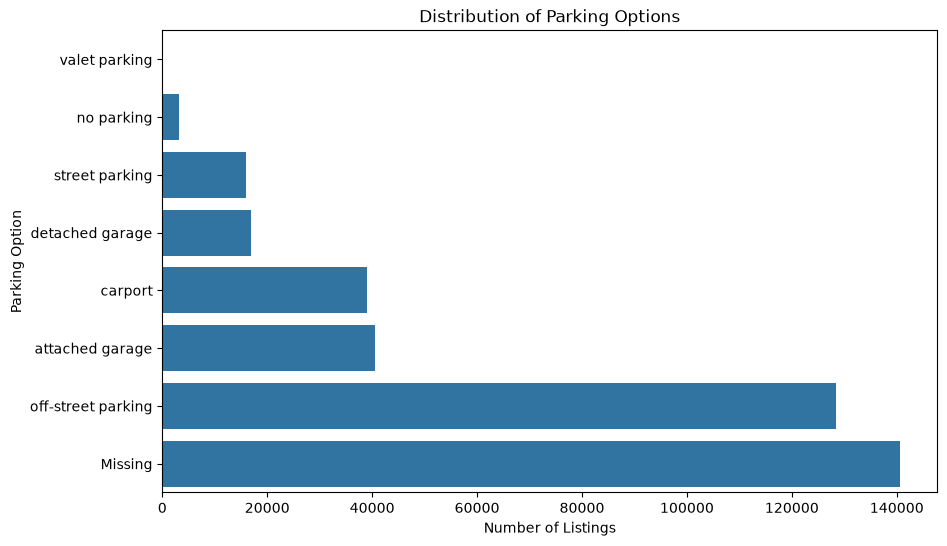

In [73]:
# Create a copy of the parking distribution table for visualization.
# A separate copy allows us to label missing values clearly without
# changing the original analysis table.
parking_plot_data = parking_distribution.copy()

# Replace the missing-value label with "Missing" so that the chart
# clearly distinguishes missing information from the "no parking" category.
parking_plot_data.index = parking_plot_data.index.map(
    lambda x: "Missing" if pd.isna(x) else str(x)
)

# Sort the categories by listing count so the horizontal bars
# are easier to compare.
parking_plot_data = parking_plot_data.sort_values(
    "listing_count",
    ascending=True
)

# Create a horizontal bar chart to compare the frequency
# of each parking category.
plt.figure(figsize=(10, 6))

sns.barplot(
    x=parking_plot_data["listing_count"],
    y=parking_plot_data.index
)

plt.title("Distribution of Parking Options")
plt.xlabel("Number of Listings")
plt.ylabel("Parking Option")
plt.show()

#### Interpretation

The distribution shows that `off-street parking` is the most common
reported parking option, with 128,502 listings (33.38%).

However, the largest category is actually `Missing`, with 140,687
listings (36.54%). This indicates that a substantial proportion of
listings do not provide parking information.

Other common reported options include `attached garage` with 40,591
listings (10.54%) and `carport` with 38,955 listings (10.12%).

The explicit category `no parking` represents only 3,188 listings
(0.83%), which is much smaller than the number of missing values.
Therefore, missing parking information should not be interpreted as
meaning that the property has no parking.

#### Finding — Parking Options Distribution

The `parking_options` feature contains seven observed categories and
140,687 missing values (36.54%). Among the reported parking options,
`off-street parking` is the most common category with 128,502 listings
(33.38%).

The explicit `no parking` category contains only 3,188 listings
(0.83%), while more than one-third of all listings have missing parking
information. Therefore, missing values cannot be treated as equivalent
to `no parking`.

The substantial amount of missing categorical information will require
appropriate treatment during preprocessing.

## 7. Relationship Analysis

This section examines the relationships between the rental price and
important property and geographic features.

The purpose is to identify patterns, trends, and potential associations
that may help determine which variables are useful for predicting rental
prices.

The analysis focuses on the relationship between `price` and numerical
features such as `sqfeet`, `beds`, and `baths`, followed by relationships
with categorical and geographic features.

### 7.1 Rental Price vs Square Footage

The relationship between rental price and square footage is examined to
determine whether larger properties tend to have different rental prices.

Square footage is an important candidate predictor because property size
can influence rental value. However, extreme values identified earlier may
distort the visualization, so the relationship should be examined carefully.

In [74]:
 # Calculate the Pearson correlation between rental price and square footage.
# This measures the strength and direction of their linear relationship.
price_sqfeet_corr = df["price"].corr(df["sqfeet"])

print(f"Correlation between price and square footage: {price_sqfeet_corr:.4f}")

Correlation between price and square footage: 0.0000


In [75]:
# Calculate the Pearson correlation again without rounding to four decimals.
# More decimal places help us determine whether the correlation is truly
# close to zero or only appears as zero because of rounding.
price_sqfeet_corr = df["price"].corr(df["sqfeet"])

print(f"Exact Pearson correlation: {price_sqfeet_corr:.8f}")

Exact Pearson correlation: 0.00000919


#### 7.1.2 Scatter Plot — Price vs Square Footage

A scatter plot is used to visually examine the relationship between
rental price and square footage.

The raw dataset is used initially so that extreme observations can be
observed rather than removed without investigation.

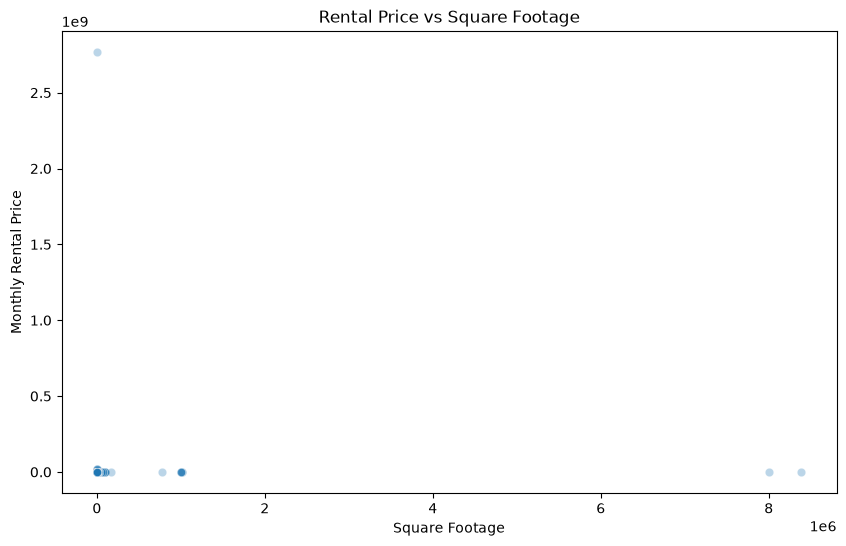

In [76]:
# Create a scatter plot to examine the relationship between
# rental price and square footage across all listings.
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="sqfeet",
    y="price",
    alpha=0.3
)

plt.title("Rental Price vs Square Footage")
plt.xlabel("Square Footage")
plt.ylabel("Monthly Rental Price")
plt.show()

#### 7.1.3 Focused Scatter Plot — Main Distribution

The raw scatter plot is strongly affected by extreme price and square
footage values identified during the earlier outlier analysis.

Therefore, a second scatter plot is created using the 99th percentiles
of `price` and `sqfeet` as visualization limits. This allows the main
distribution of rental listings to be examined more clearly without
deleting the extreme observations from the dataset.

The filtering in this visualization is used only to improve readability
and does not represent a final data-cleaning decision.

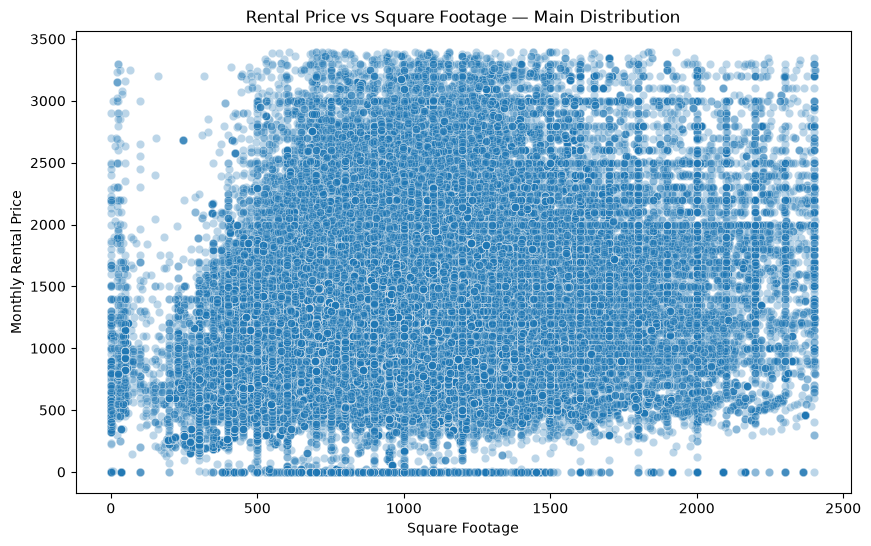

In [77]:
# Calculate the 99th percentile limits for price and square footage.
# These limits are used only to focus the visualization on the main
# concentration of observations.
price_99 = df["price"].quantile(0.99)
sqfeet_99 = df["sqfeet"].quantile(0.99)

# Select observations within both 99th percentile limits.
# This does not modify or delete the original dataframe.
price_sqfeet_main = df.loc[
    (df["price"] <= price_99) &
    (df["sqfeet"] <= sqfeet_99)
]

# Create a scatter plot of the main distribution.
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=price_sqfeet_main,
    x="sqfeet",
    y="price",
    alpha=0.3
)

plt.title("Rental Price vs Square Footage — Main Distribution")
plt.xlabel("Square Footage")
plt.ylabel("Monthly Rental Price")
plt.show()

#### Interpretation

The focused scatter plot shows a very wide variation in rental prices
across different square-footage values. Although there may be a weak
positive tendency for rental prices to increase as square footage
increases, the relationship is not strong or clearly linear.

A large range of rental prices can be observed for properties with
similar square footage. This indicates that square footage alone does not
adequately explain rental price and that other factors, such as location,
property type, bedrooms, bathrooms, and property features, may also
contribute to rental price variation.

The plot also shows observations with a rental price of zero, which is
consistent with the invalid target values identified during the earlier
data-quality analysis.

#### 7.1.4 Spearman Correlation — Price vs Square Footage

Pearson correlation measures the strength of a linear relationship and
can be strongly affected by extreme values.

Therefore, Spearman rank correlation is also examined to determine whether
there is a general monotonic relationship between rental price and square
footage.

In [78]:
# Calculate the Spearman rank correlation between rental price
# and square footage.
# Spearman correlation is based on ranked values and can capture
# monotonic relationships that are not necessarily linear.
price_sqfeet_spearman = df["price"].corr(
    df["sqfeet"],
    method="spearman"
)

print(f"Spearman correlation: {price_sqfeet_spearman:.4f}")

Spearman correlation: 0.3614


#### Interpretation

The Spearman correlation between rental price and square footage is
0.3614, indicating a moderate positive monotonic relationship.

This suggests that rental prices generally tend to increase as square
footage increases. However, the relationship is not strong enough to
explain rental price on its own, as properties with similar square
footage can have substantially different rental prices.

The large difference between the Pearson correlation (approximately
0.0000) and the Spearman correlation (0.3614) also indicates that the
extreme values identified earlier have a substantial influence on the
linear correlation. The rank-based Spearman measure provides a clearer
indication of the general increasing tendency in the data.

Therefore, `sqfeet` remains a potentially useful predictor, but other
features such as location, property type, bedrooms, bathrooms, and
amenities are likely needed to explain additional variation in rental
price.

#### Finding — Price vs Square Footage

The analysis indicates a moderate positive monotonic relationship between
square footage and rental price, with a Spearman correlation of 0.3614.

However, the relationship is not strongly linear. Rental prices vary
substantially among properties with similar square footage, indicating
that square footage alone cannot adequately explain rental price.

The difference between the near-zero Pearson correlation and the higher
Spearman correlation demonstrates the influence of extreme observations
on the raw linear relationship.

Therefore, `sqfeet` will be retained as a candidate predictive feature,
while its relationship with other property and geographic features will
also be investigated.

### 7.2 Rental Price vs Number of Bedrooms

The relationship between rental price and the number of bedrooms is
examined to determine whether properties with more bedrooms tend to have
higher rental prices.

The `beds` feature is a discrete numerical variable and contains several
extreme values that were identified during the earlier data-quality
analysis. Therefore, the relationship will be examined carefully to
distinguish the normal distribution from potentially erroneous
observations.

#### 7.2.1 Pearson Correlation — Price vs Bedrooms

Pearson correlation is calculated to measure the strength and direction
of the linear relationship between rental price and the number of
bedrooms.

In [79]:
# Calculate the Pearson correlation between rental price and
# the number of bedrooms.
# This provides an initial measure of their linear relationship.
price_beds_pearson = df["price"].corr(df["beds"])

print(f"Pearson correlation: {price_beds_pearson:.8f}")

Pearson correlation: 0.00006208


#### 7.2.2 Spearman Correlation — Price vs Bedrooms

Because the `beds` feature contains extreme observations that may affect
the Pearson correlation, Spearman rank correlation is also calculated.

Spearman correlation is used to examine whether rental price generally
tends to increase or decrease as the number of bedrooms increases, without
assuming that the relationship is strictly linear.

In [80]:
# Calculate the Spearman rank correlation between rental price
# and number of bedrooms.
# This helps identify a general monotonic relationship while
# reducing the influence of the exact numerical distances between values.
price_beds_spearman = df["price"].corr(
    df["beds"],
    method="spearman"
)

print(f"Spearman correlation: {price_beds_spearman:.4f}")

Spearman correlation: 0.2050


#### Interpretation

The Spearman correlation between rental price and the number of bedrooms
is 0.2050, indicating a weak positive monotonic relationship.

This suggests that rental prices generally tend to increase as the number
of bedrooms increases, but the relationship is relatively weak. Therefore,
the number of bedrooms alone does not adequately explain the variation in
rental prices.

The large difference between the near-zero Pearson correlation and the
higher Spearman correlation is consistent with the influence of extreme
bedroom observations identified earlier.

Therefore, `beds` remains a potentially useful predictive feature, but
its relationship with rental price should be considered together with
other property and geographic features.

#### 7.2.3 Rental Price Distribution by Number of Bedrooms — All Values

The relationship between rental price and the number of bedrooms is
visualized using all recorded bedroom values.

No bedroom-value filtering is applied in this visualization so that the
effect of the extreme bedroom observations identified during the earlier
data-quality analysis can also be observed.

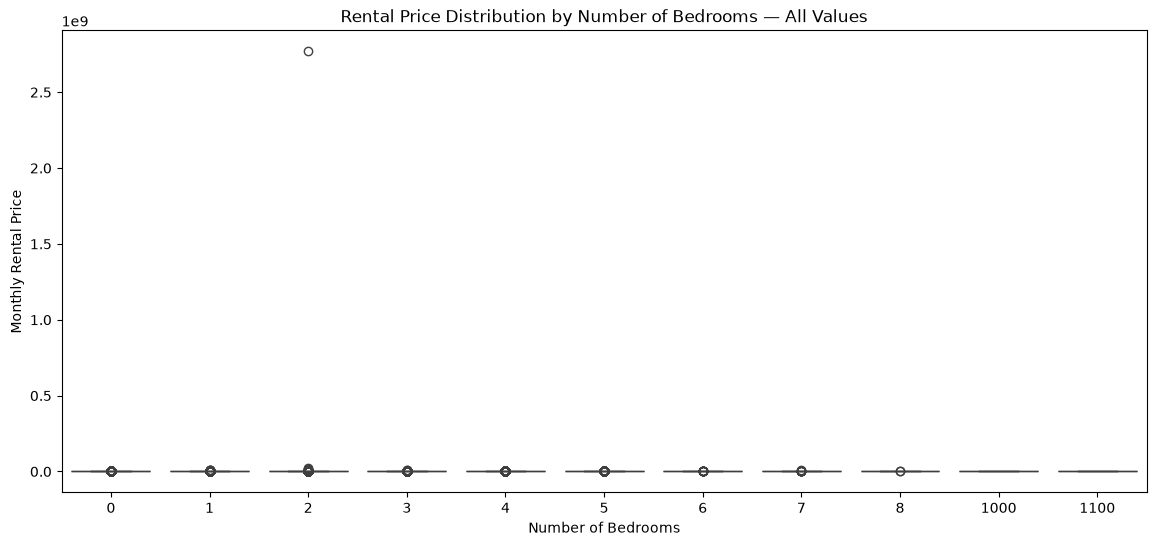

In [82]:
# Create a boxplot using all recorded bedroom values.
# No filtering is applied to the beds variable so that extreme
# observations such as 1000 and 1100 bedrooms remain visible.
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="beds",
    y="price"
)

plt.title("Rental Price Distribution by Number of Bedrooms — All Values")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Monthly Rental Price")
plt.show()

#### 7.2.4 Focused Rental Price Distribution by Number of Bedrooms

The previous visualization shows that extreme rental prices and unusual
bedroom values strongly compress the normal distributions.

Therefore, a focused visualization is created using bedroom values from
0 to 8 and rental prices up to the 99th percentile. This filtering is
used only for visualization so that the typical rental-price distributions
across bedroom categories can be compared more clearly.

The extreme observations are not removed from the original dataset by
this visualization.

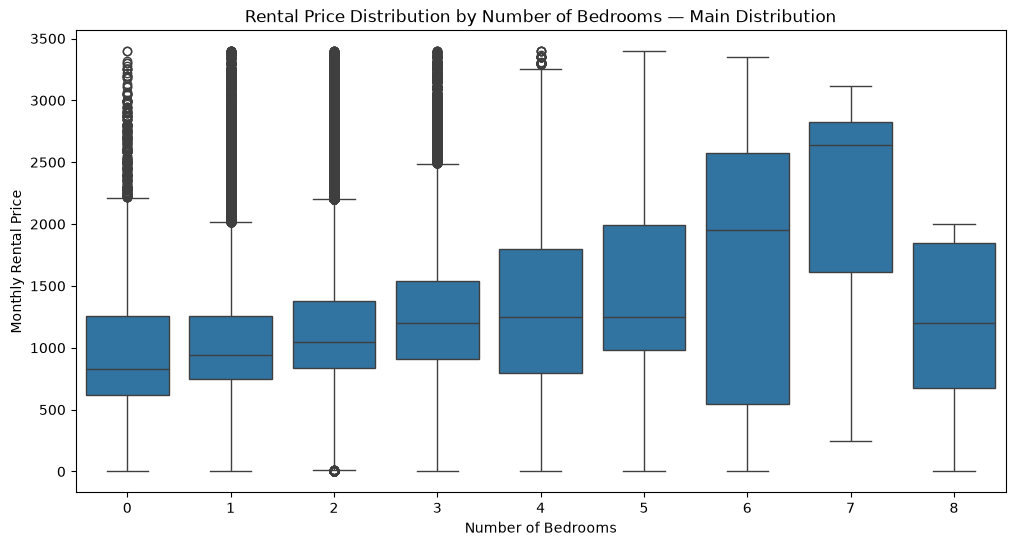

In [83]:
# Calculate the 99th percentile of rental price.
# This value is used only to improve visualization readability.
price_99 = df["price"].quantile(0.99)

# Select the normal bedroom range and rental prices up to the
# 99th percentile for visualization.
# The original dataframe is not modified.
beds_price_main = df.loc[
    df["beds"].between(0, 8) &
    (df["price"] <= price_99),
    ["beds", "price"]
].copy()

# Create a boxplot to compare rental-price distributions
# across the normal bedroom categories.
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=beds_price_main,
    x="beds",
    y="price"
)

plt.title("Rental Price Distribution by Number of Bedrooms — Main Distribution")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Monthly Rental Price")
plt.show()

#### Interpretation

The focused boxplot shows a general upward tendency in rental prices as
the number of bedrooms increases, particularly from 0 to 7 bedrooms.

The median rental price generally increases from properties with fewer
bedrooms to properties with more bedrooms. However, substantial variation
exists within each bedroom category, indicating that bedroom count alone
does not explain rental price.

Several categories also contain numerous higher-price observations,
showing that properties with the same number of bedrooms can have
substantially different rental prices.

The 8-bedroom category should be interpreted cautiously because it
contains relatively few observations compared with the more common
bedroom categories.

Overall, the visualization is consistent with the weak positive Spearman
correlation of 0.2050.

#### Finding — Price vs Number of Bedrooms

The analysis identifies a weak positive monotonic relationship between
rental price and the number of bedrooms, with a Spearman correlation of
0.2050.

The focused boxplot shows that median rental prices generally increase
with bedroom count, although substantial variation exists within each
category.

The relationship is therefore weaker than the relationship observed
between price and square footage. Nevertheless, `beds` provides useful
information about rental price and will be retained as a candidate
predictive feature.

The extreme bedroom values of 1,000 and 1,100 identified during the
earlier data-quality analysis should be treated separately during
preprocessing rather than being considered representative bedroom
categories.

### 7.3 Rental Price vs Number of Bathrooms

The relationship between rental price and the number of bathrooms is
examined to determine whether properties with more bathrooms tend to have
higher rental prices.

The `baths` feature is treated as a numerical variable because it contains
both whole and fractional values, such as 1.5 and 2.5 bathrooms.

#### 7.3.1 Pearson Correlation — Price vs Bathrooms

Pearson correlation is calculated to measure the strength and direction
of the linear relationship between rental price and the number of
bathrooms.

In [84]:
# Calculate the Pearson correlation between rental price
# and the number of bathrooms.
# This provides an initial measure of their linear relationship.
price_baths_pearson = df["price"].corr(df["baths"])

print(f"Pearson correlation: {price_baths_pearson:.8f}")

Pearson correlation: 0.00015269


#### 7.3.2 Spearman Correlation — Price vs Bathrooms

Because the raw data contains extreme bathroom values, Spearman rank
correlation is also calculated.

This helps determine whether rental price generally tends to increase or
decrease as the number of bathrooms increases without relying only on a
strict linear relationship.

In [86]:
# Calculate the Spearman rank correlation between rental price
# and the number of bathrooms.
# Spearman correlation helps examine the general monotonic relationship
# while using the ranked values of the observations.
price_baths_spearman = df["price"].corr(
    df["baths"],
    method="spearman"
)

print(f"Spearman correlation: {price_baths_spearman:.4f}")

Spearman correlation: 0.2965


#### Interpretation

The Spearman correlation between rental price and the number of bathrooms
is 0.2965, indicating a weak-to-moderate positive monotonic relationship.

This suggests that rental prices generally tend to increase as the number
of bathrooms increases. However, substantial variation in rental prices
can still occur among properties with similar numbers of bathrooms.

The difference between the near-zero Pearson correlation and the higher
Spearman correlation indicates that the extreme observations in the raw
dataset have a substantial influence on the linear relationship.

Therefore, `baths` remains a potentially useful predictive feature, but
its relationship with rental price should be considered together with
other property, geographic, and categorical features.

#### 7.3.3 Rental Price Distribution by Number of Bathrooms

The distribution of rental prices is compared across different bathroom
counts to examine how rental prices vary between properties with different
numbers of bathrooms.

The visualization initially includes all recorded bathroom values so that
the previously identified extreme bathroom observations can be observed.

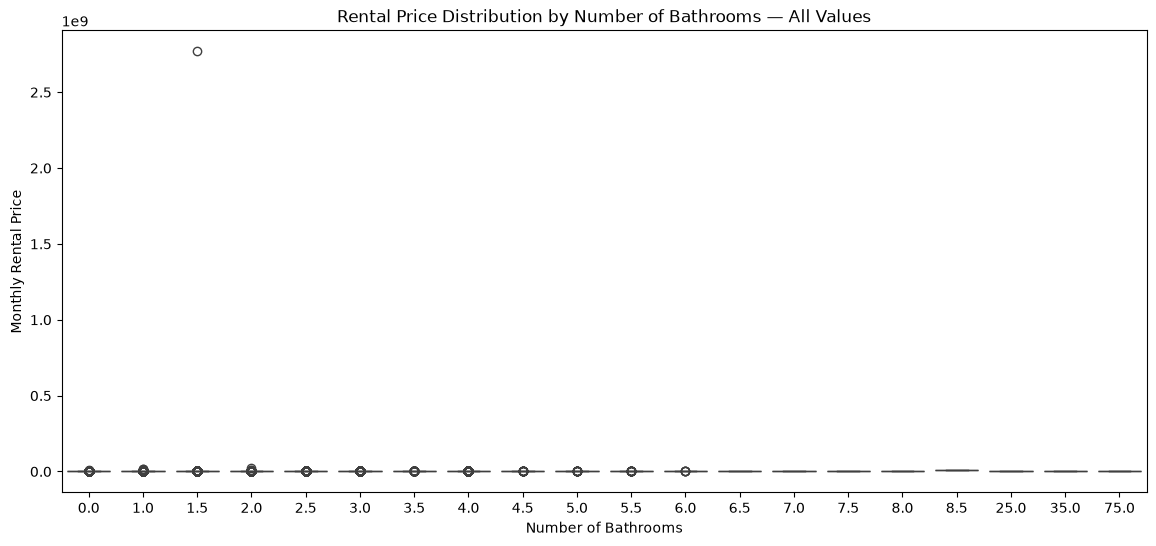

In [89]:
# Create a boxplot using all recorded bathroom values.
# No filtering is applied so that unusual bathroom observations
# identified during the earlier data-quality analysis remain visible.
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="baths",
    y="price"
)

plt.title("Rental Price Distribution by Number of Bathrooms — All Values")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Monthly Rental Price")
plt.show()

#### 7.3.4 Focused Rental Price Distribution by Number of Bathrooms

The previous visualization shows that extreme rental prices and unusual
bathroom values strongly compress the normal distributions.

Therefore, a focused visualization is created using bathroom values up to
8.5 and rental prices up to the 99th percentile. The value 8.5 is retained
because it was observed as a valid fractional bathroom value in the
dataset.

This filtering is used only for visualization and does not remove
observations from the original dataset.

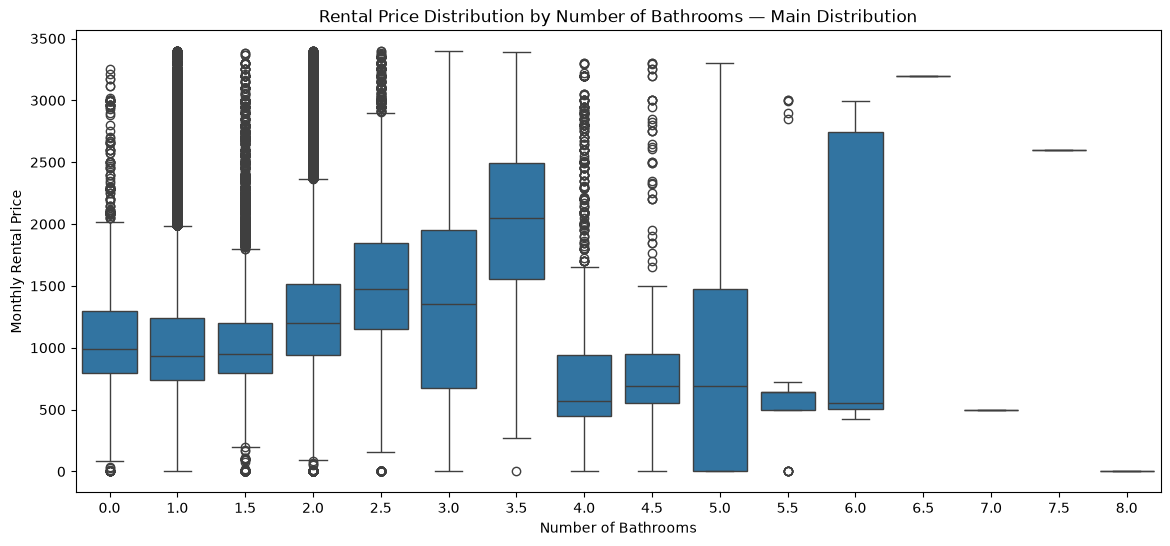

In [90]:
# Calculate the 99th percentile of rental price.
# This value is used only to improve visualization readability.
price_99 = df["price"].quantile(0.99)

# Keep bathroom values up to 8.5 and rental prices up to
# the 99th percentile for visualization.
# The original dataframe is not modified.
baths_price_main = df.loc[
    df["baths"].between(0, 8.5) &
    (df["price"] <= price_99),
    ["baths", "price"]
].copy()

# Create a boxplot to compare rental-price distributions
# across the observed bathroom categories.
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=baths_price_main,
    x="baths",
    y="price"
)

plt.title("Rental Price Distribution by Number of Bathrooms — Main Distribution")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Monthly Rental Price")
plt.show()

#### Interpretation

The focused boxplot shows a general tendency for rental prices to increase
as the number of bathrooms increases, particularly across the more common
bathroom categories from approximately 1 to 3.5 bathrooms.

However, the relationship is not strictly increasing across all bathroom
categories. Some categories show substantial variation in rental prices,
and the higher bathroom categories contain fewer observations, resulting
in less stable distributions.

The substantial spread within several categories indicates that bathroom
count alone cannot explain rental price. Other factors such as property
size, location, property type, and bedrooms are also likely to contribute
to rental price variation.

Overall, the visualization is consistent with the Spearman correlation
of 0.2965, which indicates a weak-to-moderate positive monotonic
relationship.

#### Finding — Price vs Number of Bathrooms

The analysis identifies a weak-to-moderate positive monotonic relationship
between rental price and the number of bathrooms, with a Spearman
correlation of 0.2965.

The focused boxplot shows that rental prices generally tend to be higher
for properties with more bathrooms, particularly among the common
bathroom categories. However, substantial variation exists within
individual categories, and the relationship is not strictly increasing
across all bathroom values.

Therefore, `baths` provides potentially useful information for predicting
rental price but should be considered together with other property,
geographic, and categorical features.

The extreme bathroom values of 25, 35, and 75 identified during the
earlier data-quality analysis are not representative of the normal
bathroom distribution and will require separate treatment during
preprocessing.

### 7.4 Rental Price vs Property Type

The relationship between rental price and property type is examined to
determine whether different types of residential properties have different
rental-price distributions.

The `type` feature is categorical, while `price` is a numerical target.
Therefore, the rental-price distributions can be compared across property
types using grouped visualizations.

This analysis helps determine whether property type provides useful
information for predicting rental price.

#### 7.4.1 Rental Price Distribution by Property Type

A boxplot is used to compare the distribution of rental prices across the
different property types.

The raw data is initially visualized so that the effect of extreme rental
prices can be observed before creating a focused visualization.

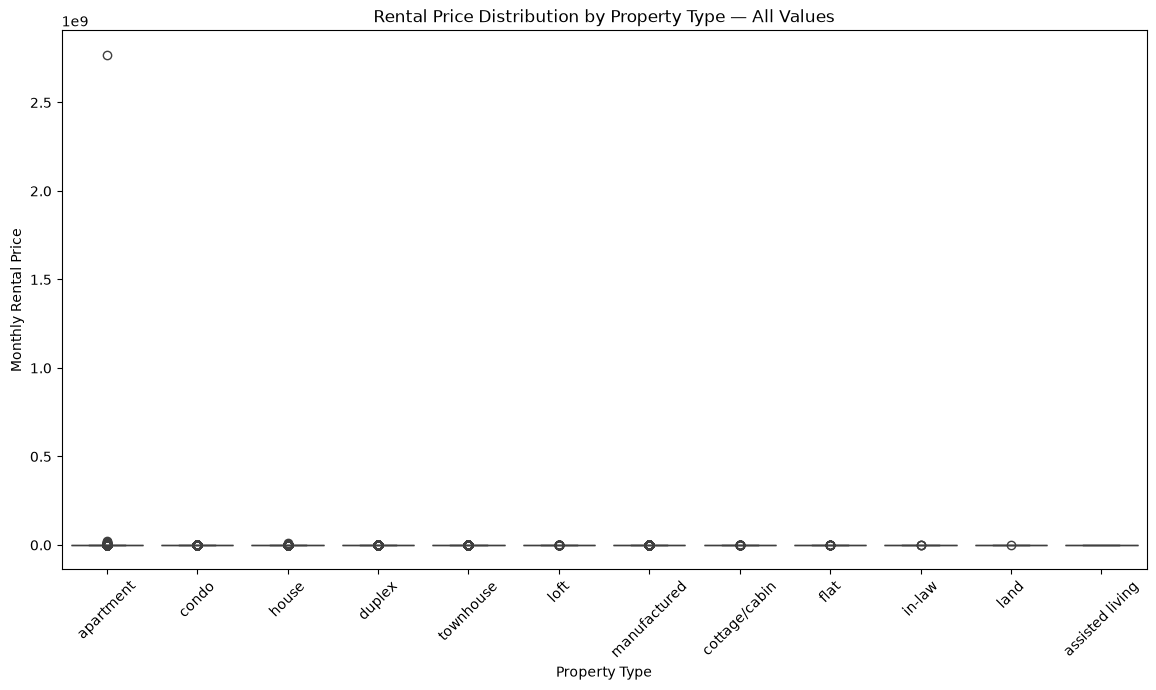

In [92]:
# Create a boxplot to compare rental-price distributions
# across the different property types.
# All observations are initially included so that extreme
# rental-price values remain visible.
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="type",
    y="price"
)

plt.title("Rental Price Distribution by Property Type — All Values")
plt.xlabel("Property Type")
plt.ylabel("Monthly Rental Price")
plt.xticks(rotation=45)

plt.show()

#### 7.4.2 Focused Rental Price Distribution by Property Type

The previous boxplot is strongly affected by extreme rental-price
observations, making it difficult to compare the normal price distributions
across property types.

Therefore, a focused boxplot is created using rental prices up to the
99th percentile.

This filtering is used only to improve visualization and does not remove
the extreme observations from the original dataset.

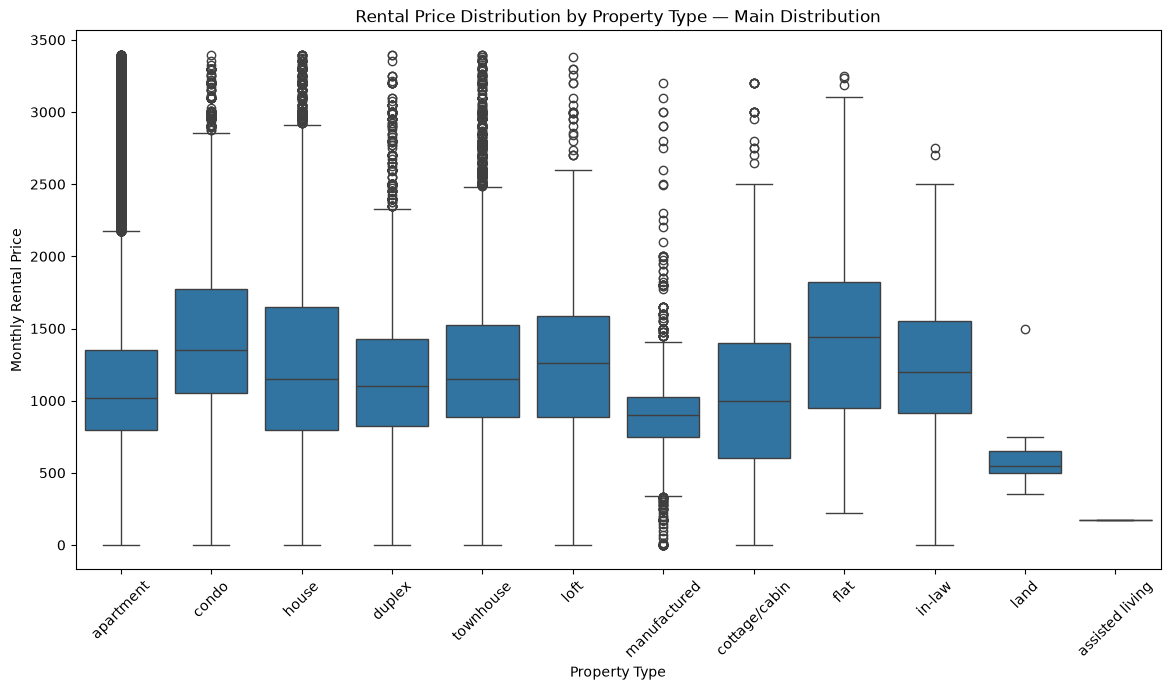

In [93]:
# Calculate the 99th percentile of rental price.
# This value is used only to improve visualization readability.
price_99 = df["price"].quantile(0.99)

# Select observations with rental prices up to the 99th percentile.
# The original dataframe is not modified.
type_price_main = df.loc[
    df["price"] <= price_99,
    ["type", "price"]
].copy()

# Create a boxplot to compare rental-price distributions
# across the different property types.
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=type_price_main,
    x="type",
    y="price"
)

plt.title("Rental Price Distribution by Property Type — Main Distribution")
plt.xlabel("Property Type")
plt.ylabel("Monthly Rental Price")
plt.xticks(rotation=45)

plt.show()

#### Interpretation

The focused boxplot shows that rental-price distributions vary across
property types.

Several property types have different median rental prices and different
amounts of variation. For example, condos, flats, and some other property
types show higher median prices than some of the more common property
categories, while manufactured properties show a lower central price
distribution.

The plot also shows substantial variation within several property types,
indicating that property type alone cannot explain rental price.

Some categories, such as `land` and `assisted living`, contain very few
observations compared with common categories such as `apartment`. Their
price distributions should therefore be interpreted cautiously.

Overall, the differences between property-type distributions suggest that
`type` contains potentially useful information for rental-price
prediction.

#### Finding — Price vs Property Type

The analysis shows that rental-price distributions differ across property
types.

The differences in median prices and the spread of rental prices indicate
that `type` may provide useful information for predicting rental price.
However, substantial variation remains within individual property types,
so property type alone cannot explain the target variable.

Rare categories such as `land` and `assisted living` contain relatively
few observations and should be considered carefully during categorical
encoding and model development.

Therefore, `type` will be retained as a candidate predictive feature.

### 7.5 Rental Price vs State

The relationship between rental price and state is examined to determine
whether rental-price distributions differ across geographic areas.

The `state` feature contains 51 categories, while `price` is a numerical
target variable. Therefore, rental-price distributions will be compared
across states using grouped statistical summaries and visualizations.

This analysis helps determine whether state-level geographic information
provides useful information for rental-price prediction.

#### 7.5.1 Rental Price Summary by State

The median rental price is calculated for each state to compare the
central rental-price distribution across geographic areas.

The median is used because the rental-price variable is highly
right-skewed and contains extreme values, which can substantially affect
the mean.

In [94]:
# Calculate the median rental price for each state.
# The median is used because it is less affected by extreme
# rental-price observations than the mean.
state_price_median = (
    df.groupby("state")["price"]
    .median()
    .sort_values(ascending=False)
)

state_price_median

state
hi    1875.0
dc    1725.0
ca    1700.0
ma    1700.0
nj    1646.0
nh    1610.0
ri    1550.0
vt    1450.0
co    1429.0
wa    1375.0
md    1361.0
me    1360.0
ct    1286.0
or    1280.0
de    1234.0
ut    1169.0
fl    1159.0
pa    1149.0
va    1149.0
mn    1134.5
nv    1125.0
ny    1101.0
wv    1100.0
id    1075.0
ak    1070.0
sc    1011.0
mt    1000.0
wi     990.0
az     977.0
mi     949.0
nc     945.0
ne     930.0
nd     925.0
ga     903.0
tx     903.0
tn     899.0
la     875.0
ia     873.0
wy     864.0
al     850.0
il     830.0
nm     829.0
in     824.0
ar     820.0
oh     820.0
ky     809.0
sd     800.0
ms     775.0
mo     700.0
ok     700.0
ks     695.0
Name: price, dtype: float64

**Interpretation:**

The median rental price varies across states, indicating differences in
the typical advertised rental prices across geographic areas.

Hawaii (HI) has the highest median rental price at approximately $1,875,
followed by Washington, D.C. (DC) at $1,725 and California (CA) and
Massachusetts (MA) at $1,700.

At the lower end, Kansas (KS) has a median rental price of approximately
$695, while Missouri (MO) and Oklahoma (OK) have medians of approximately
$700.

These differences suggest that `state` contains potentially useful
geographic information for predicting rental prices. However, this
analysis shows association rather than causation.

#### 7.5.2 Visualizing Rental Price by State

A boxplot is used to compare the distribution of rental prices across
states.

The states are ordered according to their median rental price so that
differences in the central tendency and overall price distributions can
be compared more easily.

Because rental price contains extreme values, the boxplot also helps
visualize the spread and potential outliers within each state.

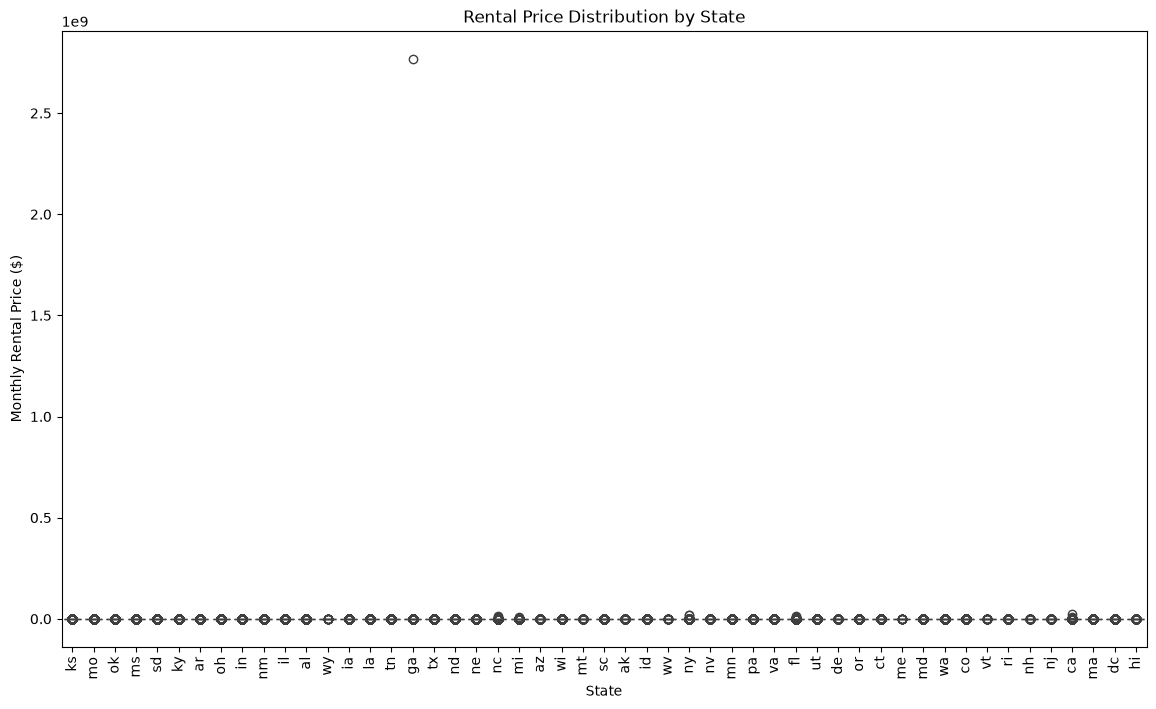

In [95]:
# Sort states by their median rental price.
# This places states from lower to higher typical rental prices.

state_order = (
    df.groupby("state")["price"]
    .median()
    .sort_values()
    .index
)

# Create a boxplot to compare rental-price distributions across states.

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df,
    x="state",
    y="price",
    order=state_order
)

plt.title("Rental Price Distribution by State")
plt.xlabel("State")
plt.ylabel("Monthly Rental Price ($)")
plt.xticks(rotation=90)

plt.show()

#### 7.5.3 Focused State-Level Price Comparison

The previous boxplot is strongly affected by extreme rental-price values,
which compress the majority of observations near the bottom of the plot.

To improve visualization, a focused boxplot is created using rental prices
up to the 99th percentile ($3,395). This filtering is applied only for
visualization and does not remove observations from the dataset.

The focused plot allows the typical rental-price distributions across
states to be compared more clearly.


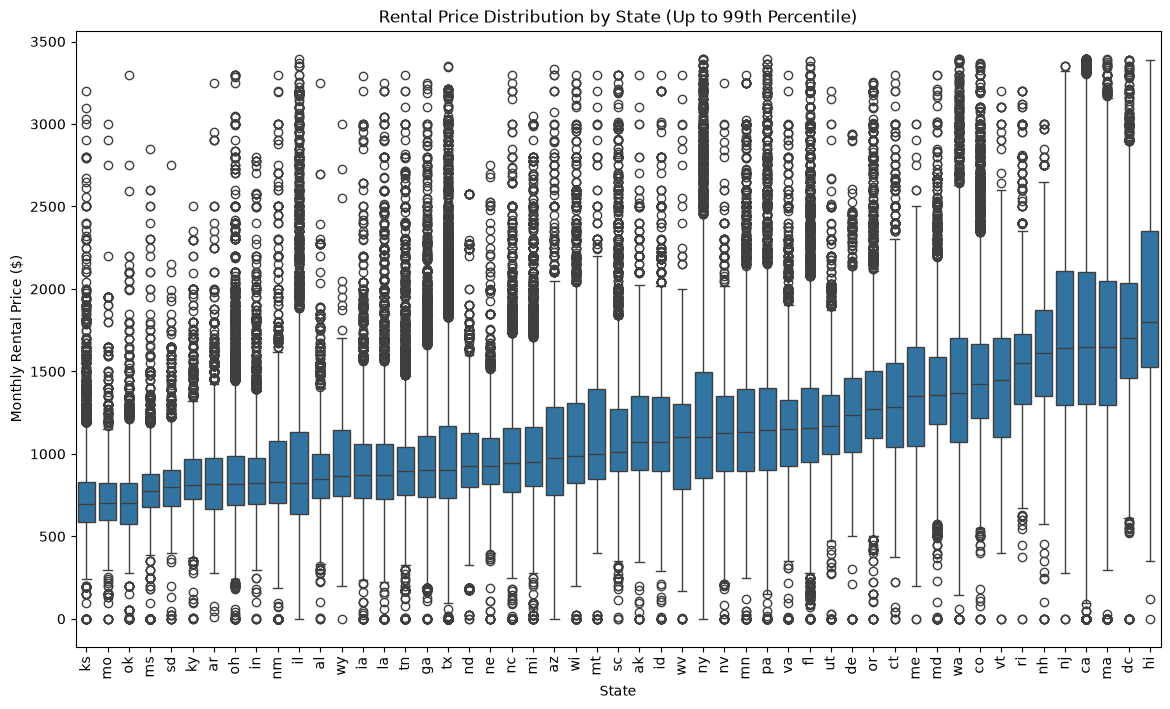

In [97]:
# Calculate the 99th percentile of rental price.
# This threshold is used only to improve visualization.

price_99 = df["price"].quantile(0.99)

# Create a visualization-only dataset containing prices
# up to the 99th percentile.

state_price_focused = df[df["price"] <= price_99]

# Keep the states ordered according to their median rental price
# calculated from the original dataset.

state_order = (
    df.groupby("state")["price"]
    .median()
    .sort_values()
    .index
)

# Create the focused boxplot.

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=state_price_focused,
    x="state",
    y="price",
    order=state_order
)

plt.title("Rental Price Distribution by State (Up to 99th Percentile)")
plt.xlabel("State")
plt.ylabel("Monthly Rental Price ($)")
plt.xticks(rotation=90)

plt.show()

**Interpretation:**

The focused boxplot shows noticeable differences in rental-price
distributions across states.

The median rental price generally increases across the ordered states,
with lower median values observed in states such as Kansas and higher
median values observed in states such as California, Massachusetts,
Washington, D.C., and Hawaii.

However, there is considerable overlap between the price distributions
of different states, indicating that state alone does not determine
rental price.

The distributions also show different levels of variability across
states. Several states contain observations outside the boxplot
whiskers, representing potential statistical outliers within those
state-level distributions. These observations are not automatically
considered invalid and require separate data-quality investigation.

The focused visualization uses the 99th percentile only for
visualization purposes and does not remove observations from the
dataset.

**Finding:**

Rental-price distributions differ across states, with noticeable
differences in their median prices and variability. This indicates that
`state` contains potentially useful geographic information for rental
price prediction.

However, substantial overlap between states shows that state-level
information alone is not sufficient to explain rental-price variation.
Therefore, `state` will be retained as a candidate predictive feature
and evaluated together with other property and geographic features.

### 7.6 Rental Price vs Region

The relationship between rental price and region is examined to determine
whether rental-price distributions differ across geographic areas at a
more detailed level than state.

The `region` feature contains 404 categories, making it a high-cardinality
categorical variable. Therefore, rental-price distributions will first be
summarized using median rental prices by region before selecting a
manageable subset for visualization.

This analysis helps determine whether region-level geographic information
provides potentially useful information for rental-price prediction.

#### 7.6.1 Rental Price Summary by Region

The median rental price is calculated for each region to compare the
typical rental-price levels across geographic areas.

The median is used because rental price is highly right-skewed and
contains extreme values that can strongly affect the mean.

In [99]:
# Calculate the median rental price for each region.
# The median is less affected by extreme rental-price values
# than the mean.

region_price_median = (
    df.groupby("region")["price"]
    .median()
    .sort_values(ascending=False)
)

region_price_median

region
santa barbara             3000.0
SF bay area               2748.0
florida keys              2470.0
new york city             2400.0
long island               2400.0
                           ...  
stillwater                 527.0
southeast KS               500.0
fort smith, AR             450.0
southwest KS               435.0
potsdam-canton-massena     299.0
Name: price, Length: 404, dtype: float64

#### 7.6.2 Most Represented Regions

The `region` feature contains 404 distinct categories with different
numbers of listings in each region.

To create an interpretable visualization, the most frequently occurring
regions are identified first. This allows the rental-price distributions
of well-represented regions to be compared without producing an
overcrowded visualization containing all 404 categories.

In [101]:
# Count the number of listings in each region.
# This helps identify regions with a large number of observations.

region_counts = (
    df["region"]
    .value_counts()
)

# Display the 20 most frequently occurring regions.

region_counts.head(20)

region
jacksonville               4246
columbus                   3738
rochester                  3677
jackson                    3667
fayetteville               3652
fredericksburg             2747
omaha / council bluffs     2727
salt lake city             2719
denver                     2671
seattle-tacoma             2626
savannah / hinesville      2621
boulder                    2614
portland                   2596
ventura county             2579
stockton                   2571
fort collins / north CO    2567
orlando                    2564
inland empire              2561
charleston                 2559
lincoln                    2550
Name: count, dtype: int64

#### 7.6.3 Visualizing Rental Price Distribution for Major Regions

Since the dataset contains 404 regions, visualizing every region in a
single boxplot would make the comparison difficult to interpret.

Therefore, the 20 regions with the highest number of listings are used
for this visualization. These regions provide sufficient observations
for comparing their rental-price distributions.

The visualization focuses on rental prices up to the 99th percentile
($3,395) to reduce the influence of extreme values on the plot. This
filter is applied only for visualization and does not remove observations
from the original dataset.

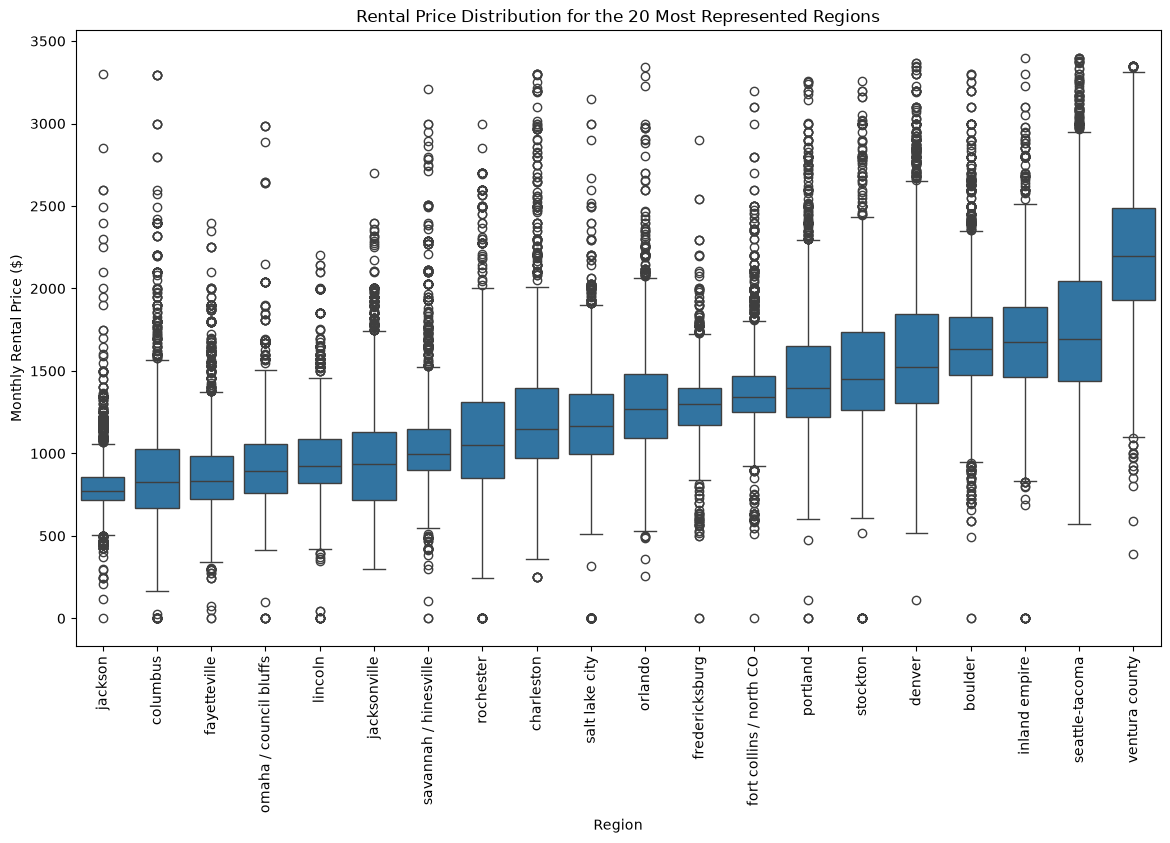

In [102]:
# Select the 20 regions with the largest number of listings.

top_regions = region_counts.head(20).index

# Calculate the 99th percentile of rental price.
# This threshold is used only to improve visualization.

price_99 = df["price"].quantile(0.99)

# Create a visualization-only dataset containing:
# 1. The top 20 most represented regions
# 2. Rental prices up to the 99th percentile

region_price_focused = df[
    (df["region"].isin(top_regions)) &
    (df["price"] <= price_99)
]

# Order the regions by their median rental price
# within the selected top 20 regions.

region_order = (
    region_price_focused.groupby("region")["price"]
    .median()
    .sort_values()
    .index
)

# Create the boxplot.

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=region_price_focused,
    x="region",
    y="price",
    order=region_order
)

plt.title("Rental Price Distribution for the 20 Most Represented Regions")
plt.xlabel("Region")
plt.ylabel("Monthly Rental Price ($)")
plt.xticks(rotation=90)

plt.show()

**Interpretation:**

The boxplot shows noticeable differences in rental-price distributions
among the 20 most represented regions.

Regions such as Jacksonville, Columbus, and Fayetteville have relatively
lower median rental prices, while regions such as Denver, Boulder,
Seattle-Tacoma, and Ventura County show higher median rental prices.

The distributions also show substantial variation within individual
regions, with many observations extending beyond the boxplot whiskers.

These differences indicate that `region` provides potentially useful
geographic information for rental-price prediction. However, the
variation within regions shows that regional information alone cannot
fully explain rental-price differences.

The 99th-percentile price threshold was used only to improve
visualization and does not represent removal of observations from the
dataset.

**Finding:**

Rental-price distributions vary across geographic regions, with clear
differences in median prices and within-region variability.

Compared with state-level analysis, the more detailed `region` feature
shows additional geographic variation in rental prices. Therefore,
`region` will be retained as a candidate predictive feature, while its
high cardinality of 404 categories will be considered during
preprocessing and feature encoding.

### 7.7 Rental Price vs Property Amenities

The relationship between rental price and property amenities is examined
using the `laundry_options` and `parking_options` features.

Both features contain categorical information about property amenities
and also contain missing values. Missing values are not automatically
interpreted as the absence of an amenity because the dataset contains
explicit categories such as `no laundry on site` and `no parking`.

Therefore, laundry and parking options are analyzed separately to
determine whether rental-price distributions differ across their
respective categories.

#### 7.7.1 Rental Price vs Laundry Options

The relationship between rental price and `laundry_options` is examined
to determine whether rental-price distributions differ according to the
available laundry facilities.

The `laundry_options` feature contains several observed categories as
well as missing values. Missing values are kept separate from explicit
categories because a missing value does not necessarily mean that the
property has no laundry facility.

#### 7.7.1.1 Rental Price Summary by Laundry Option

The median rental price is calculated for each laundry category to
compare the typical rental-price level across different laundry options.

The median is used because rental price is highly right-skewed and
contains extreme values that can strongly affect the mean.

Missing laundry values are treated as a separate group for this
descriptive analysis.

In [104]:
# Calculate the median rental price for each laundry category.
# dropna=False keeps missing laundry values as a separate group.
# The median is used because it is less affected by extreme
# rental-price values than the mean.

laundry_price_median = (
    df.groupby("laundry_options", dropna=False)["price"]
    .median()
    .sort_values(ascending=False)
)

laundry_price_median

laundry_options
w/d in unit           1297.0
NaN                   1005.0
w/d hookups            965.0
laundry in bldg        898.0
laundry on site        841.0
no laundry on site     825.0
Name: price, dtype: float64

#### 7.7.1.2 Rental Price Distribution by Laundry Option

A boxplot is used to compare the distribution of rental prices across
laundry categories.

The missing category is included separately so that its rental-price
distribution can be compared with the explicitly reported laundry
options.

Because rental price contains extreme values, the visualization will
also use the 99th percentile as a visualization threshold. This does
not remove observations from the original dataset.

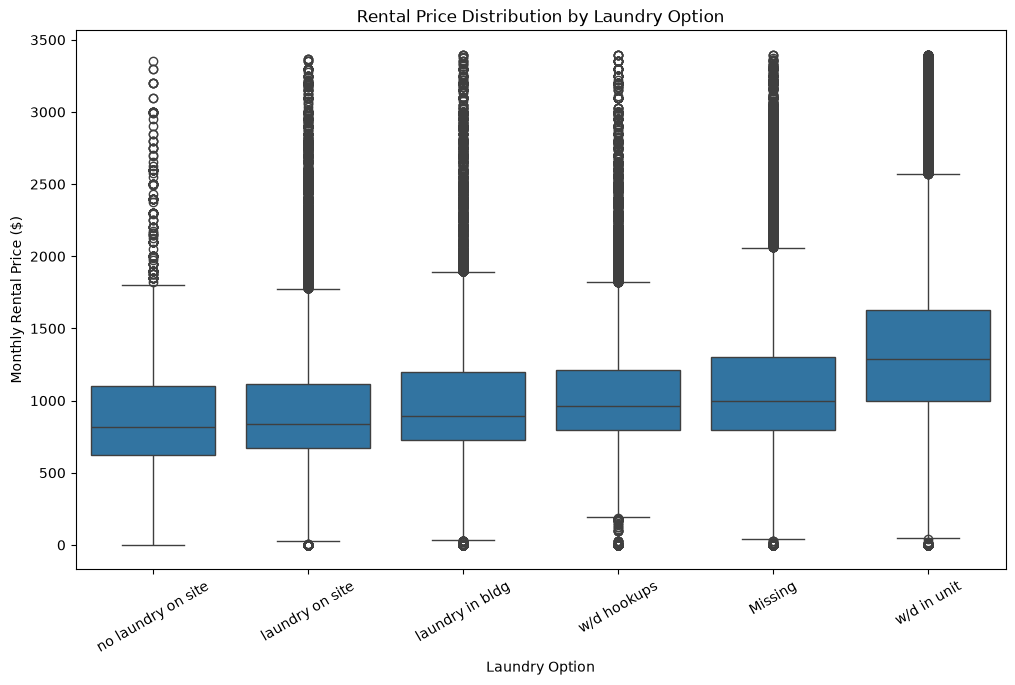

In [105]:
# Calculate the 99th percentile of rental price.
# This threshold is used only to make the visualization easier to read.

price_99 = df["price"].quantile(0.99)

# Create a visualization-only dataset.
# Missing laundry values are kept in the dataset.

laundry_price_focused = df[df["price"] <= price_99].copy()

# Create a label for missing laundry values so that
# they appear as a separate category in the boxplot.

laundry_price_focused["laundry_group"] = (
    laundry_price_focused["laundry_options"]
    .fillna("Missing")
)

# Order the categories according to their median rental price.

laundry_order = (
    laundry_price_focused.groupby("laundry_group")["price"]
    .median()
    .sort_values()
    .index
)

# Create the boxplot.

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=laundry_price_focused,
    x="laundry_group",
    y="price",
    order=laundry_order
)

plt.title("Rental Price Distribution by Laundry Option")
plt.xlabel("Laundry Option")
plt.ylabel("Monthly Rental Price ($)")
plt.xticks(rotation=30)

plt.show()

**Interpretation:**

The boxplot shows differences in rental-price distributions across
laundry categories.

Properties with `w/d in unit` have the highest median rental price at
approximately $1,297, while properties with `no laundry on site` have
the lowest median at approximately $825.

The missing-value group has a median rental price of approximately
$1,005, which differs from the explicit `no laundry on site` category.
This indicates that missing laundry information should not automatically
be interpreted as the absence of laundry facilities.

The distributions also contain numerous observations beyond the
boxplot whiskers, indicating potential statistical outliers. These
observations are not automatically considered invalid and require
separate data-quality treatment.

The 99th-percentile threshold was applied only for visualization and
does not remove observations from the original dataset.

**Finding:**

Rental-price distributions differ across laundry-option categories,
with `w/d in unit` showing the highest median rental price among the
observed groups.

The analysis also shows that missing laundry information has a different
price distribution from the explicit `no laundry on site` category.
Therefore, missing values should be handled separately during
preprocessing rather than being automatically interpreted as absence of
the amenity.

`laundry_options` will be retained as a candidate predictive feature.

#### 7.7.2 Rental Price vs Parking Options

The relationship between rental price and `parking_options` is examined
to determine whether rental-price distributions differ according to the
available parking facilities.

The `parking_options` feature contains several observed categories as
well as missing values. Missing values are kept separate from explicit
parking categories because a missing value does not necessarily mean
that the property has no parking.

#### 7.7.2.1 Rental Price Summary by Parking Option

The median rental price is calculated for each parking category to
compare the typical rental-price level across different parking options.

The median is used because rental price is highly right-skewed and
contains extreme values that can strongly affect the mean.

Missing parking values are treated as a separate group for this
descriptive analysis.

In [106]:
# Calculate the median rental price for each parking category.
# dropna=False keeps missing parking values as a separate group.
# The median is used because it is less affected by extreme
# rental-price values than the mean.

parking_price_median = (
    df.groupby("parking_options", dropna=False)["price"]
    .median()
    .sort_values(ascending=False)
)

parking_price_median

parking_options
valet parking         1850.0
attached garage       1500.0
detached garage       1193.5
carport               1159.0
no parking            1075.0
street parking        1020.0
NaN                   1015.0
off-street parking     935.0
Name: price, dtype: float64

#### 7.7.2.2 Rental Price Distribution by Parking Option

A boxplot is used to compare the distribution of rental prices across
parking categories.

The missing category is included separately so that its rental-price
distribution can be compared with the explicitly reported parking
options.

Because rental price contains extreme values, the 99th percentile is
used as a visualization threshold. This filtering is applied only for
visualization and does not remove observations from the original
dataset.

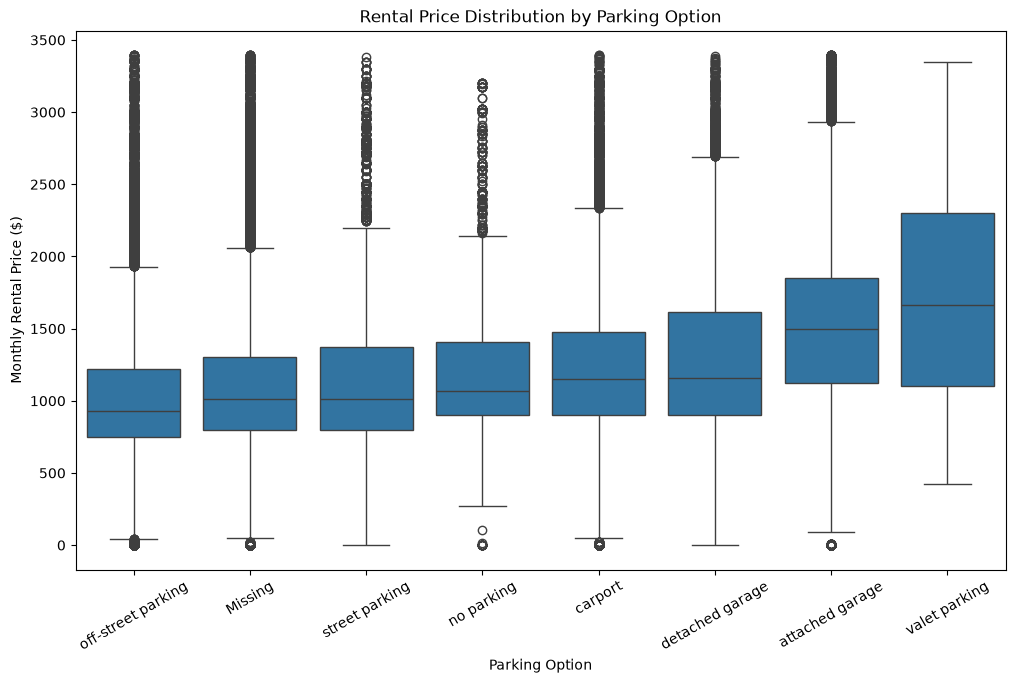

In [108]:
# Calculate the 99th percentile of rental price.
# This threshold is used only to make the visualization easier to read.

price_99 = df["price"].quantile(0.99)

# Create a visualization-only dataset.
# Missing parking values are kept in the dataset.

parking_price_focused = df[df["price"] <= price_99].copy()

# Create a separate label for missing parking values
# so they can be displayed as their own category.

parking_price_focused["parking_group"] = (
    parking_price_focused["parking_options"]
    .fillna("Missing")
)

# Order the parking categories according to their
# median rental price.

parking_order = (
    parking_price_focused.groupby("parking_group")["price"]
    .median()
    .sort_values()
    .index
)

# Create the boxplot.

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=parking_price_focused,
    x="parking_group",
    y="price",
    order=parking_order
)

plt.title("Rental Price Distribution by Parking Option")
plt.xlabel("Parking Option")
plt.ylabel("Monthly Rental Price ($)")
plt.xticks(rotation=30)

plt.show()

**Interpretation:**

The boxplot shows differences in rental-price distributions across
parking categories.

Properties with `valet parking` and `attached garage` have relatively
high median rental prices, while `off-street parking` has the lowest
median among the explicitly reported parking categories.

The `Missing` category has a different median rental price from the
explicit `no parking` category. This indicates that missing parking
information should not automatically be interpreted as the absence of
parking.

The `valet parking` category also shows a relatively wide distribution,
but it contains only a small number of listings compared with the other
parking categories. Therefore, conclusions about this category should
be interpreted cautiously.

Several potential statistical outliers are visible within the
categories. These observations are not automatically considered invalid
and require separate data-quality investigation.

The 99th-percentile price threshold was applied only for visualization
and does not remove observations from the original dataset.

**Finding:**

Rental-price distributions differ across parking-option categories,
indicating that `parking_options` may provide useful information for
rental-price prediction.

The analysis also shows that missing parking information has a different
price distribution from the explicit `no parking` category. Therefore,
missing values should be handled separately during preprocessing rather
than automatically being converted to an absence category.

`parking_options` will be retained as a candidate predictive feature,
while the rare `valet parking` category will be considered carefully
during feature encoding.

### 7.8 Rental Price vs Binary Amenities

The relationship between rental price and binary property-amenity
features is examined to determine whether rental-price distributions
differ between properties with and without each amenity.

The binary amenity features contain only two values, `0` and `1`, with no
missing or invalid values identified during the data-quality analysis.

For each feature, rental-price distributions will be compared between
the two groups using median rental prices and visualizations.

#### 7.8.1 Rental Price Summary by Binary Amenities

The median rental price is compared between the two groups of each binary
amenity feature.

A value of `0` represents the absence or non-availability of the
corresponding amenity, while a value of `1` represents its presence or
availability according to the dataset.

The median is used because rental price is highly right-skewed and
contains extreme values.

The six binary amenity features are analyzed together to identify
differences in typical rental prices without repeating the same analysis
separately for each feature.

In [109]:
# List of binary amenity features to analyze.
binary_amenities = [
    "cats_allowed",
    "dogs_allowed",
    "smoking_allowed",
    "wheelchair_access",
    "electric_vehicle_charge",
    "comes_furnished"
]

# Calculate the median rental price for each 0/1 group
# for every binary amenity feature.

binary_price_summary = {}

for feature in binary_amenities:
    binary_price_summary[feature] = (
        df.groupby(feature)["price"]
        .median()
    )

# Convert the results into a DataFrame for easier comparison.

binary_price_summary = pd.DataFrame(binary_price_summary)

binary_price_summary

,cats_allowed,dogs_allowed,smoking_allowed,wheelchair_access,electric_vehicle_charge,comes_furnished
0,1052.0,1050.0,1195.0,1028.0,1030.0,1040.0
1,1030.0,1031.0,999.0,1150.0,1650.0,995.0


**Interpretation:**

The median rental prices differ to varying degrees between the 0 and 1
groups of the binary amenity features.

The differences are relatively small for `cats_allowed`, `dogs_allowed`,
and `comes_furnished`. Larger differences are observed for
`smoking_allowed`, `wheelchair_access`, and particularly
`electric_vehicle_charge`.

The `electric_vehicle_charge` feature shows a median rental price of
approximately $1,650 for the 1 group compared with $1,030 for the 0
group. However, this feature is highly imbalanced, with substantially
fewer listings having electric-vehicle charging available. Therefore,
the difference should be interpreted cautiously.

These comparisons describe associations between amenities and rental
price and do not establish causal relationships.

#### 7.8.2 Visualizing Rental Price by Binary Amenities

A grouped bar chart is used to compare the median rental price between
the 0 and 1 groups for each binary amenity feature.

The chart provides a compact comparison of all six binary amenities and
helps identify which features show noticeable differences in median
rental price.

The visualization shows descriptive differences only and does not imply
that the amenities cause changes in rental price.

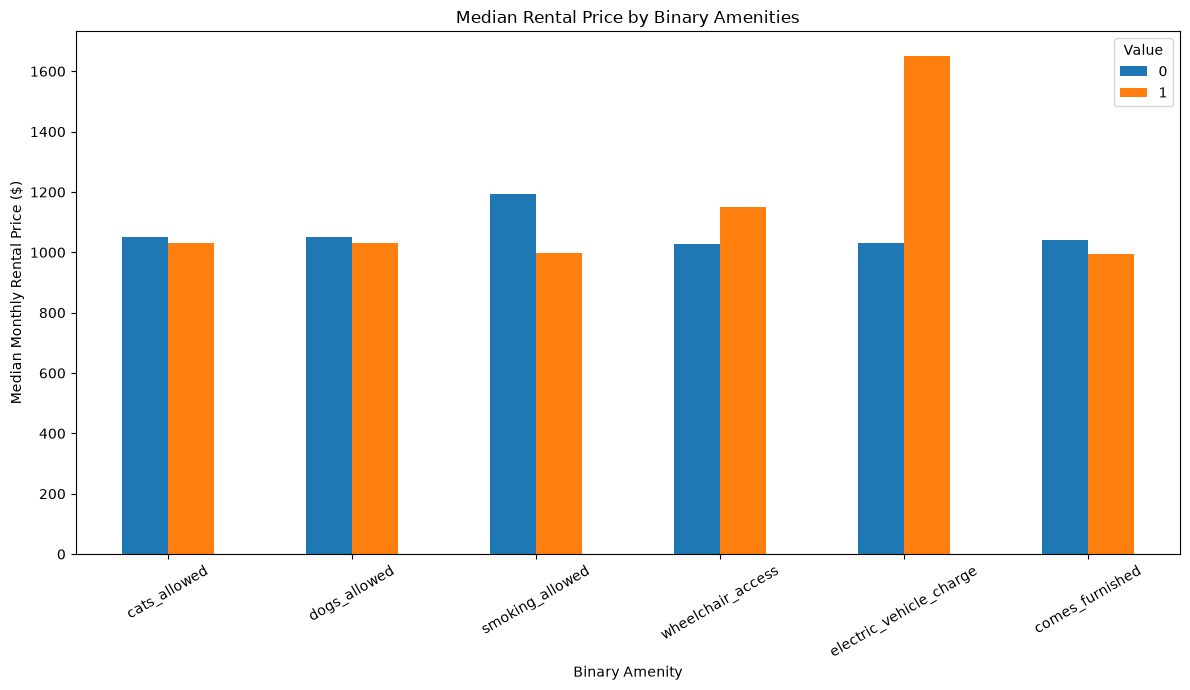

In [111]:
# Prepare the median-price summary for visualization.
# Transpose the table so that each amenity becomes a category
# on the x-axis.

binary_plot_data = binary_price_summary.T

# Create a grouped bar chart comparing the 0 and 1 groups.

binary_plot_data.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Median Rental Price by Binary Amenities")
plt.xlabel("Binary Amenity")
plt.ylabel("Median Monthly Rental Price ($)")
plt.xticks(rotation=30)
plt.legend(title="Value")

plt.tight_layout()
plt.show()

**Interpretation:**

The grouped bar chart shows that the median rental-price differences
vary across the six binary amenities.

`cats_allowed` and `dogs_allowed` show relatively small differences
between their 0 and 1 groups. `comes_furnished` also shows a relatively
small difference.

Larger differences are observed for `smoking_allowed`,
`wheelchair_access`, and `electric_vehicle_charge`. The largest median
difference is observed for `electric_vehicle_charge`, where the median
price is approximately $1,650 for the 1 group compared with $1,030 for
the 0 group.

These differences are descriptive associations and do not establish
that the presence or absence of an amenity causes a change in rental
price. The class frequencies of the binary features should also be
considered when interpreting these comparisons.

**Finding:**

The binary amenity analysis shows that some amenities have noticeably
different median rental prices between their 0 and 1 groups, while
others show relatively small differences.

These features will therefore be retained as candidate predictive
features. Their class frequencies and potential imbalance will be
considered during preprocessing and subsequent model evaluation.

## 8. Numerical Correlation Analysis

Correlation analysis is performed to examine the relationships among the
numerical variables in the dataset.

Pearson correlation is first used to measure the strength and direction
of linear relationships between numerical variables.

The analysis includes the target variable `price` together with numerical
predictor variables such as `sqfeet`, `beds`, `baths`, `lat`, and `long`.

The correlation results help identify potentially informative features
and possible redundancy among numerical predictors. Correlation does not
imply causation.

#### 8.1.1 Pearson Correlation Matrix

The Pearson correlation coefficient ranges from -1 to +1.

A value close to +1 indicates a strong positive linear relationship,
while a value close to -1 indicates a strong negative linear
relationship. A value close to 0 indicates little or no linear
relationship.

A correlation matrix is used to examine these relationships across all
selected numerical variables.

In [113]:
# Select the numerical variables relevant to the analysis.

numerical_columns = [
    "price",
    "sqfeet",
    "beds",
    "baths",
    "lat",
    "long"
]

# Calculate the Pearson correlation matrix.

pearson_corr = df[numerical_columns].corr(method="pearson")

pearson_corr

,price,sqfeet,beds,baths,lat,long
price,1.000000,0.000009,0.000062,0.000153,-0.001411,0.000766
sqfeet,0.000009,1.000000,0.003840,0.011193,0.006790,-0.002861
beds,0.000062,0.003840,1.000000,0.416422,0.008768,0.007637
baths,0.000153,0.011193,0.416422,1.000000,-0.078356,-0.005544
lat,-0.001411,0.006790,0.008768,-0.078356,1.000000,-0.124032
long,0.000766,-0.002861,0.007637,-0.005544,-0.124032,1.000000


**Interpretation:**

The Pearson correlation results show extremely weak linear correlations
between the raw rental price and the numerical predictor variables.

However, these results should be interpreted together with the earlier
Spearman correlation analysis. For example, `sqfeet`, `beds`, and `baths`
showed positive monotonic relationships with rental price under Spearman
correlation, while their raw Pearson correlations are close to zero.

This difference is consistent with the strong skewness and extreme
outliers identified in the rental-price distribution, which can strongly
influence Pearson correlation.

Among the predictor variables, `beds` and `baths` have the strongest
Pearson correlation at approximately 0.416, indicating a moderate
positive linear relationship. The remaining predictor-predictor
correlations are relatively weak.

Therefore, Pearson correlation alone should not be used to determine
the usefulness of numerical features for prediction.

#### 8.1.2 Pearson Correlation Heatmap

A heatmap is used to visualize the Pearson correlation matrix.

The color intensity and annotated correlation values make it easier to
identify stronger and weaker linear relationships among the numerical
variables.

The heatmap is used as a visual summary of the correlation matrix rather
than as evidence of causation.

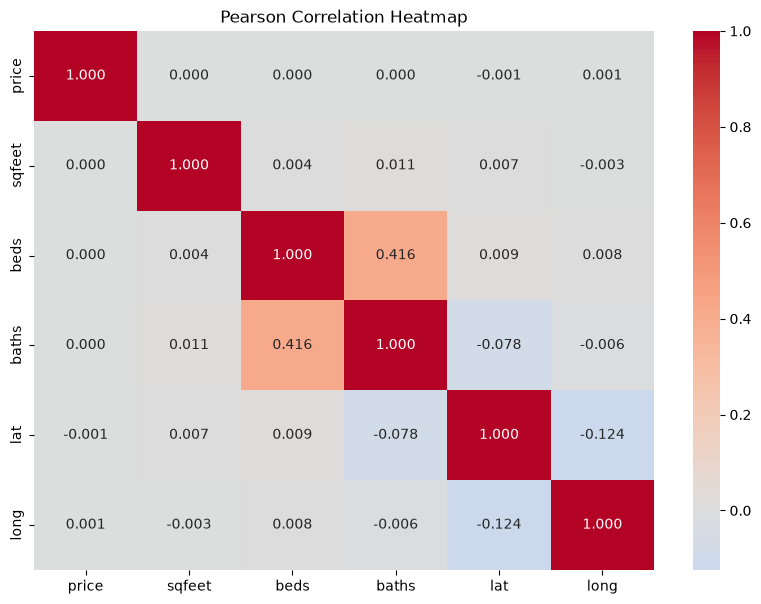

In [114]:
# Create a heatmap of the Pearson correlation matrix.

plt.figure(figsize=(10, 7))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Pearson Correlation Heatmap")
plt.show()

**Interpretation:**

The Pearson correlation heatmap confirms that most numerical variables
have weak linear relationships with the raw rental price.

The strongest relationship among the numerical predictor variables is
between `beds` and `baths`, with a Pearson correlation of approximately
0.416, indicating a moderate positive linear relationship.

The correlation between `lat` and `long` is approximately -0.124,
indicating a weak negative linear relationship.

The correlations between `price` and `sqfeet`, `beds`, and `baths` are
close to zero in the Pearson analysis. However, earlier Spearman
correlation analysis identified positive monotonic relationships between
these variables and rental price.

Therefore, the Pearson heatmap should be interpreted together with the
Spearman analysis and the earlier EDA findings rather than being used
alone to determine feature usefulness.

### 8.2 Spearman Correlation Analysis

Spearman correlation is used to examine monotonic relationships between
the numerical variables.

Unlike Pearson correlation, Spearman correlation is based on the ranked
values of the variables and is less sensitive to extreme values.

This is particularly relevant for the rental-price dataset because
`price` and several numerical variables contain strong skewness and
extreme observations.

The Spearman results will be compared with the Pearson results to
determine whether the apparent relationships change when the influence
of extreme values is reduced.

#### 8.2.1 Spearman Correlation Matrix

The Spearman correlation matrix is calculated using the same numerical
variables used in the Pearson analysis.

This allows the strength and direction of monotonic relationships to be
compared directly with the earlier Pearson results.

In [116]:
# Calculate the Spearman correlation matrix
# using the same numerical variables as the Pearson analysis.

spearman_corr = df[numerical_columns].corr(method="spearman")

spearman_corr

,price,sqfeet,beds,baths,lat,long
price,1.000000,0.361352,0.204995,0.296544,0.071321,-0.039771
sqfeet,0.361352,1.000000,0.800298,0.721033,0.020077,0.093401
beds,0.204995,0.800298,1.000000,0.664713,0.044503,0.029534
baths,0.296544,0.721033,0.664713,1.000000,-0.087177,-0.008438
lat,0.071321,0.020077,0.044503,-0.087177,1.000000,-0.013550
long,-0.039771,0.093401,0.029534,-0.008438,-0.013550,1.000000


**Interpretation:**

The Spearman correlation results reveal stronger monotonic relationships
between rental price and several property characteristics than were
observed using Pearson correlation.

`price` has a moderate positive monotonic relationship with `sqfeet`
(0.361), a weak positive relationship with `beds` (0.205), and a
weak-to-moderate positive relationship with `baths` (0.297).

In contrast, the relationships between rental price and the geographic
coordinates are weak, with correlations of 0.071 for `lat` and -0.040
for `long`.

Strong monotonic relationships are also observed among the property
characteristics themselves. The correlation between `sqfeet` and `beds`
is 0.800, between `sqfeet` and `baths` is 0.721, and between `beds` and
`baths` is 0.665. These relationships indicate potential redundancy
among property-size and room-count features.

The difference between the Pearson and Spearman results highlights the
importance of considering the strong skewness and extreme values in the
dataset when interpreting numerical relationships.

#### 8.2.3 Spearman Correlation Heatmap

A heatmap is used to visualize the Spearman correlation matrix and
provide a visual summary of the monotonic relationships among the
numerical variables.

The heatmap helps identify the relationships between rental price and
the numerical predictors, as well as potential redundancy among the
predictor variables.

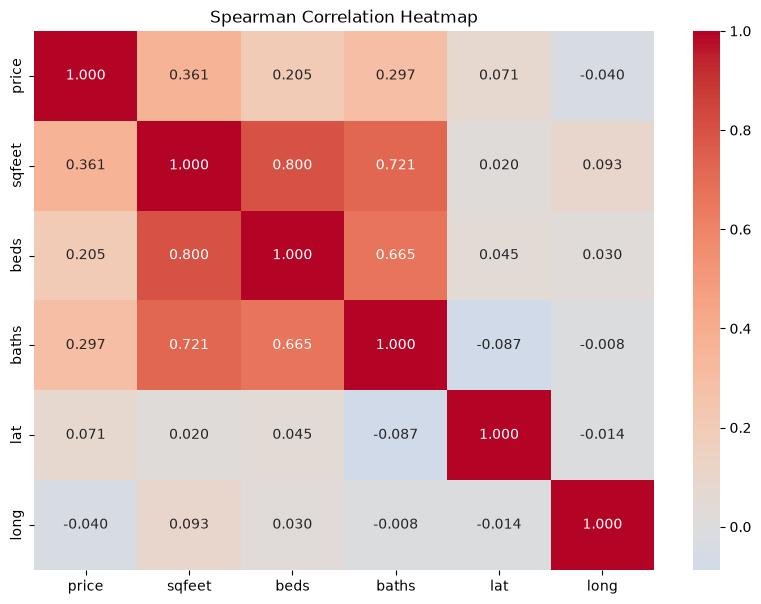

In [118]:
# Create a heatmap of the Spearman correlation matrix.

plt.figure(figsize=(10, 7))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Heatmap")
plt.show()

#### 8.3 Overall Correlation Findings

The Pearson and Spearman correlation analyses provide complementary
information about the numerical relationships in the dataset.

Pearson correlation produced correlations close to zero between the raw
rental price and the numerical property features. In contrast, Spearman
correlation identified positive monotonic relationships between rental
price and `sqfeet`, `beds`, and `baths`.

This difference is consistent with the strong skewness and extreme
values identified in the rental-price distribution.

Strong monotonic relationships were also observed among `sqfeet`,
`beds`, and `baths`, indicating that these features contain overlapping
information.

These findings will be considered during feature selection, but no
numerical feature will be removed based on correlation alone. Their
predictive usefulness and redundancy will be evaluated further during
the modeling stage.

#### 8.3 Overall Correlation Findings

The Pearson and Spearman correlation analyses provide complementary
information about the numerical relationships in the dataset.

Pearson correlation produced correlations close to zero between the raw
rental price and the numerical property features. In contrast, Spearman
correlation identified positive monotonic relationships between rental
price and `sqfeet`, `beds`, and `baths`.

This difference is consistent with the strong skewness and extreme
values identified in the rental-price distribution.

Strong monotonic relationships were also observed among `sqfeet`,
`beds`, and `baths`, indicating that these features contain overlapping
information.

These findings will be considered during feature selection, but no
numerical feature will be removed based on correlation alone. Their
predictive usefulness and redundancy will be evaluated further during
the modeling stage.

## 9. Geographic Price Patterns

Geographic analysis is performed to investigate how rental listings and
rental prices are distributed spatially across the dataset.

The dataset contains latitude and longitude coordinates for most
listings, allowing geographic patterns to be examined visually.

This analysis complements the earlier state, region, and correlation
analyses by examining the spatial distribution of rental listings
directly.

Only records with valid latitude and longitude values are considered
for geographic visualization.

#### 9.1 Spatial Distribution of Rental Price

The spatial relationship between rental price and geographic coordinates
is examined using latitude and longitude.

A geographic visualization is used to identify broad spatial patterns
in rental prices that may not be captured by examining latitude or
longitude individually.

Only listings with valid latitude and longitude values are included.
The 99th percentile of rental price is used only for visualization so
that extreme price observations do not dominate the spatial pattern.

This visualization does not remove extreme-price observations from the
original dataset.

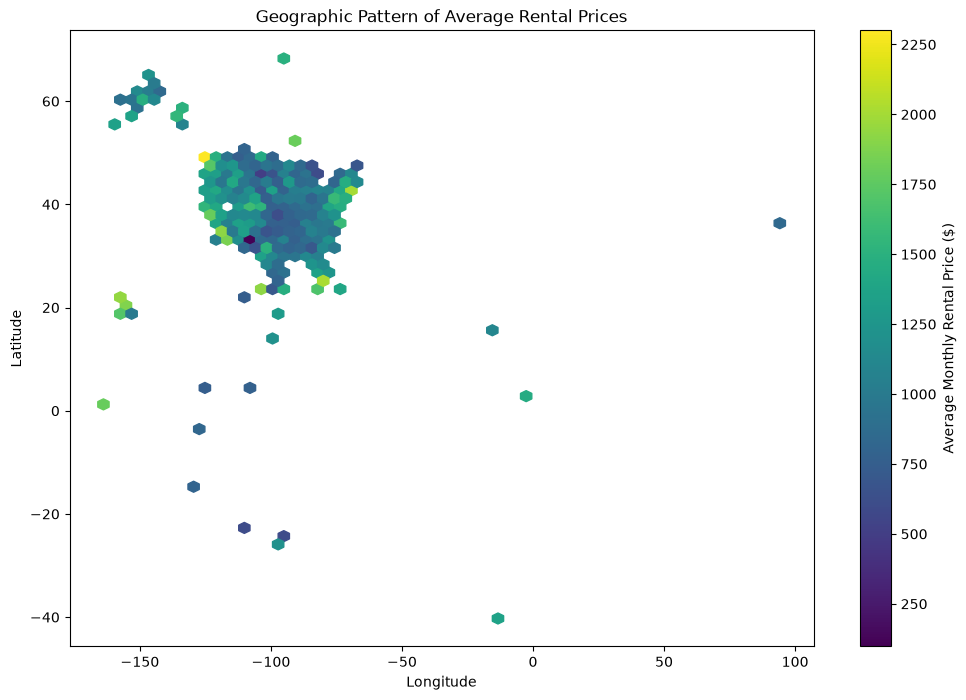

In [120]:
# Calculate the 99th percentile of rental price.
# This is used only to prevent extreme prices from dominating
# the geographic visualization.

price_99 = df["price"].quantile(0.99)

# Keep only valid geographic records within the visualization
# price threshold.

geo_price_focused = geo_df[
    geo_df["price"] <= price_99
].copy()

# Create a geographic hexbin plot.
# Longitude is represented on the x-axis.
# Latitude is represented on the y-axis.
# The color of each hexagon represents the average rental price
# of listings within that geographic area.

plt.figure(figsize=(12, 8))

plt.hexbin(
    geo_price_focused["long"],
    geo_price_focused["lat"],
    C=geo_price_focused["price"],
    gridsize=60,
    reduce_C_function=np.mean,
    cmap="viridis",
    mincnt=1
)

plt.colorbar(label="Average Monthly Rental Price ($)")

plt.title("Geographic Pattern of Average Rental Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

**Interpretation:**

The geographic visualization shows that rental listings are concentrated
within the continental United States, while several isolated geographic
points appear outside the main listing cluster.

Within the main U.S. listing area, the colors vary across geographic
locations, indicating differences in average rental prices between
different spatial areas.

This supports the earlier state- and region-level analyses, which also
showed differences in rental-price distributions across geographic
categories.

The isolated geographic points should be interpreted cautiously because
some may represent geographically inconsistent records identified during
the earlier coordinate-quality analysis.

The 99th-percentile price threshold was used only for visualization and
does not remove observations from the original dataset.

**Finding:**

Rental prices show geographic variation across the U.S. listing
locations. State and region analyses, together with the spatial
visualization, indicate that geographic information may provide useful
predictive information for rental-price estimation.

However, latitude and longitude individually showed only weak monotonic
relationships with rental price in the correlation analysis. Therefore,
geographic information should not be evaluated using latitude or
longitude alone; state, region, and spatial features should also be
considered during feature engineering and feature selection.

Geographically inconsistent records identified during data-quality
analysis will require appropriate handling during preprocessing.

## 10. Data Leakage Analysis

Data leakage occurs when information that would not legitimately be
available at prediction time is used as an input to the machine-learning
model.

Leakage can lead to unrealistically good model performance because the
model receives information that is directly related to the target or
information that would not be available when making a prediction for a
new listing.

Potential leakage sources in this dataset include:

- The target variable `price`
- Identifier fields such as `id`
- URL-related fields
- The `description` text field
- Duplicate and near-duplicate listings
- Data transformations learned from the complete dataset

Each potential source is examined to determine whether it should be
excluded, retained, or handled carefully during preprocessing.

#### 10.1 Target Variable Leakage

The target variable `price` represents the monthly rental price that the
model is required to predict.

Therefore, `price` must not be included as an input feature during model
training.

It is retained as the target variable but excluded from the predictor
feature set.

In [121]:
# Define the target variable for the machine-learning problem.

target_column = "price"

# Check that the target variable exists in the dataset.

target_column in df.columns

True

#### 10.2 Identifier and URL Fields

The dataset contains identifier and URL-related fields including `id`,
`url`, `region_url`, and `image_url`.

These fields are investigated because identifiers and URLs generally do
not represent property characteristics that should be used directly to
predict rental price.

An identifier may also allow the model to memorize individual listings,
while URLs may contain listing-specific information that is not
appropriate as a general predictive feature.

The fields are therefore considered potential leakage or noise sources
and will be evaluated for exclusion during preprocessing.

In [123]:
# List the identifier and URL-related columns in the dataset.

id_url_columns = [
    "id",
    "url",
    "region_url",
    "image_url"
]

# Display basic information about these columns.

df[id_url_columns].head()

,id,url,region_url,image_url
0,7049044568,https://reno.craigslist.org/apa/d/reno-beautif...,https://reno.craigslist.org,https://images.craigslist.org/01616_daghmBUvTC...
1,7049047186,https://reno.craigslist.org/apa/d/reno-reduced...,https://reno.craigslist.org,https://images.craigslist.org/00V0V_5va0MkgO9q...
2,7043634882,https://reno.craigslist.org/apa/d/sparks-state...,https://reno.craigslist.org,https://images.craigslist.org/00t0t_erYqC6LgB8...
3,7049045324,https://reno.craigslist.org/apa/d/reno-1x1-fir...,https://reno.craigslist.org,https://images.craigslist.org/00303_3HSJz75zlI...
4,7049043759,https://reno.craigslist.org/apa/d/reno-no-long...,https://reno.craigslist.org,https://images.craigslist.org/01616_fALAWFV8zQ...


#### 10.2.1 Identifier Uniqueness

The uniqueness of the `id` field is examined to determine whether it
acts as a unique identifier for individual listings.

A unique identifier should generally not be used directly as a predictive
feature because its numerical value does not represent a meaningful
property characteristic and may allow the model to memorize individual
records.

In [124]:
# Check the number of unique listing IDs.

unique_id_count = df["id"].nunique()

# Check whether any IDs are duplicated.

duplicate_id_count = df["id"].duplicated().sum()

print("Total records:", len(df))
print("Unique IDs:", unique_id_count)
print("Duplicated IDs:", duplicate_id_count)

Total records: 384977
Unique IDs: 384977
Duplicated IDs: 0


**Finding:**

The `id` column contains 384,977 unique values for 384,977 records,
with no duplicated identifiers. Therefore, it functions as a unique
listing identifier rather than a meaningful property characteristic.

The `url`, `region_url`, and `image_url` columns contain references to
the original listings or their associated resources rather than
property characteristics required for rental-price prediction.

These identifier and URL fields will therefore be excluded from the
predictive feature set to avoid introducing listing-specific information
and unnecessary noise into the model.

#### 10.3 Description Leakage Analysis

The `description` field contains free-text information provided as part
of each rental listing.

Although descriptions may contain useful property information, they may
also explicitly mention rental prices or other listing-specific
information related to the target variable.

Therefore, the description field is investigated for potential target
leakage before deciding whether it should be included in the predictive
feature set.

#### 10.3.1 Searching Descriptions for Price Information

The descriptions are searched for common price-related expressions to
identify whether rental-price information may appear directly in the
text.

This is an exploratory leakage check rather than a complete natural
language processing analysis.

In [125]:
# Convert descriptions to strings while preserving missing values
# as empty strings for the search.

description_text = df["description"].fillna("").astype(str)

# Search for common dollar-price patterns such as:
# $100, $1,200, $1500, etc.

price_pattern = r"\$\s?\d{1,3}(?:,\d{3})*(?:\.\d+)?|\$\s?\d+"

description_price_matches = description_text.str.contains(
    price_pattern,
    regex=True
)

# Count listings whose descriptions contain at least one
# dollar-price expression.

description_price_matches.sum()

np.int64(168595)

**Interpretation:**

A total of 168,595 listings contain at least one dollar-price expression
in their description. This represents approximately 43.8% of the dataset.

This indicates that the `description` field frequently contains explicit
rental-price information. Including the raw description text as a
predictive feature could therefore allow the model to obtain information
directly related to the target variable (`price`), resulting in target
leakage.

Therefore, the raw `description` field will be excluded from the
predictive feature set for the main modeling pipeline.

**Finding:**

The description field shows substantial potential for target leakage,
with 168,595 listings containing dollar-price expressions. Since the
project aims to predict rental price from property characteristics,
the raw `description` field will be excluded from the main predictive
feature set to prevent the model from learning the target directly
from listing text.

#### 10.3.2 Checking for the Actual Target Price

To strengthen the leakage analysis, the actual `price` value is compared
with the dollar amounts appearing in each description.

This helps determine whether descriptions directly contain the target
rental price rather than simply containing unrelated monetary values.

In [127]:
# Extract descriptions as strings.
description_text = df["description"].fillna("").astype(str)

# Convert prices to integers.
price_values = df["price"].astype(int)

# Create common text representations of each price.
price_no_comma = price_values.astype(str)
price_with_comma = price_values.map(lambda x: f"{x:,}")

# Check each description individually for its corresponding price.
exact_price_match = pd.Series(False, index=df.index)

for idx in df.index:
    description = description_text.loc[idx]
    price_1 = f"${price_no_comma.loc[idx]}"
    price_2 = f"${price_with_comma.loc[idx]}"

    if price_1 in description or price_2 in description:
        exact_price_match.loc[idx] = True

# Count listings where the description contains the actual target price.
exact_price_match.sum()

np.int64(89889)

**Interpretation:**

A total of 89,889 listings contain their exact target `price` value in
the description, representing approximately 23.35% of the dataset.

This provides stronger evidence of potential target leakage because the
description can directly expose the value that the model is expected
to predict.

Although descriptions may contain useful property information, using
the raw description as a predictive feature could allow the model to
access the target price directly for a substantial portion of listings.

Therefore, the raw `description` field will be excluded from the main
predictive feature set.

**Finding:**

The `description` field presents a substantial target-leakage risk.
While 168,595 listings contained some dollar-price expression, 89,889
listings (approximately 23.35%) contained the exact target `price`
in the description using the checked dollar formats.

Therefore, the raw `description` field will be excluded from the main
predictive feature set. This ensures that the model learns rental-price
relationships from property and location characteristics rather than
directly reading the target value from listing text.

#### 10.4 Transformation and Preprocessing Leakage

Some preprocessing techniques learn information from the dataset.
Examples include calculating numerical imputation values, scaling
parameters, encoding categories, and selecting features.

If these transformations are fitted using the complete dataset before
the train-test split, information from the validation or test data can
influence the model.

Therefore, preprocessing transformations will be fitted only on the
training data and then applied to the validation and test data.

This prevents information from the evaluation data from influencing
the model during training.

**Finding:**

Preprocessing steps that learn parameters from the data must be fitted
using the training set only. The validation and test sets will only be
transformed using parameters learned from the training data.

This approach will be followed during the preprocessing and modeling
stages to prevent data leakage.

#### 10.5 Duplicate and Near-Duplicate Leakage

Repeated or highly similar listings can create leakage when similar
records are distributed between the training and test sets.

During the earlier duplicate analysis, exact duplicate rows were not
found, but repeated property-pattern groups were identified using
price, property type, square footage, bedrooms, bathrooms, state,
latitude, and longitude.

These repeated patterns may represent legitimate repeated or syndicated
listings rather than exact duplicates. Therefore, they should not be
automatically removed.

However, their presence must be considered when creating the
train-validation-test split because highly similar listings appearing
in both training and evaluation sets could make model performance
appear better than its generalization to genuinely different listings.

In [130]:
# Columns used to identify repeated property patterns.
near_duplicate_columns = [
    "price",
    "type",
    "sqfeet",
    "beds",
    "baths",
    "state",
    "lat",
    "long"
]

# Count how many times each property pattern occurs.
near_duplicate_counts = (
    df.groupby(near_duplicate_columns, dropna=False)
      .size()
)

# Keep only patterns that occur more than once.
repeated_groups = near_duplicate_counts[
    near_duplicate_counts > 1
]

# Calculate the number of records belonging to repeated groups.
repeated_records = repeated_groups.sum()

print("Records in repeated groups:", repeated_records)
print("Percentage of dataset:", (repeated_records / len(df)) * 100)

Records in repeated groups: 248053
Percentage of dataset: 64.4331999054489


**Interpretation:**

A total of 248,053 records, representing approximately 64.43% of the
dataset, belong to property-pattern groups that occur more than once.

However, these records should not automatically be treated as
duplicates. The grouping is based on matching values for price, type,
square footage, bedrooms, bathrooms, state, latitude, and longitude.
Multiple listings can legitimately share these characteristics,
particularly when properties are listed repeatedly or syndicated across
different listings.

Therefore, the repeated groups are treated as a potential source of
evaluation leakage rather than being automatically removed.

**Finding:**

Exact duplicate rows were not identified, but substantial repetition
exists in the selected property characteristics. Since 64.43% of
records belong to repeated property-pattern groups, highly similar
listings may occur in both training and evaluation sets.

Therefore, the train-validation-test splitting strategy should be
designed carefully, and repeated or highly similar listings should be
considered when interpreting model performance.

# 11. EDA Summary and Preprocessing Decisions

The EDA identified several important characteristics of the USA Housing
Listings dataset that will influence the preprocessing and modeling stages.

The main findings include missing values in selected location and
property-amenity fields, invalid observations in the target and numerical
features, highly skewed distributions, extreme values, high-cardinality
categorical variables, relationships between numerical and categorical
features and rental price, repeated listing patterns, and potential
target leakage in identifier, URL, and description fields.

The following findings will be used to guide the preprocessing and
feature-engineering decisions.

### 11.2 EDA Findings and Planned Preprocessing Decisions

| EDA Finding | Evidence / Observation | Planned Decision |
|---|---|---|
| Missing parking information | `parking_options` has substantial missing values | Investigate an appropriate categorical missing-value treatment |
| Missing laundry information | `laundry_options` has substantial missing values | Treat missing as a distinct category where appropriate |
| Missing coordinates | 1,918 records have both `lat` and `long` missing | Investigate whether to impute, retain with a missing indicator, or exclude from spatial features |
| Invalid target values | 1,307 records have `price = 0` | Remove invalid target records before modeling |
| Invalid square footage | 48 records have `sqfeet = 0` | Remove or investigate these records before modeling |
| Invalid geographic values | 4 records have latitude outside the valid geographic range | Treat these records as invalid |
| Extreme price values | Price is highly right-skewed with extreme upper-tail values | Investigate appropriate treatment and possible target transformation |
| Extreme square footage | `sqfeet` contains extreme upper-tail values | Investigate unusual observations and consider transformation/treatment |
| Extreme bedrooms/bathrooms | Unrealistic values such as 1000/1100 beds and 75 baths were identified | Investigate and remove clearly invalid observations where justified |
| Categorical variables | `type`, `state`, `region`, laundry and parking contain multiple categories | Apply appropriate categorical encoding |
| High-cardinality region | `region` contains 404 categories | Investigate suitable encoding and possible feature-selection/reduction strategies |
| Numerical feature relationships | Spearman correlations show relationships between price and size, beds and baths | Retain relevant numerical features initially |
| Numerical redundancy | `sqfeet`, `beds`, and `baths` show strong relationships with each other | Investigate redundancy during feature selection |
| Geographic patterns | Rental prices vary across geographic areas | Retain geographic information where useful and investigate location-based features |
| Repeated property patterns | 248,053 records belong to repeated property-pattern groups | Consider repeated listings when designing the train/test split and evaluating generalisation |
| Identifier/URL fields | `id`, `url`, `region_url`, and `image_url` are listing/reference fields | Exclude from the main predictive feature set |
| Description leakage | 89,889 descriptions contain the exact target price in checked dollar formats | Exclude raw `description` from the main predictive feature set |
| Preprocessing leakage | Learned transformations can expose information from evaluation data | Fit preprocessing only on training data |
| Binary features | Binary property-policy variables contain valid 0/1 values | Retain without additional categorical cleaning |

### 11.3 Final Feature Plan

Based on the EDA findings, the original dataset variables are classified
according to their intended role in the preprocessing and modeling stages.

The classification is based on predictive relevance, data quality,
categorical structure, leakage risk, and the requirements of the
rental-price prediction problem.

| Column | Type | Planned Treatment | Reason |
|---|---|---|---|
| `price` | Numerical | **Target** | Monthly rental price to be predicted |
| `sqfeet` | Numerical | **Keep + investigate outliers/transformation** | Relevant measure of property size |
| `beds` | Numerical | **Keep + clean extreme values** | Relevant property characteristic |
| `baths` | Numerical | **Keep + clean extreme values** | Relevant property characteristic |
| `lat` | Numerical | **Keep / handle missing values** | Provides geographic information |
| `long` | Numerical | **Keep / handle missing values** | Provides geographic information |
| `type` | Categorical | **Encode** | Represents property type |
| `region` | Categorical | **Encode / investigate high cardinality** | Provides location information with 404 categories |
| `state` | Categorical | **Encode** | Provides geographic information |
| `laundry_options` | Categorical | **Handle missing + encode** | Property amenity information |
| `parking_options` | Categorical | **Handle missing + encode** | Property amenity information |
| `cats_allowed` | Binary | **Keep** | Valid 0/1 property policy feature |
| `dogs_allowed` | Binary | **Keep** | Valid 0/1 property policy feature |
| `smoking_allowed` | Binary | **Keep** | Valid 0/1 property policy feature |
| `wheelchair_access` | Binary | **Keep** | Valid 0/1 accessibility feature |
| `electric_vehicle_charge` | Binary | **Keep** | Valid 0/1 property feature |
| `comes_furnished` | Binary | **Keep** | Valid 0/1 property feature |
| `description` | Text | **Exclude** | Potential target leakage; exact target price appears in many descriptions |
| `id` | Identifier | **Exclude** | Unique listing identifier, not a property characteristic |
| `url` | URL | **Exclude** | Listing reference field and potential source-specific noise |
| `region_url` | URL | **Exclude** | Region reference field rather than a property characteristic |
| `image_url` | URL | **Exclude** | Image/listing reference rather than a predictive property feature |

### 11.4 Final Preprocessing Strategy

Based on the EDA findings, the preprocessing workflow will follow the
sequence below:

1. Remove clearly invalid records.
2. Separate the target variable from the input features.
3. Exclude features identified as identifiers, URLs, or potential
   leakage sources.
4. Handle missing values according to the variable type and the meaning
   of missingness.
5. Investigate and treat extreme numerical observations where justified.
6. Encode categorical variables using an appropriate method.
7. Scale numerical variables for algorithms that require scaling.
8. Perform meaningful feature engineering based on the EDA findings.
9. Perform feature selection based on relevance, redundancy, leakage
   risk, and experimental evidence.
10. Create training, validation, and test sets using a leakage-safe
    strategy.
11. Fit learned preprocessing transformations using the training data
    only.
12. Apply the fitted preprocessing consistently to validation, test, and
    future user inputs.

The final preprocessing implementation will be reproducible so that the
same transformations used during model development can later be applied
to user-provided property information.

### 11.5 EDA Conclusion

The exploratory analysis provided a detailed understanding of the USA
Housing Listings dataset and identified the major data-quality,
distribution, relationship, repetition, and leakage issues that must be
considered before model development.

The target variable `price` is highly right-skewed and contains extreme
values. Several numerical variables also contain unusual observations,
including invalid zero values and extreme values in bedrooms,
bathrooms, and square footage. Missing values are present mainly in
parking, laundry, and geographic coordinates.

The analysis also identified substantial categorical variation,
including a high-cardinality `region` feature. Numerical relationship
analysis showed useful monotonic relationships between rental price and
property characteristics, while also identifying redundancy among
square footage, bedrooms, and bathrooms.

Repeated property-pattern groups were identified, requiring careful
consideration during data splitting and evaluation. Potential target
leakage was also identified in listing identifiers, URLs, and
descriptions. In particular, many descriptions contain explicit price
information.

These findings provide the basis for the preprocessing, feature
engineering, feature selection, and leakage-prevention strategy that
will be implemented in the next stage of the project.